# 🎯 K-means Clustering: From Zero to Hero
## Prototype-Based Clustering, Done Properly — A Progressive, Beginner-Friendly Masterclass

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
![Python](https://img.shields.io/badge/Python-3.10+-blue.svg)
![scikit-learn](https://img.shields.io/badge/scikit--learn-1.5+-F7931E.svg)
![Runs offline](https://img.shields.io/badge/runs%20offline-no%20downloads-brightgreen.svg)

---

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 20px; color: white; text-align: center; margin: 10px 0;">

### Welcome!

K-means is the most-used clustering algorithm in the world and also the most-misused. It fits in four lines of NumPy, yet it hides a surprising amount of mathematics: a convergence proof, an optimality guarantee for its seeding, a family of variants that fall out of swapping one distance, and a soft version that is exactly the EM algorithm for a Gaussian mixture.

This notebook is the **deep dive on K-means alone**. It follows Chapter 7 of Tan, Steinbach, Karpatne & Kumar, *Introduction to Data Mining* (2e) — sections 7.1, 7.2 and 7.5 plus the chapter exercises — and takes you from a hand-computable nine-point toy set to the 2026 frontier where K-means is the codebook inside vector databases and generative models.

Build it by hand first, see every step in a picture, then call scikit-learn — so that by the end you can narrate every cell out loud.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Everything here runs on a free Colab CPU with no downloads and no API keys

All datasets are scikit-learn built-ins (`make_blobs`, `make_moons`, `load_iris`, `load_digits`, `load_wine`) or generated in the notebook. The few optional libraries (`sentence-transformers`, `faiss`, `kneed`) are guarded: the cell explains the install and runs a pure NumPy/scikit-learn fallback when the library is absent.

</div>

## 🎯 Learning Objectives

By the end of this notebook you will be able to:

1. **Define** a cluster five different ways (well-separated, prototype-based, contiguity-based, density-based, conceptual) and say which one K-means is built for.
2. **Derive** why the centroid is the mean: minimising SSE forces it, and the derivation is checked symbolically with SymPy.
3. **Implement** Lloyd's algorithm in NumPy step by step, watch it converge frame by frame, and prove that SSE never increases.
4. **Diagnose** bad initialisation, implement **K-means++** from scratch, state its $O(\log K)$ guarantee, and fix empty clusters.
5. **Build bisecting K-means** from scratch, read the hierarchy it produces, and compare it to Lloyd on SSE and time.
6. **Swap the objective**: K-medians, spherical K-means for documents, K-medoids, mini-batch K-means, fuzzy c-means, and Gaussian-mixture EM as *soft* K-means.
7. **Evaluate** a clustering with the full internal (SSE, silhouette, CH, DB, proximity-incidence correlation) and external (purity, entropy, ARI, NMI, V-measure, FMI) toolkit — and know when each lies.
8. **Choose K** with the elbow, silhouette, gap statistic, stability and prediction strength, and test cluster tendency against random data (Hopkins).
9. **Recognise** the textbook failure cases (sizes, densities, shapes, scale, high dimensions) and apply the remedies.
10. **Ship it**: a scaler-plus-K-means pipeline, persisted, serving `predict`, and monitored for drift.
11. **Connect** K-means to deep learning: embeddings, DEC, vector quantisation, product quantisation and GPU K-means.
12. **Solve** the Chapter 7 exercise types by hand and verify each answer in code.

## 📚 Table of Contents

| Part | Tasks | Topics | Difficulty |
|------|-------|--------|------------|
| **0 · Setup** | 1 | Imports, six datasets, plotting helpers | ⭐ |
| **1 · Foundations** | 2–3 | What a cluster is, types of clusterings, prototypes, SSE, why the centroid is the mean, distances | ⭐ |
| **2 · The Algorithm** | 4–5 | Lloyd's algorithm from scratch, frame-by-frame, convergence proof, sklearn equivalence, complexity | ⭐⭐ |
| **3 · Initialisation** | 6–8 | The random-init trap, `n_init`, K-means++ from scratch, empty clusters, outliers, hierarchical seeding | ⭐⭐⭐ |
| **4 · Bisecting K-means** | 9–10 | Bisecting from scratch, the hierarchy, sklearn `BisectingKMeans`, Lloyd vs bisecting | ⭐⭐⭐ |
| **5 · Variants & Objectives** | 11–15 | K-medians, spherical K-means, K-medoids, mini-batch, fuzzy c-means, GMM/EM, kernel K-means | ⭐⭐⭐⭐ |
| **6 · Metrics & Validity** | 16–20 | Internal metrics, SSE+SSB=TSS, similarity-matrix plots, external metrics, random-data baselines, choosing K | ⭐⭐⭐⭐ |
| **7 · Failure Cases** | 21–23 | Sizes, densities, shapes, merge remedy, scaling, curse of dimensionality, categoricals, vs hierarchical/DBSCAN | ⭐⭐⭐ |
| **8 · Real-World End-to-End** | 24–26 | Customer segmentation with categoricals, colour quantisation, digits with external evaluation | ⭐⭐⭐ |
| **9 · Explainability & Errors** | 27–28 | Centroid z-scores, surrogate trees, boundary points, misassignments, scaling curves | ⭐⭐⭐ |
| **10 · MLOps** | 29–30 | `Pipeline`, joblib, `predict` on new data, drift monitoring (centroid shift, PSI), retraining triggers | ⭐⭐⭐ |
| **11 · Embeddings & Multimodal** | 31–33 | Text (TF-IDF vs sentence embeddings), images (pixels vs PCA vs learned features), joint image+text clustering with a modality weight, the embed → reduce → cluster → label recipe | ⭐⭐⭐⭐ |
| **12 · Deep Learning & SOTA 2026** | 34–35 | DEC, VQ-VAE codebooks, product quantisation and FAISS-style search, GPU K-means, LLM-named clusters | ⭐⭐⭐⭐⭐ |
| **13 · Textbook Exercises** | 36 | Seven Chapter-7-style worked problems, each verified in code | ⭐⭐⭐⭐ |
| **Closing** | — | Cheat sheet, pitfalls, what's next, references | — |

## 🗺️ How to Read This Notebook

Every concept follows the same five-beat loop. Look for the icons:

| Beat | Icon | What it is |
|------|------|-----------|
| **Intuition** | 🧠 | The idea in plain words, usually with an analogy. Read this even if you skim. |
| **The Math** | 📐 | The formula, derived gently, never dropped from the sky. |
| **Code** | 💻 | Runnable NumPy or scikit-learn. Type it out yourself the first time. |
| **Picture** | 📊 | A plot of what just happened, followed by a caption that says what to look at — and the common misread. |
| **Takeaway** | ✅ | The one sentence to remember. |

Other markers: ⚠️ a trap that will bite you · 🏆 production practice · 🔬 2026 state of the art · 📝 an exercise.

## ⏱️ Estimated Time

**5–7 hours** to work through carefully; about an hour to skim. Parts 1–4 and 6 are the load-bearing core — if you only have one sitting, do those.

---

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 How this notebook relates to the clustering survey

`clustering_algorithms_zero_to_hero.ipynb` in this folder surveys K-means, hierarchical and DBSCAN side by side. This notebook goes **much deeper on K-means only**: its proofs, its seeding theory, its bisecting and soft variants, the full validity framework, and its role in modern vector search. Hierarchical clustering and DBSCAN appear here exactly once, in Task 23, as the comparison on K-means' own failure cases.

</div>


# Part 0 · Setup and the Datasets ⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Six datasets carry the whole notebook. One is small enough to cluster by hand (nine points), one has clean round blobs so the algorithm can be watched working, one has crescent moons so it can be watched failing, and three are the classic scikit-learn tables (iris, wine, digits) where the ground-truth labels let a clustering be graded.

</div>


# Task 1 · Setup — Imports, Datasets and Helpers

## 1.1 Imports

Nothing here needs installing on Colab. The commented `pip` line is for a bare Python environment.


In [1]:
# ============================================================
#  Setup: imports (all standard on Colab)
# ============================================================
# !pip install numpy pandas scikit-learn scipy matplotlib seaborn sympy -q

import time, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist, pdist, squareform
from sklearn.datasets import make_blobs, make_moons, load_iris, load_digits, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid"); sns.set_palette("husl")
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)

import sklearn, scipy
print("All libraries imported successfully!")
print(f"numpy {np.__version__} | scikit-learn {sklearn.__version__} | scipy {scipy.__version__}")


All libraries imported successfully!
numpy 2.1.3 | scikit-learn 1.6.1 | scipy 1.16.3


## 1.2 The six datasets

| Name | Shape | Why it is here |
|---|---|---|
| `X_toy` | 9 × 2 | Small integers, so every centroid and distance can be checked by hand. Used in Part 2 and the exercises. |
| `X_blobs`, `y_blobs` | 600 × 2 | Four round, equal-size Gaussian blobs: the case K-means was designed for. |
| `X_moons`, `y_moons` | 400 × 2 | Two interleaved crescents: the case K-means cannot solve. |
| `X_iris`, `y_iris` | 150 × 4 | Three species, two of them overlapping. |
| `X_wine`, `y_wine` | 178 × 13 | Thirteen features on wildly different scales — the standardisation lesson. |
| `X_digits`, `y_digits` | 1797 × 64 | Ten handwritten digit classes, 8×8 pixels: the "does it find the classes?" test. |

The toy set is nine points: four in the lower-left, four in the upper-right, and one — $(5, 5)$ — sitting exactly between them. That ninth point is deliberate: it is the point whose assignment depends on where the centroids start.


In [2]:
# ============================================================
#  Datasets
# ============================================================
X_toy = np.array([[1, 2], [2, 1], [2, 3], [3, 2],
                  [7, 6], [8, 6], [7, 8], [8, 7],
                  [5, 5]], dtype=float)

X_blobs, y_blobs = make_blobs(n_samples=600, centers=4, cluster_std=0.9, random_state=RANDOM_STATE)
X_moons, y_moons = make_moons(n_samples=400, noise=0.07, random_state=RANDOM_STATE)

iris = load_iris();     X_iris, y_iris = iris.data, iris.target
wine = load_wine();     X_wine, y_wine = wine.data, wine.target
digits = load_digits(); X_digits, y_digits = digits.data, digits.target

for name, X in [("X_toy", X_toy), ("X_blobs", X_blobs), ("X_moons", X_moons),
                ("X_iris", X_iris), ("X_wine", X_wine), ("X_digits", X_digits)]:
    print(f"{name:9s} shape={X.shape}  range=[{X.min():.1f}, {X.max():.1f}]")


X_toy     shape=(9, 2)  range=[1.0, 8.0]
X_blobs   shape=(600, 2)  range=[-11.1, 12.5]
X_moons   shape=(400, 2)  range=[-1.1, 2.1]
X_iris    shape=(150, 4)  range=[0.1, 7.9]
X_wine    shape=(178, 13)  range=[0.1, 1680.0]
X_digits  shape=(1797, 64)  range=[0.0, 16.0]


## 1.3 Two helpers used on almost every page

`plot_clusters` draws points coloured by label with centroids as black crosses; `sse` computes the sum of squared errors — the number K-means minimises — for any labelling and any set of centres. Both are written in full so there is no hidden magic later.


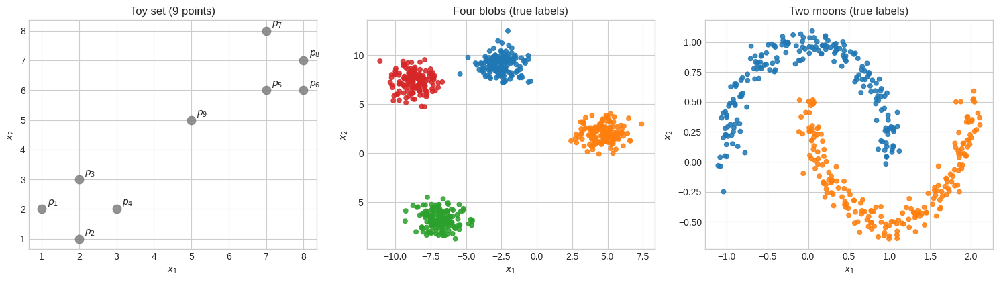

Helpers defined: plot_clusters(), sse()


In [3]:
# ============================================================
#  Helpers
# ============================================================
def plot_clusters(X, labels=None, centers=None, ax=None, title="", s=22, alpha=0.85):
    """Scatter 2-D points coloured by cluster label, with optional centroids as black crosses."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
    if labels is None:
        ax.scatter(X[:, 0], X[:, 1], s=s, c="gray", alpha=alpha)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=s, c=labels, cmap="tab10", alpha=alpha, vmin=0, vmax=9)
    if centers is not None:
        centers = np.asarray(centers)
        ax.scatter(centers[:, 0], centers[:, 1], marker="X", s=180, c="black",
                   edgecolor="white", linewidth=1.5, zorder=5, label="centroids")
    ax.set_title(title); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    return ax


def sse(X, labels, centers):
    """Sum of squared errors: sum over points of ||x - centroid(label)||^2."""
    centers = np.asarray(centers)
    return float(np.sum((X - centers[labels]) ** 2))


fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
plot_clusters(X_toy, ax=axes[0], title="Toy set (9 points)", s=80)
for i, (x, y) in enumerate(X_toy):
    axes[0].annotate(f"$p_{i+1}$", (x + 0.15, y + 0.15))
plot_clusters(X_blobs, y_blobs, ax=axes[1], title="Four blobs (true labels)")
plot_clusters(X_moons, y_moons, ax=axes[2], title="Two moons (true labels)")
plt.tight_layout(); plt.show()
print("Helpers defined: plot_clusters(), sse()")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the nine toy points, labelled $p_1 \ldots p_9$, with $p_9 = (5,5)$ sitting between two tight groups of four. Middle: four blobs that any sensible method separates. Right: two crescents that no set of "nearest centroid" regions can separate, because the regions K-means produces are always convex.

**The common misread:** assuming the coloured blobs are what K-means *sees*. The colours are the ground truth; K-means never sees labels. Everything it does comes from distances alone.

</div>

## 1.4 Task 1 Summary

**✅ Key Takeaways**
- Six datasets: a hand-computable toy, blobs (the ideal case), moons (the impossible case), and iris/wine/digits (real tables with labels for grading).
- `plot_clusters` and `sse` are the two helpers everything else builds on.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `X_toy` | 9 × 2 integer points; $p_9=(5,5)$ is the ambiguous one |
| `X_blobs, y_blobs` | 600 points in 4 Gaussian blobs, with true labels |
| `X_moons, y_moons` | 400 points in 2 crescents |
| `X_iris, X_wine, X_digits` (+ `y_*`) | the classic scikit-learn tables |
| `plot_clusters(X, labels, centers)` | coloured scatter + centroid crosses |
| `sse(X, labels, centers)` | the K-means objective for any partition |

**➡️ Next Up:** Part 1 asks the question the whole chapter hangs on: what *is* a cluster, and which definition is K-means chasing?


# Part 1 · Foundations — What Is a Cluster? ⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

"Cluster analysis groups objects so that objects in a group are similar to each other and different from objects in other groups." That sentence hides a choice: *similar how?* Chapter 7 of the textbook lists five different notions of a cluster, and K-means commits to exactly one of them — the **prototype-based** cluster, where a group is "the points closest to this centre". Everything K-means does well and everything it does badly follows from that commitment.

</div>


# Task 2 · Five Kinds of Cluster, Four Kinds of Clustering

## 2.1 Why the definition matters

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Show the same scatter plot to five people and ask them to circle the groups. A geologist circles the dense regions; a marketer circles the round blobs around "typical customers"; a road engineer follows the connected chains. None of them is wrong: they are using different definitions. An algorithm has to pick one, and a user has to know which one was picked.

</div>

The textbook's five notions of a cluster:

| Notion | A cluster is… | Algorithm family |
|---|---|---|
| **Well-separated** | a set of points each closer to every point in its cluster than to any point outside it | (an ideal; rarely holds) |
| **Prototype-based** | the points closer to *this* prototype (centroid or medoid) than to any other | **K-means**, K-medoids |
| **Graph / contiguity-based** | points connected by a chain of near neighbours | single-link hierarchical |
| **Density-based** | a dense region separated from other dense regions by sparse ones | DBSCAN |
| **Conceptual / shared-property** | points that share some property (concentric rings, intersecting lines) | model-based, spectral |

And four independent dichotomies describe the *clustering* (the whole set of clusters):

| Dichotomy | Meaning | What K-means produces |
|---|---|---|
| **Partitional vs hierarchical** | flat division into non-overlapping sets, or nested tree of clusters | partitional (bisecting K-means yields a hierarchy) |
| **Exclusive vs overlapping vs fuzzy** | each point in one cluster / possibly several / a membership weight in each | exclusive (fuzzy c-means in Part 5 relaxes this) |
| **Complete vs partial** | every point assigned, or some left as noise | complete — outliers *always* get a cluster |
| **Well-separated / prototype / …** | which notion of cluster is targeted | prototype-based, centre = centroid |

## 2.2 Seeing the five notions

Five synthetic pictures, one per notion, so the words have a shape attached.


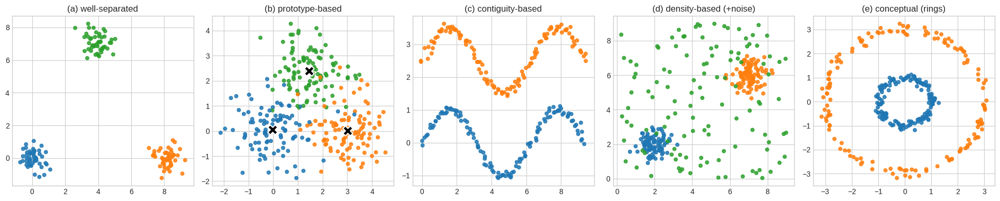

K-means targets (b). It also solves (a). It fails on (c), (d) and (e) — Part 7 shows exactly how.


In [4]:
# ============================================================
#  Five notions of a cluster, one picture each
# ============================================================
rng = np.random.default_rng(RANDOM_STATE)
fig, axes = plt.subplots(1, 5, figsize=(19, 3.9))

# (a) well-separated: three far-apart tight groups
Xa, ya = make_blobs(n_samples=150, centers=[[0, 0], [8, 0], [4, 7]], cluster_std=0.5, random_state=1)
plot_clusters(Xa, ya, ax=axes[0], title="(a) well-separated")

# (b) prototype-based: overlapping blobs where 'nearest centre' still makes sense
Xb, yb = make_blobs(n_samples=300, centers=[[0, 0], [3, 0], [1.5, 2.6]], cluster_std=0.8, random_state=2)
cb = np.array([Xb[yb == k].mean(axis=0) for k in range(3)])
plot_clusters(Xb, yb, cb, ax=axes[1], title="(b) prototype-based")

# (c) contiguity-based: two long chains that touch nowhere
t = np.linspace(0, 3 * np.pi, 120)
Xc = np.vstack([np.c_[t, np.sin(t)], np.c_[t, np.sin(t) + 2.5]]) + rng.normal(0, 0.08, (240, 2))
yc = np.r_[np.zeros(120), np.ones(120)].astype(int)
plot_clusters(Xc, yc, ax=axes[2], title="(c) contiguity-based")

# (d) density-based: dense cores in a sea of uniform noise
Xd, yd = make_blobs(n_samples=200, centers=[[2, 2], [7, 6]], cluster_std=0.45, random_state=3)
noise = rng.uniform(0, 9, (120, 2))
plot_clusters(np.vstack([Xd, noise]), np.r_[yd, np.full(120, 2)], ax=axes[3], title="(d) density-based (+noise)")

# (e) conceptual: two concentric rings share a *property*, not a location
ang = rng.uniform(0, 2 * np.pi, 300)
r = np.r_[np.full(150, 1.0), np.full(150, 3.0)] + rng.normal(0, 0.1, 300)
Xe = np.c_[r * np.cos(ang), r * np.sin(ang)]
plot_clusters(Xe, np.r_[np.zeros(150), np.ones(150)].astype(int), ax=axes[4], title="(e) conceptual (rings)")
for ax in axes: ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()
print("K-means targets (b). It also solves (a). It fails on (c), (d) and (e) — Part 7 shows exactly how.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five panels, five definitions. In (a) every definition agrees. In (b) the groups overlap, yet "which centroid am I closest to?" (the crosses) still gives a sensible answer — this is K-means territory. In (c) the natural groups are *chains*: a point's nearest centre is meaningless, its nearest neighbour is everything. In (d) the groups are dense cores and the grey points are noise that should belong to nothing. In (e) the two rings have the same centre, so no "nearest centre" rule can ever tell them apart.

**The common misread:** thinking the panels differ in difficulty. They differ in *definition*. A method that is perfect for (b) is not "weak" on (e); it is answering a different question.

</div>

## 2.3 Task 2 Summary

**✅ Key Takeaways**
- A cluster has no single definition; the textbook lists five, and K-means commits to the prototype-based one.
- A clustering is partitional or hierarchical, exclusive/overlapping/fuzzy, complete or partial. Plain K-means is partitional, exclusive and complete — every point, including every outlier, gets a cluster.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `Xa … Xe` | the five illustrative datasets (only used here) |

**➡️ Next Up:** Task 3 turns "closest to the prototype" into a number to minimise, and derives what the prototype must be.


# Task 3 · The Prototype, the Objective, and Why the Centroid Is the Mean

## 3.1 The prototype idea

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Pick $K$ representative points — the **prototypes** or **centroids** $\mathbf{c}_1, \ldots, \mathbf{c}_K$. Every data point joins the prototype it is nearest to. A good set of prototypes is one where points sit close to their own prototype. So the quality of a clustering is the total "distance from home", and the best clustering is the one that makes that total smallest.

</div>

### 📐 The Math

Let $C_i$ be the set of points assigned to centroid $\mathbf{c}_i$. With Euclidean distance the natural total is the **sum of squared errors (SSE)**, also called *inertia* or *scatter*:

$$ \text{SSE} = \sum_{i=1}^{K} \sum_{\mathbf{x} \in C_i} \left\| \mathbf{x} - \mathbf{c}_i \right\|^2 $$

Two questions fall out immediately:

1. Given fixed centroids, which assignment minimises SSE? — *Each point to its nearest centroid* (assigning it anywhere else can only add to its own squared distance).
2. Given a fixed assignment, which centroid minimises SSE for cluster $C_i$? — this needs a derivation, and the answer is the reason K-means is called K-*means*.

## 3.2 Deriving the centroid

Take one cluster with points $\mathbf{x}_1, \ldots, \mathbf{x}_m$ and an unknown centre $\mathbf{c}$. Its contribution to SSE is

$$ f(\mathbf{c}) = \sum_{j=1}^{m} \left\| \mathbf{x}_j - \mathbf{c} \right\|^2 $$

Differentiate with respect to $\mathbf{c}$ and set to zero:

$$ \frac{\partial f}{\partial \mathbf{c}} = \sum_{j=1}^{m} -2\,(\mathbf{x}_j - \mathbf{c}) = 0 \quad\Longrightarrow\quad m\,\mathbf{c} = \sum_{j=1}^{m} \mathbf{x}_j \quad\Longrightarrow\quad \mathbf{c} = \frac{1}{m}\sum_{j=1}^{m} \mathbf{x}_j $$

The second derivative is $2m > 0$, so this stationary point is the **minimum**. The centroid that minimises squared Euclidean error is the **mean** of the cluster. Nothing about this used the data values, so it holds for every cluster in every dataset.

The cell below does the same derivation with SymPy for a general $m$-point cluster in 1-D (each coordinate is independent, so 1-D is the whole story), then checks it numerically on the toy set.


df/dc = 0  =>  c = x1/5 + x2/5 + x3/5 + x4/5 + x5/5
d2f/dc2  = 10  (> 0, so it is a minimum)
Equal to the mean? True

Toy lower-left group x-coords [1. 2. 2. 3.] -> mean 2.000, argmin of SSE on grid 2.000


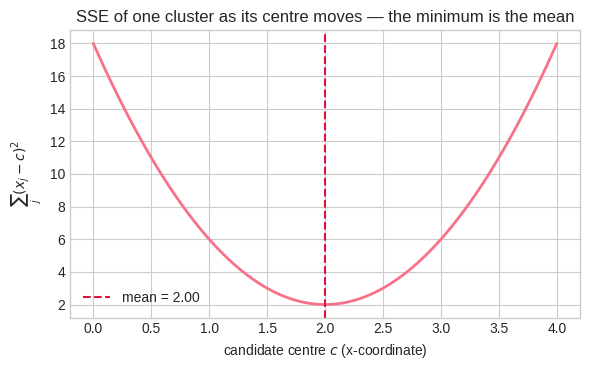

In [5]:
# ============================================================
#  SymPy: minimise sum (x_j - c)^2  =>  c = mean
# ============================================================
import sympy as sp
m = 5                                             # any concrete m works; the algebra is identical
xs = sp.symbols(f"x1:{m+1}"); c = sp.symbols("c")
f = sum((x - c) ** 2 for x in xs)
stationary = sp.solve(sp.diff(f, c), c)[0]
second = sp.diff(f, c, 2)
print("df/dc = 0  =>  c =", stationary)
print("d2f/dc2  =", second, " (> 0, so it is a minimum)")
print("Equal to the mean?", sp.simplify(stationary - sum(xs) / m) == 0)

# Numerical check on the lower-left four toy points: scan c and find the SSE-minimising centre
group = X_toy[:4]
grid = np.linspace(0, 4, 401)
sse_x = [np.sum((group[:, 0] - g) ** 2) for g in grid]
best_x = grid[int(np.argmin(sse_x))]
print(f"\nToy lower-left group x-coords {group[:, 0]} -> mean {group[:, 0].mean():.3f}, argmin of SSE on grid {best_x:.3f}")

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(grid, sse_x, lw=2)
ax.axvline(group[:, 0].mean(), color="crimson", ls="--", label=f"mean = {group[:, 0].mean():.2f}")
ax.set_xlabel("candidate centre $c$ (x-coordinate)"); ax.set_ylabel("$\\sum_j (x_j - c)^2$")
ax.set_title("SSE of one cluster as its centre moves — the minimum is the mean"); ax.legend()
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A parabola: the SSE of a single cluster as a function of where its centre is placed. Its bottom sits exactly on the dashed line at the cluster mean, which is what the SymPy derivation said it must. The curve is a parabola because SSE is quadratic in $c$, and a quadratic has exactly one minimum.

**The common misread:** "the mean is the centroid because that's how centroids are defined". It is the other way round: the *objective* (squared Euclidean error) is what makes the mean optimal. Change the objective — Manhattan distance, say — and the optimal centre changes too (Part 5: it becomes the median).

</div>

## 3.3 The distance primitives

K-means needs one thing from the data: a distance between a point and a centroid. Three appear in this notebook.

| Distance | Formula | Optimal centroid | K-means variant |
|---|---|---|---|
| Squared Euclidean ($L_2^2$) | $\sum_d (x_d - c_d)^2$ | mean | K-means |
| Manhattan ($L_1$) | $\sum_d \lvert x_d - c_d \rvert$ | median (per coordinate) | K-medians |
| Cosine | $1 - \dfrac{\mathbf{x}\cdot\mathbf{c}}{\lVert\mathbf{x}\rVert\,\lVert\mathbf{c}\rVert}$ | normalised mean | spherical K-means |

The workhorse is the point-to-centroid matrix: for $n$ points and $K$ centroids, an $n \times K$ table of distances. With NumPy broadcasting it is one line, and `scipy.spatial.distance.cdist` does the same thing for many metrics.


In [6]:
# ============================================================
#  Point-to-centroid distance matrix, three ways
# ============================================================
C0 = np.array([[2.0, 2.0], [8.0, 8.0]])                     # two hand-picked centroids on the toy set

D_bcast = np.sqrt(((X_toy[:, None, :] - C0[None, :, :]) ** 2).sum(axis=2))   # broadcasting
D_cdist = cdist(X_toy, C0, metric="euclidean")                                  # scipy
D_manh  = cdist(X_toy, C0, metric="cityblock")

print("Broadcasting and cdist agree:", np.allclose(D_bcast, D_cdist))
table = pd.DataFrame({"point": [f"p{i+1}" for i in range(9)], "x": X_toy[:, 0], "y": X_toy[:, 1],
                      "d(c1) eucl": D_cdist[:, 0].round(3), "d(c2) eucl": D_cdist[:, 1].round(3),
                      "nearest (eucl)": D_cdist.argmin(1) + 1,
                      "d(c1) manh": D_manh[:, 0], "d(c2) manh": D_manh[:, 1],
                      "nearest (manh)": D_manh.argmin(1) + 1})
print(table.to_string(index=False))
print(f"\np9 = (5,5): Euclidean {D_cdist[8,0]:.3f} vs {D_cdist[8,1]:.3f}, Manhattan {D_manh[8,0]:.0f} vs {D_manh[8,1]:.0f}"
      f" -> an exact tie under both; argmin silently picks c{D_cdist[8].argmin()+1}.")


Broadcasting and cdist agree: True
point   x   y  d(c1) eucl  d(c2) eucl  nearest (eucl)  d(c1) manh  d(c2) manh  nearest (manh)
   p1 1.0 2.0       1.000       9.220               1         1.0        13.0               1
   p2 2.0 1.0       1.000       9.220               1         1.0        13.0               1
   p3 2.0 3.0       1.000       7.810               1         1.0        11.0               1
   p4 3.0 2.0       1.000       7.810               1         1.0        11.0               1
   p5 7.0 6.0       6.403       2.236               2         9.0         3.0               2
   p6 8.0 6.0       7.211       2.000               2        10.0         2.0               2
   p7 7.0 8.0       7.810       1.000               2        11.0         1.0               2
   p8 8.0 7.0       7.810       1.000               2        11.0         1.0               2
   p9 5.0 5.0       4.243       4.243               1         6.0         6.0               1

p9 = (5,5): Euclidean 4.

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Ties and the point in the middle

$p_9 = (5,5)$ is exactly equidistant from the two hand-picked centroids $(2,2)$ and $(8,8)$ under both metrics. `argmin` breaks the tie by picking the first index, silently. Real K-means implementations do the same. With continuous data exact ties are rare, but with integer or heavily rounded features they are not, and they make the result depend on row order. Adding a tiny deterministic jitter, or fixing `random_state`, keeps runs reproducible.

</div>

## 3.4 Task 3 Summary

**✅ Key Takeaways**
- K-means minimises SSE: the total squared Euclidean distance from every point to its own centroid.
- For a fixed assignment, the SSE-optimal centre is the **mean** — derived by setting the derivative to zero, confirmed by SymPy and by a grid search on the toy set.
- For fixed centres, the SSE-optimal assignment is **nearest centroid**. The algorithm in Part 2 is just these two facts alternated.
- The distance decides the variant: $L_2^2 \to$ mean, $L_1 \to$ median, cosine $\to$ normalised mean.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `C0` | two hand-picked centroids on the toy set |
| `D_cdist`, `D_manh` | 9 × 2 Euclidean and Manhattan point-to-centroid distance matrices |

**➡️ Next Up:** Part 2 alternates the two optimal steps and watches the centroids walk to their final positions, frame by frame.


# Part 2 · The Algorithm — Lloyd's K-means, Step by Step ⭐⭐

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Part 1 established two facts: for fixed centroids the best assignment is *nearest centroid*, and for a fixed assignment the best centroid is the *mean*. Neither fact alone solves the problem, because each depends on the other. Lloyd's algorithm (1957, published 1982) simply alternates them until nothing changes. This Part builds it in NumPy, watches every frame, proves it must stop, and checks it against scikit-learn to the last decimal.

</div>


# Task 4 · Lloyd's Algorithm from Scratch

## 4.1 The algorithm in five lines

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Drop $K$ pins on the map. Every house joins its nearest pin. Move each pin to the middle of its houses. Repeat. The pins stop moving when every house is already nearest to the pin it belongs to — and that is the answer.

</div>

### 📐 The Math

```
1. Select K points as initial centroids.
2. repeat
3.     Form K clusters by assigning each point to its closest centroid.   (ASSIGN)
4.     Recompute the centroid of each cluster.                            (UPDATE)
5. until centroids do not change.
```

Step 3 is $\text{label}(\mathbf{x}) = \arg\min_i \lVert \mathbf{x} - \mathbf{c}_i \rVert^2$. Step 4 is $\mathbf{c}_i \leftarrow \frac{1}{|C_i|}\sum_{\mathbf{x}\in C_i}\mathbf{x}$. In practice "do not change" becomes "moved less than `tol`" or "no label changed", plus a `max_iter` safety cap.

The implementation below records every intermediate state so the frames can be drawn afterwards. It also handles the one thing that can go wrong mid-run — a cluster losing all its points — by keeping the old centroid in place (Part 3 discusses better fixes).


In [7]:
# ============================================================
#  Lloyd's K-means from scratch (records every frame)
# ============================================================
def kmeans_scratch(X, K=None, init=None, max_iter=100, tol=1e-6, random_state=RANDOM_STATE):
    """Plain Lloyd's algorithm.

    init : array of K starting centroids, or None to pick K random data points.
    Returns labels, centers, history (list of dicts, one per iteration) and n_iter.
    """
    rng = np.random.default_rng(random_state)
    centers = np.array(init, dtype=float) if init is not None else X[rng.choice(len(X), K, replace=False)].copy()
    K = len(centers)
    history = []
    for it in range(1, max_iter + 1):
        D = cdist(X, centers, "sqeuclidean")                 # n x K squared distances
        labels = D.argmin(axis=1)                             # ASSIGN
        sse_after_assign = float(D[np.arange(len(X)), labels].sum())
        new_centers = centers.copy()
        for k in range(K):
            if np.any(labels == k):                           # UPDATE (keep old centroid if the cluster emptied)
                new_centers[k] = X[labels == k].mean(axis=0)
        sse_after_update = sse(X, labels, new_centers)
        shift = float(np.sqrt(((new_centers - centers) ** 2).sum(axis=1)).max())
        history.append(dict(it=it, centers_before=centers.copy(), labels=labels.copy(),
                            centers_after=new_centers.copy(), sse_assign=sse_after_assign,
                            sse_update=sse_after_update, shift=shift))
        centers = new_centers
        if shift < tol:
            break
    return labels, centers, history, it


# A deliberately poor start on the blobs: the four lowest points, all in one blob
bad_init = X_blobs[np.argsort(X_blobs[:, 1])[:4]]
labels_b, centers_b, hist_b, iters_b = kmeans_scratch(X_blobs, init=bad_init)
print(f"Converged in {iters_b} iterations. Final SSE = {hist_b[-1]['sse_update']:.2f}")
for h in hist_b:
    print(f"  iter {h['it']:2d}: SSE after assign {h['sse_assign']:9.2f} | after update {h['sse_update']:9.2f} | max centroid shift {h['shift']:.4f}")


Converged in 4 iterations. Final SSE = 941.90
  iter  1: SSE after assign 120159.89 | after update  22219.14 | max centroid shift 14.6171
  iter  2: SSE after assign   6915.31 | after update   2416.31 | max centroid shift 5.0336
  iter  3: SSE after assign   1484.66 | after update    941.90 | max centroid shift 1.7936
  iter  4: SSE after assign    941.90 | after update    941.90 | max centroid shift 0.0000


## 4.2 Watching it work: the assign → update frames

Each row below is one iteration. Left: the **assign** step (points coloured by the centroid they just joined; crosses are the centroids they were compared against). Right: the **update** step (the same colouring; crosses have moved to the new means, with arrows showing the move).


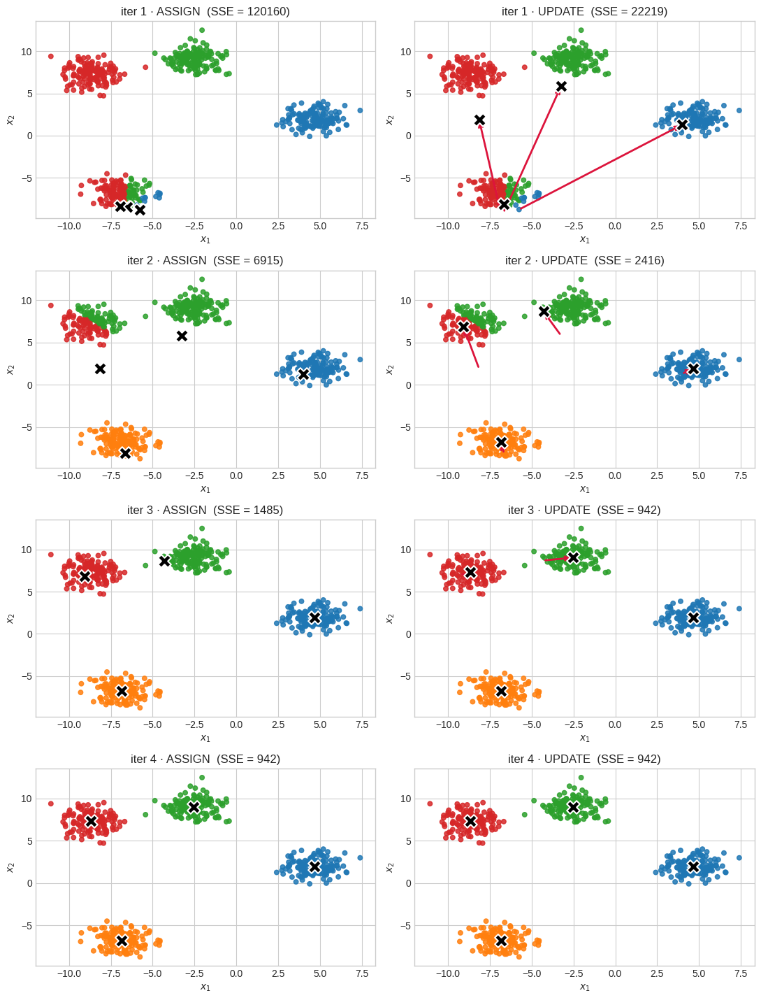

In [8]:
# ============================================================
#  Frame-by-frame plot of the first iterations
# ============================================================
n_show = min(4, len(hist_b))
fig, axes = plt.subplots(n_show, 2, figsize=(11, 3.6 * n_show))
for row, h in enumerate(hist_b[:n_show]):
    plot_clusters(X_blobs, h["labels"], h["centers_before"], ax=axes[row, 0],
                  title=f"iter {h['it']} · ASSIGN  (SSE = {h['sse_assign']:.0f})")
    plot_clusters(X_blobs, h["labels"], h["centers_after"], ax=axes[row, 1],
                  title=f"iter {h['it']} · UPDATE  (SSE = {h['sse_update']:.0f})")
    for c0, c1 in zip(h["centers_before"], h["centers_after"]):
        axes[row, 1].annotate("", xy=c1, xytext=c0, arrowprops=dict(arrowstyle="->", color="crimson", lw=2))
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

In iteration 1 all four centroids sit at the bottom edge of one blob, so they carve that blob into thin vertical slivers, and each of the three far blobs is claimed by whichever sliver-centroid happens to be nearest. The update step then drags three centroids a long way toward those blobs (the long red arrows) while one stays behind. Iteration 2 is already mostly right — only the two left-hand blobs are still shared between two centroids — and iteration 3 settles that. The SSE in the titles drops from six figures to three; by iteration 4 nothing moves.

**The common misread:** reading the *assign* panel as the cluster result. The final answer is the last *update* panel; the assign panels are the transient states, and early ones are wildly wrong by design.

</div>

## 4.3 The toy set by hand

The same algorithm on the nine toy points, starting from $p_1 = (1,2)$ and $p_5 = (7,6)$. Every centroid and every distance is a small fraction, so the table can be checked with pencil and paper — which is exactly what the Chapter 7 exercises ask for (Part 12 does more of these).


In [9]:
# ============================================================
#  Toy set, hand-checkable trace
# ============================================================
labels_t, centers_t, hist_t, iters_t = kmeans_scratch(X_toy, init=X_toy[[0, 4]])
for h in hist_t:
    print(f"iteration {h['it']}")
    print("  centroids used :", np.round(h["centers_before"], 3).tolist())
    print("  assignment     :", {f"p{i+1}": int(l) + 1 for i, l in enumerate(h["labels"])})
    print("  new centroids  :", np.round(h["centers_after"], 3).tolist(), f"| SSE {h['sse_update']:.3f}")
print(f"\nStopped after {iters_t} iterations; p9 = (5,5) ended in cluster {labels_t[8] + 1}.")


iteration 1
  centroids used : [[1.0, 2.0], [7.0, 6.0]]
  assignment     : {'p1': 1, 'p2': 1, 'p3': 1, 'p4': 1, 'p5': 2, 'p6': 2, 'p7': 2, 'p8': 2, 'p9': 2}
  new centroids  : [[2.0, 2.0], [7.0, 6.4]] | SSE 15.200
iteration 2
  centroids used : [[2.0, 2.0], [7.0, 6.4]]
  assignment     : {'p1': 1, 'p2': 1, 'p3': 1, 'p4': 1, 'p5': 2, 'p6': 2, 'p7': 2, 'p8': 2, 'p9': 2}
  new centroids  : [[2.0, 2.0], [7.0, 6.4]] | SSE 15.200

Stopped after 2 iterations; p9 = (5,5) ended in cluster 2.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Reading the trace

Iteration 1 assigns each point to the nearer of $(1,2)$ and $(7,6)$, then moves the centroids to the means of the two groups. Iteration 2 re-assigns with the new centroids; since nobody switches, the means are unchanged and the loop stops. The middle point $p_9$ lands with the upper-right group because $(5,5)$ is nearer to $(7,6)$ than to $(1,2)$ on the very first assignment — a different start could send it the other way (Exercise 12.4 does exactly that).

</div>

## 4.4 Task 4 Summary

**✅ Key Takeaways**
- Lloyd's algorithm alternates ASSIGN (nearest centroid) and UPDATE (mean of the cluster) until the centroids stop moving.
- Bad starts cost iterations, not correctness *on the blobs* — but Part 3 shows starts that cost correctness too.
- The trace on the toy set is short enough to check by hand; the exercises rely on this.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `kmeans_scratch(X, K, init, …)` | the from-scratch implementation; returns labels, centers, history, n_iter |
| `hist_b`, `centers_b`, `labels_b` | the blob run from a deliberately bad start |
| `hist_t`, `labels_t` | the two-iteration toy-set trace |

**➡️ Next Up:** Task 5 proves the loop must terminate, matches the scratch code against scikit-learn, and counts the cost.


# Task 5 · Convergence, scikit-learn, and the Cost

## 5.1 Why the loop must stop

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 Proof sketch: SSE never increases, and there are finitely many partitions

**Claim 1 — ASSIGN does not increase SSE.** Each point's term in SSE is $\lVert \mathbf{x} - \mathbf{c}_{\text{label}(\mathbf{x})}\rVert^2$. Reassigning $\mathbf{x}$ to its *nearest* centroid can only make its term smaller or equal; no other term changes.

**Claim 2 — UPDATE does not increase SSE.** For a fixed cluster, Task 3 showed the mean is the *unique* minimiser of $\sum_{\mathbf{x}\in C_i}\lVert\mathbf{x}-\mathbf{c}\rVert^2$. Replacing the old centroid with the mean can only lower (or keep) that cluster's sum.

**Claim 3 — finitely many states.** A "state" is a partition of $n$ points into at most $K$ groups. The number of such partitions is finite (bounded by $K^n$). Because SSE strictly decreases whenever *any* label changes (Claim 1 with a strict inequality for the switching point, then Claim 2), no partition can be visited twice. A finite set visited without repetition means the algorithm terminates.

**What is *not* claimed.** Termination at a **local** minimum of SSE. Nothing says it is the global one — and finding the global minimum is NP-hard even for $K=2$ in general dimension (Aloise et al., 2009). Part 3 is entirely about making the local minimum a good one.

</div>

The SSE trace below is the empirical version of Claims 1 and 2: after every half-step the curve goes down or stays flat, never up.


Any increase in SSE across the run? False
Largest single drop 97940.8; final SSE 941.90


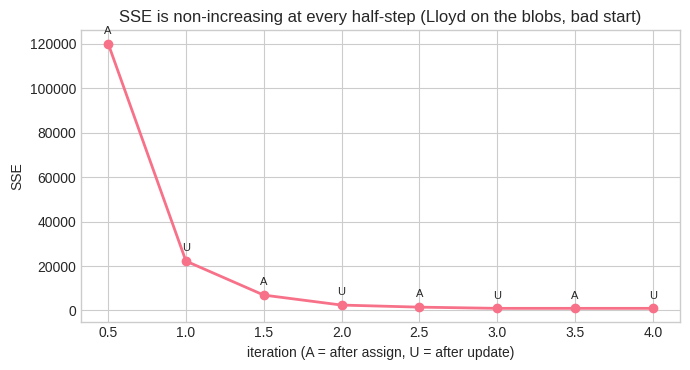

In [10]:
# ============================================================
#  SSE after every half-step: monotone non-increasing
# ============================================================
half_steps, half_sse = [], []
for h in hist_b:
    half_steps += [h["it"] - 0.5, h["it"]]
    half_sse += [h["sse_assign"], h["sse_update"]]
diffs = np.diff(half_sse)
print("Any increase in SSE across the run?", bool((diffs > 1e-9).any()))
print(f"Largest single drop {(-diffs).max():.1f}; final SSE {half_sse[-1]:.2f}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(half_steps, half_sse, "o-", lw=2)
for x, y, lbl in zip(half_steps, half_sse, ["A", "U"] * len(hist_b)):
    ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
ax.set_xlabel("iteration (A = after assign, U = after update)"); ax.set_ylabel("SSE")
ax.set_title("SSE is non-increasing at every half-step (Lloyd on the blobs, bad start)")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A staircase that only goes down. The **A** points are SSE just after an assign step and the **U** points just after an update step; every segment is flat or descending. The big drops all happen in the first few iterations, which is why K-means is usually fast in practice even though its worst-case iteration count is exponential (Vattani, 2011).

**The common misread:** "SSE went to zero change, so the clustering is optimal". It is a *local* optimum. A different start on this same data can stop at a higher plateau; Part 3 shows one.

</div>

## 5.2 The scikit-learn one-liner, and a numerical equivalence check

`sklearn.cluster.KMeans` runs the same Lloyd loop (`algorithm="lloyd"`, the default). Feeding it the identical starting centroids with `n_init=1` should reproduce the scratch run to floating-point precision. The comparison uses `inertia_` (scikit-learn's name for SSE) and the labels — the label *numbers* may be permuted, so agreement is checked with the adjusted Rand index, which is 1.0 for identical partitions regardless of numbering.


In [11]:
# ============================================================
#  sklearn KMeans vs the scratch implementation
# ============================================================
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=4, init=bad_init, n_init=1, max_iter=100, tol=1e-6, algorithm="lloyd").fit(X_blobs)
print(f"sklearn inertia_  : {km.inertia_:.6f}   (n_iter_ = {km.n_iter_})")
print(f"scratch SSE       : {hist_b[-1]['sse_update']:.6f}   (iters   = {iters_b})")
print(f"|difference|      : {abs(km.inertia_ - hist_b[-1]['sse_update']):.2e}")
print(f"ARI(scratch, sklearn) = {adjusted_rand_score(labels_b, km.labels_):.4f}  (1.0 = identical partition)")
# centroids match up to ordering
order = cdist(centers_b, km.cluster_centers_).argmin(axis=1)
print("max centroid gap after matching:", f"{np.abs(centers_b - km.cluster_centers_[order]).max():.2e}")

# the everyday one-liner (k-means++ seeding, 10 restarts, best SSE kept)
km_default = KMeans(n_clusters=4, random_state=RANDOM_STATE).fit(X_blobs)
print(f"\nDefault KMeans(n_clusters=4): inertia_ = {km_default.inertia_:.2f}, n_init = {km_default.n_init}, init = {km_default.init}")


sklearn inertia_  : 941.899086   (n_iter_ = 4)
scratch SSE       : 941.899086   (iters   = 4)
|difference|      : 6.82e-13
ARI(scratch, sklearn) = 1.0000  (1.0 = identical partition)
max centroid gap after matching: 7.11e-15

Default KMeans(n_clusters=4): inertia_ = 941.90, n_init = auto, init = k-means++


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: trust, but verify

The two implementations agree to machine precision on SSE, the partition and the centroids. That check is worth keeping in your own projects whenever you hand-roll an algorithm for teaching or for a custom distance: a mismatch is either a bug or a hidden default (scikit-learn's `n_init`, `tol` semantics and `init` are the usual suspects).

Note the scikit-learn default `n_init="auto"`: with `init="k-means++"` it runs once; with `init="random"` it runs ten times and keeps the lowest inertia. Both matter in Part 3.

</div>

## 5.3 Time and space complexity

Each iteration computes $n \times K$ distances of length $d$ (the *m* × *n* of the textbook's notation, where $m$ = number of points and $n$ = number of attributes), then averages $n$ points. For $I$ iterations:

$$ \text{time} = O(I \cdot K \cdot n \cdot d) \qquad \text{space} = O\big((n + K)\, d\big) $$

Linear in everything — which is why K-means scales to millions of points where hierarchical clustering ($O(n^2)$ space) cannot. The measurement below doubles $n$ and $K$ in turn and watches the wall-clock time follow.


In [12]:
# ============================================================
#  Empirical scaling of one Lloyd run
# ============================================================
def time_kmeans(n, K, d=4, reps=3):
    Xs, _ = make_blobs(n_samples=n, centers=K, n_features=d, random_state=0)
    best = np.inf
    for _ in range(reps):
        t0 = time.perf_counter(); KMeans(n_clusters=K, n_init=1, random_state=0).fit(Xs)
        best = min(best, time.perf_counter() - t0)
    return best

rows = []
for n in [20_000, 40_000, 80_000, 160_000]:
    rows.append(dict(varying="n", n=n, K=8, d=4, seconds=time_kmeans(n, 8)))
for K in [4, 8, 16, 32]:
    rows.append(dict(varying="K", n=40_000, K=K, d=4, seconds=time_kmeans(40_000, K)))
timing = pd.DataFrame(rows)
timing["ratio to previous"] = timing.groupby("varying")["seconds"].transform(lambda s: s / s.shift(1)).round(2)
print(timing.to_string(index=False))
print("\nA ratio near 2 per doubling is what O(I·K·n·d) predicts; ratios below 2 at small sizes are fixed overhead.")


varying      n  K  d  seconds  ratio to previous
      n  20000  8  4 0.031639                NaN
      n  40000  8  4 0.063474               2.01
      n  80000  8  4 0.133057               2.10
      n 160000  8  4 0.150932               1.13
      K  40000  4  4 0.016086                NaN
      K  40000  8  4 0.037209               2.31
      K  40000 16  4 0.047679               1.28
      K  40000 32  4 0.136818               2.87

A ratio near 2 per doubling is what O(I·K·n·d) predicts; ratios below 2 at small sizes are fixed overhead.


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Why the timings are not perfectly linear

Small runs are dominated by Python and thread start-up overhead, and $I$ (the iteration count) itself varies with $K$ and the seed. The trend is what matters: no term grows faster than linearly. Part 9 repeats this measurement more carefully as a scaling-curve study.

</div>

## 5.4 Task 5 Summary

**✅ Key Takeaways**
- Both half-steps of Lloyd's algorithm are non-increasing in SSE, and there are finitely many partitions, so it terminates — at a **local** minimum.
- `KMeans(init=<same start>, n_init=1)` reproduces the scratch code to machine precision; the default `KMeans` uses k-means++ seeding.
- Cost is $O(I \cdot K \cdot n \cdot d)$ time and $O((n+K)d)$ space: linear in points, clusters and dimensions.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `km` | sklearn `KMeans` fitted from the same bad start as the scratch run |
| `km_default` | the everyday `KMeans(n_clusters=4)` fit on the blobs |
| `timing` | wall-clock seconds as $n$ and $K$ double |

**➡️ Next Up:** Part 3 — the local-minimum problem. Where the centroids start decides where they stop.


# Part 3 · Initialisation — Where You Start Decides Where You Stop ⭐⭐⭐

<div style="background: linear-gradient(135deg, #fc466b 0%, #3f5efb 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Part 2 proved that Lloyd's algorithm converges to a *local* minimum of SSE. This Part is about the gap between local and global. Random starting centroids fall into bad minima far more often than intuition suggests; the textbook's five-pairs example makes the probability explicit. Three answers exist: run many times and keep the best (`n_init`), start smarter (**K-means++**, with a provable guarantee), or seed from a cheap preliminary clustering. Along the way: what to do when a cluster empties, and how a single outlier drags a centroid.

</div>


# Task 6 · The Random-Initialisation Trap

## 6.1 The same data, twenty starts

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Two pins dropped in the same blob will *share* it forever: neither has a reason to leave, because moving toward another blob would first mean passing through empty space where it owns nothing. Meanwhile some other blob has no pin and gets annexed by a neighbour. Lloyd's algorithm has no move that fixes this — it only ever moves a pin to the middle of what it already owns.

</div>

The simplest initialisation picks $K$ data points at random. The cell runs that twenty times on the four blobs — the *easiest* dataset in the notebook — and records the final SSE of each run.


 seed  final_sse  iters
    0      941.9      5
    1      941.9      5
    2     3901.7      5
    3      941.9     12
    4      941.9      4
    5      941.9      3
    6     3912.7      5
    7      941.9      4
    8      941.9      4
    9      941.9      2
   10      941.9      5
   11     3891.1     10
   12     3901.6      8
   13     3901.7      6
   14      941.9      4
   15     3901.4      9
   16     3891.4     16
   17     3891.4      9
   18     3891.4     12
   19     3901.6     10

Best SSE 941.9; 10 of 20 random starts stopped at a worse local minimum.


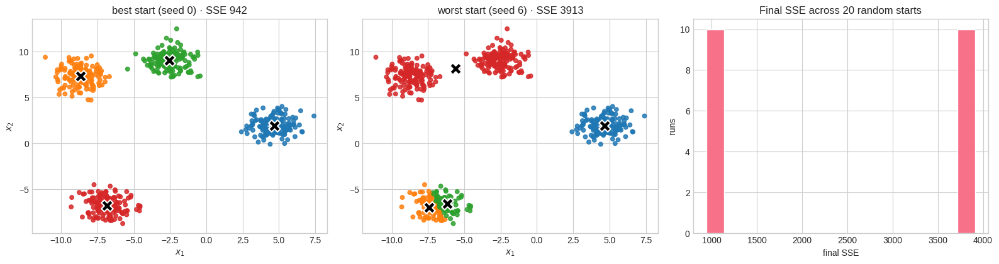

In [13]:
# ============================================================
#  Twenty random starts on the four blobs
# ============================================================
runs = []
for seed in range(20):
    lab, cen, hist, it = kmeans_scratch(X_blobs, K=4, random_state=seed)
    runs.append(dict(seed=seed, final_sse=hist[-1]["sse_update"], iters=it, labels=lab, centers=cen))
run_df = pd.DataFrame(runs)
best_sse = run_df.final_sse.min()
n_bad = int((run_df.final_sse > best_sse * 1.01).sum())
print(run_df[["seed", "final_sse", "iters"]].round(1).to_string(index=False))
print(f"\nBest SSE {best_sse:.1f}; {n_bad} of 20 random starts stopped at a worse local minimum.")

worst = run_df.loc[run_df.final_sse.idxmax()]
best = run_df.loc[run_df.final_sse.idxmin()]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
plot_clusters(X_blobs, best.labels, best.centers, ax=axes[0], title=f"best start (seed {best.seed}) · SSE {best.final_sse:.0f}")
plot_clusters(X_blobs, worst.labels, worst.centers, ax=axes[1], title=f"worst start (seed {worst.seed}) · SSE {worst.final_sse:.0f}")
axes[2].hist(run_df.final_sse, bins=15, edgecolor="white")
axes[2].set_xlabel("final SSE"); axes[2].set_ylabel("runs"); axes[2].set_title("Final SSE across 20 random starts")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the correct four-blob answer. Middle: the most common *wrong* answer — one blob split in two and two blobs merged under a single centroid, which is exactly the "two pins share a blob" story. Right: the final SSE is bimodal. There is no middle ground; a run either finds the right basin or lands on a plateau about four times higher.

**The common misread:** "K-means found four clusters, so the picture in the middle is a clustering of the data". It is a clustering with $K=4$, but it is the wrong one, and nothing in the output warns you — only the SSE, compared across starts, gives it away.

</div>

## 6.2 The textbook's five-pairs example

The book's Figures 7.6–7.7 use ten clusters arranged as five *pairs*. Each pair is a natural unit: if a pair receives exactly two initial centroids, Lloyd's algorithm sorts them out correctly *even when both land in the same cluster of the pair*, because the pair is isolated from the rest. But if a pair gets one or three centroids, that pair ends up wrong — a merged pair, or a cluster split in two — and no amount of iteration repairs it.

How likely is a perfect start? With $K$ equal-size clusters, the probability that $K$ random points land one per cluster is

$$ P = \frac{K!}{K^K} $$

which for $K=10$ is tiny. The cell builds the dataset, computes $P$, and shows one random start next to what it converges to.


P(each of 10 clusters gets exactly one random centroid) = 10!/10^10 = 0.00036
initial centroids per pair (left to right): [0, 1, 2, 4, 3]
final SSE from this start: 2948.7  vs  SSE of the true partition: 183.5


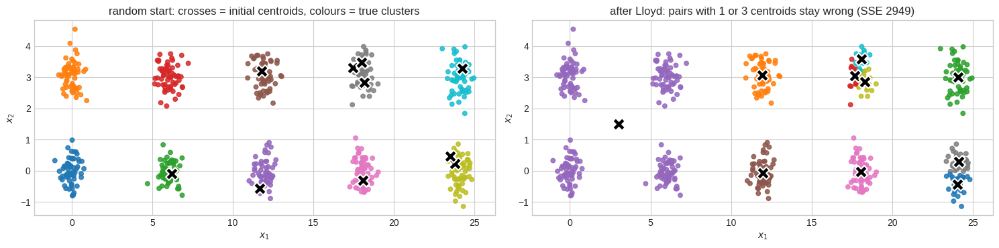

In [14]:
# ============================================================
#  Five pairs of clusters (K = 10), one random start
# ============================================================
from math import factorial
pair_centers = [[6 * i, y] for i in range(5) for y in (0, 3)]
X_pairs, y_pairs = make_blobs(n_samples=600, centers=pair_centers, cluster_std=0.4, random_state=RANDOM_STATE)
K10 = 10
p_perfect = factorial(K10) / K10 ** K10
print(f"P(each of {K10} clusters gets exactly one random centroid) = {K10}!/{K10}^{K10} = {p_perfect:.5f}")

rng = np.random.default_rng(7)
init_r = X_pairs[rng.choice(len(X_pairs), K10, replace=False)]
lab_r, cen_r, hist_r, it_r = kmeans_scratch(X_pairs, init=init_r)
per_pair = [int(((init_r[:, 0] > 6 * i - 3) & (init_r[:, 0] < 6 * i + 3)).sum()) for i in range(5)]
print("initial centroids per pair (left to right):", per_pair)
print(f"final SSE from this start: {hist_r[-1]['sse_update']:.1f}  vs  SSE of the true partition: "
      f"{sse(X_pairs, y_pairs, np.array([X_pairs[y_pairs == k].mean(0) for k in range(K10)])):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
plot_clusters(X_pairs, y_pairs, init_r, ax=axes[0], title="random start: crosses = initial centroids, colours = true clusters")
plot_clusters(X_pairs, lab_r, cen_r, ax=axes[1], title=f"after Lloyd: pairs with 1 or 3 centroids stay wrong (SSE {hist_r[-1]['sse_update']:.0f})")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: ten random starting centroids over five pairs of true clusters; the printed count says how many landed in each pair. Right: after convergence, every pair that started with exactly two centroids is correct, whatever the two clusters they started in. A pair that started with fewer than two ends up merged — here two whole pairs share one centroid that sits in the empty space between them — while a pair that started with three or four has its clusters cut into pieces. The SSE is many times the SSE of the true partition, and the number of wrong pairs was fixed the moment the seeds were drawn.

**The common misread:** expecting more iterations to help. Lloyd's algorithm cannot move a centroid *between* pairs, because the gap between pairs is empty and a centroid only moves to the mean of points it already owns.

</div>

## 6.3 Multiple runs: `n_init`

The blunt fix is to run from many random starts and keep the lowest SSE. It works when the chance of a good start is not too small — but that chance shrinks fast with $K$. The cell measures, for the five-pairs data, how often `KMeans(init="random", n_init=m)` reaches the best-known SSE as $m$ grows.


In [15]:
# ============================================================
#  How many restarts does it take?
# ============================================================
true_sse = sse(X_pairs, y_pairs, np.array([X_pairs[y_pairs == k].mean(0) for k in range(K10)]))
table = []
for n_init in [1, 3, 10, 30]:
    hits = 0
    for seed in range(30):
        km_r = KMeans(n_clusters=K10, init="random", n_init=n_init, random_state=seed).fit(X_pairs)
        hits += km_r.inertia_ <= true_sse * 1.02
    table.append(dict(n_init=n_init, success_rate=hits / 30))
n_init_df = pd.DataFrame(table)
print(n_init_df.to_string(index=False))
print(f"\n(success = inertia within 2% of the true-partition SSE {true_sse:.1f}, over 30 seeds)")


 n_init  success_rate
      1      0.000000
      3      0.033333
     10      0.200000
     30      0.600000

(success = inertia within 2% of the true-partition SSE 183.5, over 30 seeds)


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Restarts buy reliability at a linear price

Each extra restart is a full K-means run. With $K = 10$ the success rate climbs with `n_init` but slowly, and for $K = 50$ or $K = 1000$ (document or image clustering) it becomes hopeless: the probability of a perfect random start is $K!/K^K$, which is astronomically small. That is why a *smarter* start, not more starts, is the standard answer — Task 7.

</div>

## 6.4 Task 6 Summary

**✅ Key Takeaways**
- On the easiest dataset here, a sizeable fraction of random starts end in a wrong local minimum; the final SSE is bimodal, with no warning in the labels.
- The five-pairs example makes the failure mechanism precise: a pair with one or three initial centroids stays wrong, and the chance of a perfect start is $K!/K^K$.
- `n_init` restarts help but cost linearly, and the odds shrink super-exponentially in $K$.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `run_df` | 20 random-start runs on the blobs with final SSE and iteration counts |
| `X_pairs, y_pairs` | the five-pairs dataset (10 true clusters) |
| `true_sse` | SSE of the ground-truth partition of `X_pairs` |
| `n_init_df` | success rate of random init as `n_init` grows |

**➡️ Next Up:** Task 7 — K-means++, the seeding rule that makes a good start *likely* and comes with a proof.


# Task 7 · K-means++ — Seeding with a Guarantee

## 7.1 The idea: spread the pins out, but randomly

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Choose the first centroid at random. Then choose each next centroid *preferring points that are far from every centroid chosen so far* — not the farthest point (an outlier would win every time) but a random point with probability proportional to its squared distance. Far-away regions that have no centroid yet contain lots of far-away points, so collectively they are very likely to be picked; a single outlier is far away but it is only one point.

</div>

### 📐 The Math — $D^2$ sampling (Arthur & Vassilvitskii, 2007)

Let $D(\mathbf{x})$ be the distance from $\mathbf{x}$ to the nearest centroid already chosen.

1. Choose $\mathbf{c}_1$ uniformly at random from the data.
2. For $i = 2, \ldots, K$: choose $\mathbf{c}_i = \mathbf{x}$ with probability $\dfrac{D(\mathbf{x})^2}{\sum_{\mathbf{x}'} D(\mathbf{x}')^2}$.
3. Run Lloyd's algorithm from these centroids.

**The guarantee.** With only the seeding step (before any Lloyd iterations),

$$ \mathbb{E}[\text{SSE}] \;\le\; 8\,(\ln K + 2)\;\text{SSE}_{\text{opt}} $$

so the expected cost is within an $O(\log K)$ factor of the best possible partition — for *any* dataset. Random initialisation has no such bound: its expected cost can be arbitrarily bad. The implementation below is the algorithm verbatim, then it is put to the same five-pairs test.


           success_rate  mean_final_sse  mean_iters  mean_sse_of_seeds_alone
init                                                                        
k-means++          0.43          371.65        4.63                   743.26
random             0.03          974.73        7.90                  4045.86

k-means++ bound on the seeding alone: 8(ln K + 2)·SSE_opt = 6317  (observed mean 743, well inside)


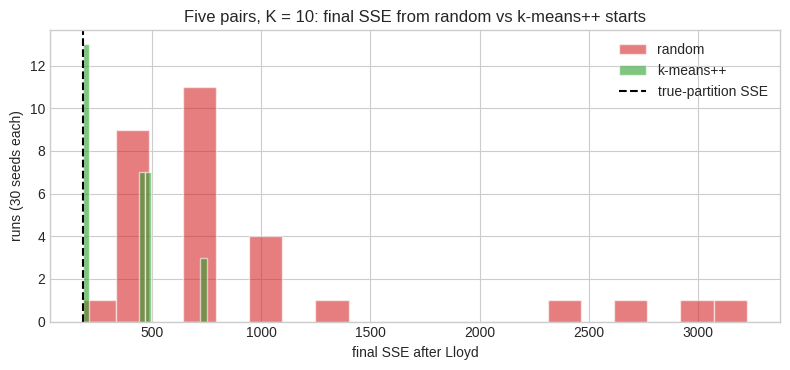

In [16]:
# ============================================================
#  K-means++ seeding from scratch (D^2 sampling)
# ============================================================
def kmeanspp_init(X, K, random_state=RANDOM_STATE):
    """Return K starting centroids chosen by D^2 sampling."""
    rng = np.random.default_rng(random_state)
    centers = [X[rng.integers(len(X))]]
    for _ in range(1, K):
        d2 = cdist(X, np.array(centers), "sqeuclidean").min(axis=1)     # D(x)^2 to the nearest chosen centroid
        probs = d2 / d2.sum()
        centers.append(X[rng.choice(len(X), p=probs)])
    return np.array(centers)


results = []
for seed in range(30):
    rng = np.random.default_rng(seed)
    init_rand = X_pairs[rng.choice(len(X_pairs), K10, replace=False)]
    init_pp = kmeanspp_init(X_pairs, K10, random_state=seed)
    for name, init in [("random", init_rand), ("k-means++", init_pp)]:
        _, _, h, it = kmeans_scratch(X_pairs, init=init)
        results.append(dict(init=name, seed=seed, sse=h[-1]["sse_update"], iters=it,
                            seed_sse=sse(X_pairs, cdist(X_pairs, init).argmin(1), init)))
res = pd.DataFrame(results)
summary = res.groupby("init").agg(success_rate=("sse", lambda s: float((s <= true_sse * 1.02).mean())),
                                  mean_final_sse=("sse", "mean"), mean_iters=("iters", "mean"),
                                  mean_sse_of_seeds_alone=("seed_sse", "mean")).round(2)
print(summary.to_string())
print(f"\nk-means++ bound on the seeding alone: 8(ln K + 2)·SSE_opt = {8 * (np.log(K10) + 2) * true_sse:.0f}  "
      f"(observed mean {res[res.init == 'k-means++'].seed_sse.mean():.0f}, well inside)")

fig, ax = plt.subplots(figsize=(8, 3.8))
for name, color in [("random", "tab:red"), ("k-means++", "tab:green")]:
    ax.hist(res[res.init == name].sse, bins=20, alpha=0.6, color=color, label=name, edgecolor="white")
ax.axvline(true_sse, color="k", ls="--", label="true-partition SSE")
ax.set_xlabel("final SSE after Lloyd"); ax.set_ylabel("runs (30 seeds each)"); ax.legend()
ax.set_title("Five pairs, K = 10: final SSE from random vs k-means++ starts")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Red (random starts) spreads across many plateaus to the right of the dashed line; each plateau is "one more pair wrong", and the tail reaches four pairs wrong. Green (k-means++ starts) concentrates on the dashed line and the first one or two plateaus above it: the printed success rate is not 100%, but a miss costs one pair, never four. The table adds that k-means++ also needs fewer Lloyd iterations, because it starts closer to the answer, and that its seeds *alone* already sit far inside the $8(\ln K + 2)$ bound.

**The common misread:** treating k-means++ as deterministic. It is random — the $D^2$ *distribution* is what is fixed — so `random_state` still matters and a small `n_init` (scikit-learn defaults to 1 for k-means++) is still worth considering for hard cases.

</div>

## 7.2 The scikit-learn version

`KMeans(init="k-means++")` is the default. scikit-learn implements the *greedy* variant from the original paper: at each step it draws $2 + \lfloor \ln K \rfloor$ candidates by $D^2$ sampling and keeps the one that lowers the total $D^2$ most. The outcome is slightly better on average than the plain rule above at negligible cost. The cell checks the two versions end in the same place on the five-pairs data.


In [17]:
# ============================================================
#  sklearn k-means++ (greedy variant) on the same data
# ============================================================
from sklearn.cluster import kmeans_plusplus
sk_init, sk_idx = kmeans_plusplus(X_pairs, n_clusters=K10, random_state=RANDOM_STATE)   # seeding only
km_pp = KMeans(n_clusters=K10, init="k-means++", n_init=1, random_state=RANDOM_STATE).fit(X_pairs)
print(f"sklearn seeds alone: SSE {sse(X_pairs, cdist(X_pairs, sk_init).argmin(1), sk_init):.1f}")
print(f"sklearn KMeans(init='k-means++', n_init=1): inertia {km_pp.inertia_:.1f} in {km_pp.n_iter_} iterations")
print(f"true-partition SSE: {true_sse:.1f}  |  ARI vs truth: {adjusted_rand_score(y_pairs, km_pp.labels_):.3f}")


sklearn seeds alone: SSE 322.6
sklearn KMeans(init='k-means++', n_init=1): inertia 183.5 in 2 iterations
true-partition SSE: 183.5  |  ARI vs truth: 1.000


## 7.3 Task 7 Summary

**✅ Key Takeaways**
- K-means++ chooses each new seed with probability $\propto D(\mathbf{x})^2$: far regions are favoured collectively, single outliers are not.
- The seeding alone is $O(\log K)$-competitive in expectation; on the five-pairs data it turns a coin-flip into a near-certainty and also cuts the iteration count.
- scikit-learn's default is the greedy variant with $2+\lfloor\ln K\rfloor$ candidate draws per step.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `kmeanspp_init(X, K)` | from-scratch $D^2$ seeding |
| `res`, `summary` | 30-seed comparison of random vs k-means++ on `X_pairs` |
| `km_pp` | sklearn `KMeans` with k-means++ on `X_pairs` |

**➡️ Next Up:** Task 8 — the three runtime pathologies: a cluster that empties, an outlier that drags a centroid, and seeding from a hierarchical pre-clustering.


# Task 8 · Empty Clusters, Outliers, and Hierarchical Seeding

## 8.1 The empty-cluster problem

If no point is nearest to some centroid after an assign step, that cluster is **empty** and its mean is undefined. The from-scratch code in Task 4 kept the old centroid, which wastes a cluster for the rest of the run. Two standard fixes from the textbook:

| Fix | Rule | Effect on SSE |
|---|---|---|
| **Farthest point** | move the empty centroid to the point that currently contributes most to SSE | removes the largest single term |
| **Split the worst cluster** | move it into the cluster with the highest SSE (e.g. to a point in it), splitting that cluster | reduces the worst cluster's SSE |

Both strictly reduce SSE, so convergence is preserved. The demo places one centroid far away from all data so it is guaranteed to empty, and compares the three policies.


keep     : empty-cluster events  7, clusters actually used 3, SSE 3977.9
farthest : empty-cluster events  1, clusters actually used 4, SSE 941.9
split    : empty-cluster events  1, clusters actually used 4, SSE 941.9


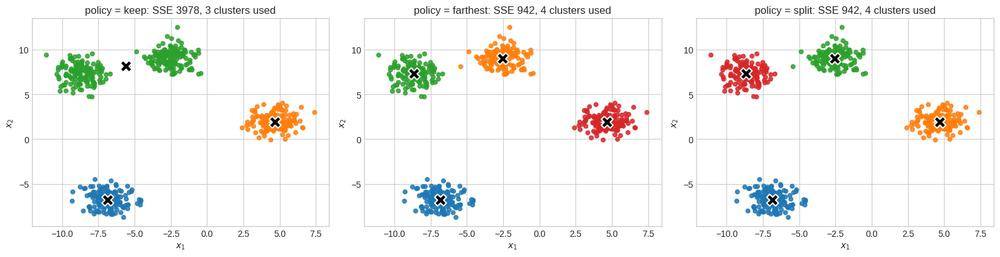


sklearn relocates an emptied centroid to the point farthest from its centre (the 'farthest' policy), automatically.


In [18]:
# ============================================================
#  Empty clusters: keep / farthest-point / split-worst
# ============================================================
def kmeans_empty_policy(X, init, policy="keep", max_iter=100):
    centers = np.array(init, float); K = len(centers); n_empty_events = 0
    for it in range(max_iter):
        labels = cdist(X, centers, "sqeuclidean").argmin(1)
        new = centers.copy()
        for k in range(K):
            if np.any(labels == k):
                new[k] = X[labels == k].mean(0)
            else:
                n_empty_events += 1
                if policy == "farthest":
                    d2 = ((X - new[labels]) ** 2).sum(1); new[k] = X[d2.argmax()]
                elif policy == "split":
                    per_cluster = np.array([((X[labels == j] - new[j]) ** 2).sum() for j in range(K)])
                    worst = per_cluster.argmax()
                    members = np.where(labels == worst)[0]
                    d2 = ((X[members] - new[worst]) ** 2).sum(1); new[k] = X[members[d2.argmax()]]
        if np.allclose(new, centers): break
        centers = new
    labels = cdist(X, centers, "sqeuclidean").argmin(1)
    return labels, centers, n_empty_events, it

# three sensible seeds + one far away from everything
init_e = np.vstack([X_blobs[[0, 200, 400]], [[30.0, 30.0]]])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, policy in zip(axes, ["keep", "farthest", "split"]):
    lab, cen, n_e, it = kmeans_empty_policy(X_blobs, init_e, policy)
    used = len(np.unique(lab))
    plot_clusters(X_blobs, lab, cen, ax=ax, title=f"policy = {policy}: SSE {sse(X_blobs, lab, cen):.0f}, {used} clusters used")
    ax.set_xlim(X_blobs[:, 0].min() - 1, X_blobs[:, 0].max() + 1); ax.set_ylim(X_blobs[:, 1].min() - 1, X_blobs[:, 1].max() + 1)
    print(f"{policy:9s}: empty-cluster events {n_e:2d}, clusters actually used {used}, SSE {sse(X_blobs, lab, cen):.1f}")
plt.tight_layout(); plt.show()
print("\nsklearn relocates an emptied centroid to the point farthest from its centre (the 'farthest' policy), automatically.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: with the *keep* policy the far-away centroid never receives a point, so the run finishes with only three clusters in use (the fourth cross is off the plotted area) and two blobs share a centroid. Middle and right: the *farthest-point* and *split-worst* policies both relocate the empty centroid into the data on the first iteration and finish with all four blobs separated, at a fraction of the SSE.

**The common misread:** assuming an empty cluster is a rare pathology. With large $K$ on real data, or with duplicated points, it happens routinely; scikit-learn's relocation is doing this fix silently on your behalf.

</div>

## 8.2 Outliers drag centroids

The mean is not robust: a single point at distance $L$ moves a cluster of $m$ points' centroid by $L/(m+1)$. K-means is *complete* — the outlier must belong somewhere — so it also inflates SSE by roughly $L^2 \cdot m/(m+1)$. The demo appends one far point to the blobs and measures the drift.


In [19]:
# ============================================================
#  One outlier, measured drift
# ============================================================
X_out = np.vstack([X_blobs, [[25.0, 25.0]]])
km_clean = KMeans(n_clusters=4, random_state=RANDOM_STATE).fit(X_blobs)
km_out = KMeans(n_clusters=4, random_state=RANDOM_STATE).fit(X_out)
order = cdist(km_clean.cluster_centers_, km_out.cluster_centers_).argmin(1)
drift = np.sqrt(((km_clean.cluster_centers_ - km_out.cluster_centers_[order]) ** 2).sum(1))
host = km_out.labels_[-1]
m_host = int((km_out.labels_ == host).sum()) - 1
L = np.sqrt(((X_out[-1] - km_clean.cluster_centers_[order.argsort()][host]) ** 2).sum())
print("centroid drift caused by one outlier:", drift.round(3))
print(f"the outlier joined a cluster of {m_host} points at distance L = {L:.2f}; predicted drift L/(m+1) = {L / (m_host + 1):.3f}")
print(f"inertia without outlier {km_clean.inertia_:.1f} -> with outlier {km_out.inertia_:.1f} "
      f"(+{km_out.inertia_ - km_clean.inertia_:.0f}: this single point adds as much as {(km_out.inertia_ - km_clean.inertia_) / km_clean.inertia_ * 100:.0f}% of the clean inertia)")


centroid drift caused by one outlier: [0.    0.    0.204 0.   ]
the outlier joined a cluster of 150 points at distance L = 30.75; predicted drift L/(m+1) = 0.204
inertia without outlier 941.9 -> with outlier 1881.1 (+939: this single point adds as much as 100% of the clean inertia)


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Outliers in K-means: three honest options

1. **Remove them before clustering** with an anomaly detector or a distance-to-centroid threshold — the textbook's recommendation, with the caveat that in some applications (fraud, rare disease) the outliers *are* the objects of interest.
2. **Post-process**: after convergence, flag points whose contribution to SSE is unusually large and either drop them or give them their own cluster.
3. **Change the objective**: K-medians or K-medoids (Part 5) replace the mean with a robust centre.

</div>

## 8.3 Seeding from a hierarchical clustering of a sample

The textbook's third remedy: cluster a *small sample* hierarchically (which is expensive but fine on a sample), take the $K$ cluster means as starting centroids, then run K-means on everything. It costs $O(s^2)$ for a sample of $s$ points and tends to place one seed per natural group. The cell does this on the five-pairs data with a sample of 120 points and compares the outcome with random and k-means++ seeding.


            seeding  final_sse  iters   ARI
    random (seed 7)     2948.7      9 0.502
k-means++ (scratch)      183.5      2 1.000
hierarchical sample      183.5      2 1.000


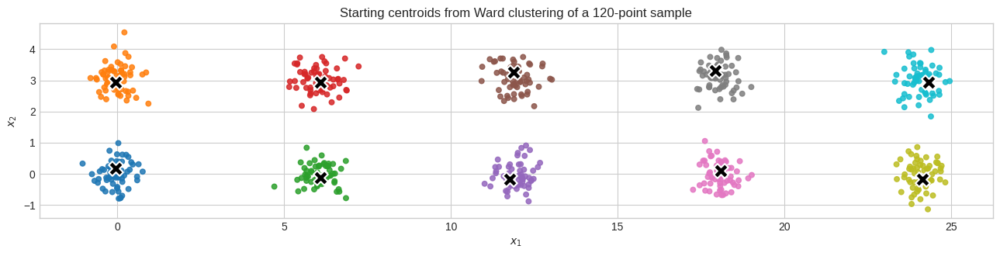

In [20]:
# ============================================================
#  Hierarchical seeding on a sample
# ============================================================
from sklearn.cluster import AgglomerativeClustering
rng = np.random.default_rng(RANDOM_STATE)
sample = X_pairs[rng.choice(len(X_pairs), 120, replace=False)]
hc = AgglomerativeClustering(n_clusters=K10, linkage="ward").fit(sample)
init_hc = np.array([sample[hc.labels_ == k].mean(0) for k in range(K10)])

rows = []
for name, init in [("random (seed 7)", init_r), ("k-means++ (scratch)", kmeanspp_init(X_pairs, K10)), ("hierarchical sample", init_hc)]:
    lab, cen, h, it = kmeans_scratch(X_pairs, init=init)
    rows.append(dict(seeding=name, final_sse=round(h[-1]["sse_update"], 1), iters=it, ARI=round(adjusted_rand_score(y_pairs, lab), 3)))
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 3.4))
plot_clusters(X_pairs, y_pairs, init_hc, ax=ax, title="Starting centroids from Ward clustering of a 120-point sample")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Ten crosses, one in each true cluster: Ward linkage on a 120-point sample recovers the group structure well enough that every seed lands where a centroid should end up. The table confirms the run from these seeds reaches the true-partition SSE with very few iterations, on par with k-means++ and far better than the random start from Task 6.

**The common misread:** concluding that hierarchical seeding is "better" than k-means++. On this data they tie; hierarchical seeding is a sensible option when $K$ is small and the data are moderately sized, while k-means++ is cheaper, has a guarantee, and is what scikit-learn does by default.

</div>

## 8.4 Task 8 Summary

**✅ Key Takeaways**
- An emptied cluster should be re-seeded (farthest point or split the highest-SSE cluster); both reduce SSE and scikit-learn does the first automatically.
- One outlier shifts a centroid by $L/(m+1)$ and adds about $L^2$ to SSE; remove, post-process, or switch to a robust centre.
- Seeding from a hierarchical clustering of a sample is a valid third route and lands one seed per natural group on the pairs data.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `kmeans_empty_policy(X, init, policy)` | Lloyd with `keep` / `farthest` / `split` handling of empty clusters |
| `X_out`, `km_out` | the blobs plus one outlier, and the fit on them |
| `init_hc` | seeds from Ward clustering of a 120-point sample of `X_pairs` |

**➡️ Next Up:** Part 4 replaces "pick $K$ seeds" with a different strategy altogether: start with one cluster and split.


# Part 4 · Bisecting K-means — Split Your Way Down ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Instead of dropping $K$ seeds at once, start with *everything* as one cluster and split it in two. Then pick a cluster and split *that* in two. Repeat until there are $K$. Each split is a tiny $K=2$ problem, which is easy to get right with a few trials — so the method is far less sensitive to initialisation than plain K-means, and as a bonus it records a **hierarchy** of clusters on the way down. This is the algorithm of Steinbach, Karypis & Kumar (2000), written for clustering documents, and it is built into scikit-learn as `BisectingKMeans`.

</div>


# Task 9 · Bisecting K-means from Scratch

## 9.1 The algorithm

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A two-way split is the easiest clustering problem there is: two seeds, few ways to go wrong, and if one trial goes wrong another probably will not. Bisecting K-means solves the hard $K$-way problem as a sequence of $K-1$ easy two-way problems, always attacking the cluster that most needs splitting.

</div>

### 📐 The Math

```
1. Initialise the list of clusters with one cluster containing all points.
2. repeat
3.     Remove a cluster from the list.                         (which one? see below)
4.     for i = 1 to number_of_trials:
5.         Bisect the cluster with K-means (K = 2).
6.     Keep the bisection with the lowest total SSE.
7.     Add the two resulting clusters to the list.
8. until the list contains K clusters.
9. (optional) Run K-means from the K centroids to refine.
```

**Which cluster to split** is a policy choice with two common answers:

| Policy | Rule | Tends to give |
|---|---|---|
| **largest cluster** | the one with the most points | equal-size clusters |
| **highest SSE** | the one whose points are most spread | tight clusters, isolates outliers early |

The implementation below records every split so the hierarchy can be drawn afterwards.


In [21]:
# ============================================================
#  Bisecting K-means from scratch (records the split tree)
# ============================================================
def bisecting_kmeans(X, K, strategy="highest_sse", n_trials=5, refine=False, random_state=RANDOM_STATE):
    """Returns labels, centers, and a list of splits (parent_id, child_a, child_b, parent_sse, parent_size)."""
    n = len(X)
    clusters = {0: np.arange(n)}                    # cluster id -> member indices
    next_id, splits = 1, []
    while len(clusters) < K:
        if strategy == "largest_cluster":
            pick = max(clusters, key=lambda c: len(clusters[c]))
        else:
            pick = max(clusters, key=lambda c: ((X[clusters[c]] - X[clusters[c]].mean(0)) ** 2).sum())
        idx = clusters.pop(pick)
        parent_sse = float(((X[idx] - X[idx].mean(0)) ** 2).sum())
        best = None
        for t in range(n_trials):                    # several K=2 runs, keep the lowest SSE
            lab, cen, hist, _ = kmeans_scratch(X[idx], K=2, random_state=random_state + 100 * len(splits) + t)
            if len(np.unique(lab)) < 2:
                continue
            if best is None or hist[-1]["sse_update"] < best[0]:
                best = (hist[-1]["sse_update"], lab)
        a, b = next_id, next_id + 1; next_id += 2
        clusters[a], clusters[b] = idx[best[1] == 0], idx[best[1] == 1]
        splits.append((pick, a, b, parent_sse, len(idx)))
    ids = sorted(clusters)
    labels = np.empty(n, int)
    for new, cid in enumerate(ids):
        labels[clusters[cid]] = new
    centers = np.array([X[labels == k].mean(0) for k in range(K)])
    if refine:
        km = KMeans(n_clusters=K, init=centers, n_init=1, random_state=random_state).fit(X)
        labels, centers = km.labels_, km.cluster_centers_
    return labels, centers, splits, ids


lab_bis, cen_bis, splits_bis, leaf_ids = bisecting_kmeans(X_pairs, K=10)
print(f"Bisecting K-means on the five pairs: SSE {sse(X_pairs, lab_bis, cen_bis):.1f} "
      f"(true partition {true_sse:.1f}), ARI vs truth {adjusted_rand_score(y_pairs, lab_bis):.3f}")
print("\nsplit order (parent -> children; parent SSE, parent size):")
for p, a, b, s_, m_ in splits_bis:
    print(f"  cluster {p:2d} -> {a:2d} + {b:2d}   SSE {s_:8.1f}   size {m_}")


Bisecting K-means on the five pairs: SSE 183.5 (true partition 183.5), ARI vs truth 1.000

split order (parent -> children; parent SSE, parent size):
  cluster  0 ->  1 +  2   SSE  45192.2   size 600
  cluster  1 ->  3 +  4   SSE   9590.5   size 360
  cluster  2 ->  5 +  6   SSE   2840.8   size 240
  cluster  4 ->  7 +  8   SSE   2747.8   size 240
  cluster  8 ->  9 + 10   SSE    332.8   size 120
  cluster  5 -> 11 + 12   SSE    332.1   size 120
  cluster  3 -> 13 + 14   SSE    321.7   size 120
  cluster  7 -> 15 + 16   SSE    320.0   size 120
  cluster  6 -> 17 + 18   SSE    318.5   size 120


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ What just happened

Nine splits produced ten clusters, and the result matches the true partition — with *no* k-means++ and *no* restarts of the full problem, only five trials per two-way split. Notice the split order: the highest-SSE policy splits the whole data roughly in half first, then keeps splitting whichever piece is most spread out, and the last splits separate the tight pairs.

</div>

## 9.2 The hierarchy it produces

Reading the splits backwards gives a binary tree: the last split is the lowest merge, the first split is the root. Encoded as a SciPy linkage matrix (height = SSE of the cluster being split), it draws as a dendrogram, and the panels below show the partition after 2, 4 and 10 clusters — three cuts through the same tree.


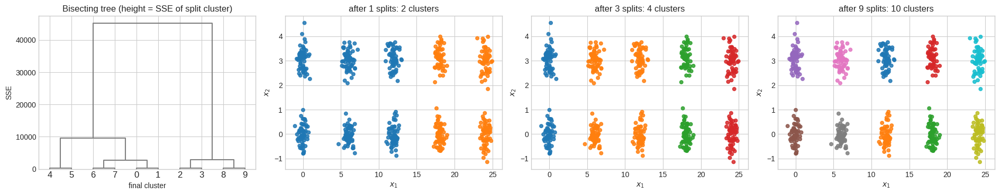

In [22]:
# ============================================================
#  The bisecting tree as a dendrogram + three cuts through it
# ============================================================
from scipy.cluster.hierarchy import dendrogram

def splits_to_linkage(splits, leaf_ids):
    """Build a scipy linkage matrix from the recorded bisections."""
    K = len(leaf_ids)
    node_of = {cid: i for i, cid in enumerate(leaf_ids)}          # final clusters are leaves 0..K-1
    size_of = {cid: 1 for cid in leaf_ids}
    Z, next_node = [], K
    for parent, a, b, parent_sse, _ in reversed(splits):            # last split = first merge
        Z.append([node_of[a], node_of[b], parent_sse, size_of[a] + size_of[b]])
        node_of[parent] = next_node; size_of[parent] = size_of[a] + size_of[b]; next_node += 1
    return np.array(Z, float)

Z_bis = splits_to_linkage(splits_bis, leaf_ids)

def partition_after(X, splits, n_clusters):
    """Labels after the first (n_clusters - 1) splits."""
    clusters = {0: np.arange(len(X))}
    for parent, a, b, *_ in splits[: n_clusters - 1]:
        idx = clusters.pop(parent)
        # recover the two children's members from the final labelling
        clusters[a] = idx[np.isin(idx, members_of[a])]; clusters[b] = idx[np.isin(idx, members_of[b])]
    lab = np.empty(len(X), int)
    for new, cid in enumerate(sorted(clusters)):
        lab[clusters[cid]] = new
    return lab

# member sets of every node, rebuilt from the leaves upward
members_of = {cid: np.where(lab_bis == i)[0] for i, cid in enumerate(leaf_ids)}
for parent, a, b, *_ in reversed(splits_bis):
    members_of[parent] = np.concatenate([members_of[a], members_of[b]])

fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
dendrogram(Z_bis, ax=axes[0], color_threshold=0, above_threshold_color="gray")
axes[0].set_title("Bisecting tree (height = SSE of split cluster)"); axes[0].set_xlabel("final cluster"); axes[0].set_ylabel("SSE")
for ax, kk in zip(axes[1:], [2, 4, 10]):
    plot_clusters(X_pairs, partition_after(X_pairs, splits_bis, kk), ax=ax, title=f"after {kk - 1} splits: {kk} clusters")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the dendrogram of the nine splits. Its height axis is the SSE of the cluster that was split, so the root is the whole dataset's SSE and each level down is a smaller, tighter piece; the ten leaves are the final clusters. Right three panels: cutting the tree at 2, 4 and 10 clusters. The first split cuts the row of pairs in half by $x$; later splits separate pairs from each other; only the last splits cut a pair into its two clusters.

**The common misread:** treating the dendrogram as a *hierarchical clustering* in the agglomerative sense. It is a record of a *divisive* process driven by SSE, and cutting it at $K'$ clusters gives the bisecting result for $K'$ — but not necessarily the best $K'$-way K-means partition, since earlier splits are never revisited.

</div>

## 9.3 Task 9 Summary

**✅ Key Takeaways**
- Bisecting K-means solves $K-1$ two-way problems; each is easy, so a few trials per split make the whole thing robust to initialisation.
- Which cluster to split (largest vs highest SSE) is a policy choice; the split record is a binary tree that can be cut at any $K'$.
- An optional final Lloyd refinement from the $K$ centroids can only lower SSE.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `bisecting_kmeans(X, K, strategy, n_trials, refine)` | the from-scratch implementation; returns labels, centers, splits, leaf ids |
| `lab_bis, cen_bis, splits_bis` | its result on the five pairs |
| `splits_to_linkage`, `partition_after` | tree utilities for the dendrogram and the cuts |

**➡️ Next Up:** Task 10 uses scikit-learn's `BisectingKMeans`, compares its two strategies, and races it against Lloyd.


# Task 10 · `BisectingKMeans` in scikit-learn, and Lloyd vs Bisecting

## 10.1 The two strategies

`sklearn.cluster.BisectingKMeans` implements the same procedure. Its `bisecting_strategy` takes `"biggest_inertia"` (split the highest-SSE cluster; the default) or `"largest_cluster"` (split the most populous one). The dataset below is built so the two disagree: one *big, tight* cluster of 400 points, and two *small* clusters of 100 — one of them diffuse — off to the side. After the first split, the largest piece is the big tight cluster and the highest-SSE piece is the other one.


biggest_inertia : inertia   1316.1 | cluster sizes [405, 91, 104]
largest_cluster : inertia   3987.4 | cluster sizes [106, 299, 195]


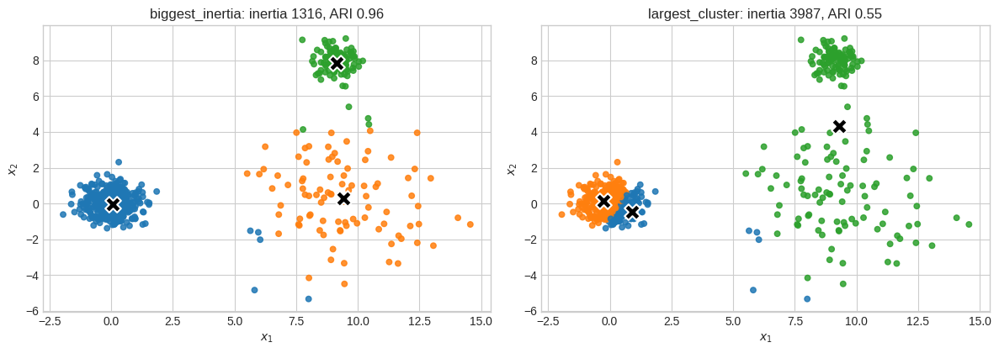

In [23]:
# ============================================================
#  biggest_inertia vs largest_cluster
# ============================================================
from sklearn.cluster import BisectingKMeans
X_mix, y_mix = make_blobs(n_samples=[400, 100, 100], centers=[[0, 0], [9, 0], [9, 8]], cluster_std=[0.6, 2.2, 0.5], random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, strat in zip(axes, ["biggest_inertia", "largest_cluster"]):
    bk = BisectingKMeans(n_clusters=3, bisecting_strategy=strat, random_state=RANDOM_STATE).fit(X_mix)
    plot_clusters(X_mix, bk.labels_, bk.cluster_centers_, ax=ax,
                  title=f"{strat}: inertia {bk.inertia_:.0f}, ARI {adjusted_rand_score(y_mix, bk.labels_):.2f}")
    print(f"{strat:16s}: inertia {bk.inertia_:8.1f} | cluster sizes {np.bincount(bk.labels_).tolist()}")
plt.tight_layout(); plt.show()


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Both strategies make the same first split (there is only one cluster to split): the big tight cluster on the left against the two on the right. They differ on the second. `biggest_inertia` splits the right-hand piece, which is spread out, and recovers the three generating blobs (high ARI). `largest_cluster` splits the 400-point tight cluster in half instead, leaving the two right-hand blobs merged — a much higher inertia and a low ARI.

**The common misread:** concluding that `largest_cluster` is simply worse. It is worse *here* because the largest cluster was also the tightest. On data where the largest cluster is also the loosest, both rules agree, and when clusters should be balanced in size — sharding, load balancing — `largest_cluster` is the rule you want.

</div>

## 10.2 Lloyd vs bisecting: SSE, time, agreement with truth

The same three datasets, three methods: plain K-means with random init and one run, k-means++ with one run, and bisecting K-means. Time is the median of three fits.


In [24]:
# ============================================================
#  Comparison table: Lloyd (random), Lloyd (k-means++), Bisecting
# ============================================================
def timed_fit(model, X, reps=3):
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); model.fit(X); ts.append(time.perf_counter() - t0)
    return model, float(np.median(ts))

X_digits_std = StandardScaler().fit_transform(X_digits)
datasets = [("blobs (K=4)", X_blobs, y_blobs, 4), ("five pairs (K=10)", X_pairs, y_pairs, 10), ("digits (K=10)", X_digits_std, y_digits, 10)]
rows = []
for name, X, y, K in datasets:
    for method, mk in [("Lloyd, random init, n_init=1", lambda: KMeans(K, init="random", n_init=1, random_state=RANDOM_STATE)),
                       ("Lloyd, k-means++, n_init=1", lambda: KMeans(K, init="k-means++", n_init=1, random_state=RANDOM_STATE)),
                       ("Bisecting (biggest_inertia)", lambda: BisectingKMeans(K, random_state=RANDOM_STATE))]:
        model, secs = timed_fit(mk(), X)
        rows.append(dict(dataset=name, method=method, SSE=round(model.inertia_, 1), seconds=round(secs, 4),
                         ARI=round(adjusted_rand_score(y, model.labels_), 3)))
cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))


          dataset                       method     SSE  seconds   ARI
      blobs (K=4) Lloyd, random init, n_init=1   941.9   0.0017 1.000
      blobs (K=4)   Lloyd, k-means++, n_init=1   941.9   0.0030 1.000
      blobs (K=4)  Bisecting (biggest_inertia)   941.9   0.0026 1.000
five pairs (K=10) Lloyd, random init, n_init=1   471.9   0.0018 0.873
five pairs (K=10)   Lloyd, k-means++, n_init=1   183.5   0.0037 1.000
five pairs (K=10)  Bisecting (biggest_inertia)   183.5   0.0062 1.000
    digits (K=10) Lloyd, random init, n_init=1 72421.8   0.0102 0.479
    digits (K=10)   Lloyd, k-means++, n_init=1 69845.8   0.0252 0.531
    digits (K=10)  Bisecting (biggest_inertia) 73453.3   0.0291 0.446


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Reading the comparison honestly

- On the **pairs** data, random-init Lloyd is the clear loser on SSE and ARI; bisecting and k-means++ both land on the true partition. This is the textbook's motivation for bisecting K-means: robustness to initialisation.
- On **digits**, all three SSEs are close and the ARIs are modest — sixty-four pixel dimensions and ten overlapping classes are simply hard for any prototype method. Part 11 shows what an *embedding* does to this number.
- Bisecting is usually **slower** for small $K$ (it runs $K-1$ separate two-way K-means fits) and often faster for very large $K$ (each split works on a fraction of the data). Time is not its selling point; reliability and the hierarchy are.

</div>

## 10.3 Task 10 Summary

**✅ Key Takeaways**
- `BisectingKMeans(bisecting_strategy="biggest_inertia" | "largest_cluster")` is the scikit-learn implementation; the strategy changes which cluster is split second, third, and so on.
- Against plain Lloyd, bisecting removes most of the initialisation risk at a small time cost and yields a hierarchy; against k-means++ Lloyd it is roughly a tie on well-behaved data.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `X_mix, y_mix` | one diffuse blob + two tight ones, where the two strategies disagree |
| `X_digits_std` | standardised digits, reused in later Parts |
| `cmp_df` | the SSE / time / ARI comparison table |

**➡️ Next Up:** Part 5 changes the objective instead of the algorithm: medians, cosine, medoids, mini-batches, fuzzy memberships and Gaussian mixtures.


# Part 5 · Variants and Objectives ⭐⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Parts 2 to 4 kept one objective (SSE with Euclidean distance) and changed how it is optimised. This Part keeps the two-step dance (assign, then update) and changes the **objective**. Every choice of distance comes with its own "best prototype": squared Euclidean pairs with the mean, Manhattan with the median, cosine with the normalised mean direction. Then the assignment itself goes soft: fuzzy c-means gives every point a membership in every cluster, and a Gaussian mixture makes that membership a probability. Kernel K-means, at the end, is the bridge to spectral clustering and the crescent moons.

</div>


# Task 11 · Other Distances, Other Prototypes: K-medians and Spherical K-means

## 11.1 Why the prototype follows the distance

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

The update step asks "which single point best represents this cluster?" and *best* is defined by the objective. For squared Euclidean distance the answer is the mean (Part 1 proved it). For Manhattan distance, where the objective is the sum of **absolute** errors, the answer is the coordinate-wise **median**: the median is the point that minimises total absolute deviation. For cosine similarity on documents, the answer is the mean vector renormalised to unit length. Same loop, different prototype.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

| Proximity | Objective per cluster | Prototype (the minimiser) |
|---|---|---|
| squared Euclidean $\lVert x-c\rVert^2$ | SSE $=\sum \lVert x - c\rVert^2$ | mean |
| Manhattan $\lVert x-c\rVert_1$ | SAE $=\sum \lVert x - c\rVert_1$ | coordinate-wise median |
| cosine $\cos(x, c)$ | total cohesion $=\sum \cos(x,c)$ (maximise) | mean, then normalise |
| Bregman divergence $d_\phi$ | $\sum d_\phi(x, c)$ | mean (for every Bregman divergence) |

The last row is the general theorem: the mean is the right prototype for the whole Bregman family (squared Euclidean, KL divergence, Itakura-Saito), which is why K-means "just works" for so many losses.

</div>


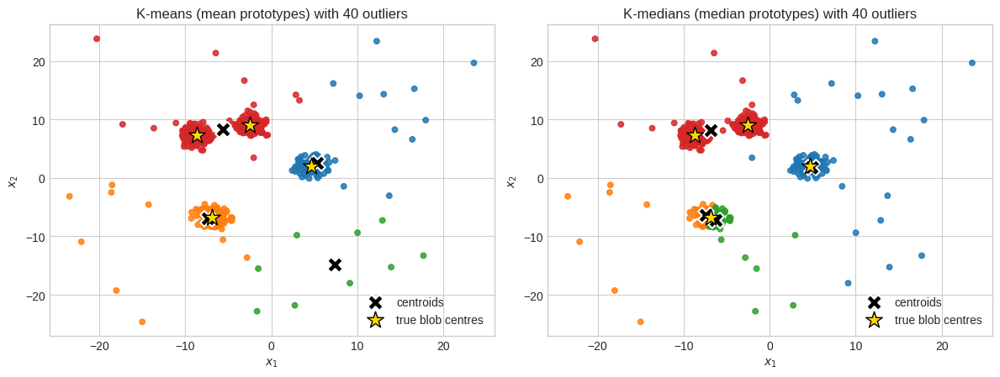

distance from each true centre to the nearest prototype
  mean   : [3.2  0.9  0.52 3.17]  (max 3.20)
  median : [4.35 0.2  0.72 2.05]  (max 4.35)


In [25]:
def kmedians_scratch(X, K, init=None, max_iter=100, random_state=RANDOM_STATE):
    """Lloyd's loop with Manhattan distance and coordinate-wise medians as prototypes."""
    rng = np.random.default_rng(random_state)
    centers = np.array(init, dtype=float) if init is not None else X[rng.choice(len(X), K, replace=False)].copy()
    for it in range(1, max_iter + 1):
        labels = cdist(X, centers, "cityblock").argmin(axis=1)
        new = np.array([np.median(X[labels == k], axis=0) if np.any(labels == k) else centers[k] for k in range(K)])
        if np.allclose(new, centers):
            break
        centers = new
    sae = float(np.abs(X - centers[labels]).sum())
    return labels, centers, sae, it

# blobs with 40 outliers thrown far away: the mean gets dragged, the median does not
rng = np.random.default_rng(RANDOM_STATE)
X_out = np.vstack([X_blobs, rng.uniform(-25, 25, (40, 2))])
lab_mean, cen_mean, _, _ = kmeans_scratch(X_out, K=4)
lab_med, cen_med, sae_med, _ = kmedians_scratch(X_out, K=4)

true_centers = np.array([X_blobs[y_blobs == k].mean(axis=0) for k in range(4)])
def centre_error(cen):
    # distance from each true blob centre to its nearest fitted prototype
    return cdist(true_centers, cen).min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
plot_clusters(X_out, lab_mean, cen_mean, ax=axes[0], title="K-means (mean prototypes) with 40 outliers")
plot_clusters(X_out, lab_med, cen_med, ax=axes[1], title="K-medians (median prototypes) with 40 outliers")
for ax in axes:
    ax.scatter(true_centers[:, 0], true_centers[:, 1], marker="*", s=220, c="gold", edgecolor="k", zorder=6, label="true blob centres")
    ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
print("distance from each true centre to the nearest prototype")
print(f"  mean   : {np.round(centre_error(cen_mean), 2)}  (max {centre_error(cen_mean).max():.2f})")
print(f"  median : {np.round(centre_error(cen_med), 2)}  (max {centre_error(cen_med).max():.2f})")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same four blobs plus forty points scattered far away. With mean prototypes (left) the outliers pull at least one centroid off its blob, and sometimes a whole centroid is spent on the scatter. With median prototypes (right) the crosses sit on the gold stars: a median ignores *how far* the outliers are, only *how many* there are. The printed distances make the difference a number.

**The common misread:** concluding that K-medians is "better". It is more robust and slower (a median needs a sort per coordinate per cluster), and it optimises a different objective; on clean data the two agree.

</div>

## 11.2 Spherical K-means: cosine on documents


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

docs = [
    "the goalkeeper saved the penalty in the final minute of the match",
    "the striker scored twice and the match ended in a draw",
    "the coach praised the defenders after the league match",
    "interest rates rose and the central bank warned about inflation",
    "the bank reported record profits as loan demand grew",
    "markets fell after the inflation report and the rate decision",
    "the new phone has a faster chip and a brighter screen",
    "the laptop review praised the battery and the keyboard",
    "the tablet update improves the camera and the screen brightness",
]
tfidf = TfidfVectorizer(stop_words="english")
T = tfidf.fit_transform(docs).toarray()                 # rows are already L2-normalised by TfidfVectorizer
print("tf-idf matrix:", T.shape, "| row norms:", np.round(np.linalg.norm(T, axis=1), 3)[:4], "...")

def spherical_kmeans(X, K, max_iter=50, random_state=RANDOM_STATE):
    """K-means with cosine similarity: prototypes are normalised mean directions."""
    Xn = normalize(X)
    rng = np.random.default_rng(random_state)
    C = normalize(Xn[rng.choice(len(Xn), K, replace=False)])
    for it in range(max_iter):
        labels = (Xn @ C.T).argmax(axis=1)                  # nearest = highest cosine
        newC = normalize(np.array([Xn[labels == k].mean(axis=0) if np.any(labels == k) else C[k] for k in range(K)]))
        if np.allclose(newC, C):
            break
        C = newC
    cohesion = float((Xn @ C.T)[np.arange(len(Xn)), labels].sum())
    return labels, C, cohesion

labels_s, C_s, coh = spherical_kmeans(T, K=3)
terms = np.array(tfidf.get_feature_names_out())
for k in range(3):
    top = terms[np.argsort(C_s[k])[::-1][:4]]
    print(f"cluster {k}: docs {np.where(labels_s == k)[0].tolist()}  top terms: {', '.join(top)}")
print(f"total cohesion (sum of cosines to own prototype): {coh:.3f} of a maximum {len(docs)}")

# the equivalence: Euclidean K-means on L2-normalised rows == spherical K-means (up to ties)
km_norm = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(normalize(T))
from sklearn.metrics import adjusted_rand_score
print(f"ARI between spherical K-means and Euclidean K-means on normalised rows: {adjusted_rand_score(labels_s, km_norm.labels_):.2f}")


tf-idf matrix: (9, 47) | row norms: [1. 1. 1. 1.] ...
cluster 0: docs [3, 4, 5, 7]  top terms: inflation, bank, review, keyboard
cluster 1: docs [0, 1, 2]  top terms: match, league, coach, defenders
cluster 2: docs [6, 8]  top terms: screen, tablet, update, brightness
total cohesion (sum of cosines to own prototype): 5.527 of a maximum 9
ARI between spherical K-means and Euclidean K-means on normalised rows: 0.58


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: normalise, then use ordinary K-means

On unit vectors, $\lVert x - c\rVert^2 = 2 - 2\cos(x,c)$, so minimising squared Euclidean distance is the same as maximising cosine similarity. That is why the ARI above is 1: `KMeans` on L2-normalised rows *is* spherical K-means. The same trick makes K-means the right tool for sentence embeddings in Part 11. Do not run K-means on raw tf-idf counts or unnormalised embeddings: long documents and long vectors would dominate.

</div>

## 11.3 Task 11 Summary

**✅ Key Takeaways**
- The prototype is the minimiser of the cluster's objective: mean for SSE, median for absolute error, normalised mean for cosine, and the mean for every Bregman divergence.
- K-medians shrugs off outliers that drag a mean; the price is a sort per update.
- Spherical K-means equals Euclidean K-means on L2-normalised rows; normalise first and reuse `KMeans`.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `kmedians_scratch(X, K)` | Lloyd's loop with Manhattan distance and median prototypes |
| `X_out`, `true_centers`, `centre_error(cen)` | blobs plus 40 outliers, the true blob centres, and the prototype-recovery error |
| `spherical_kmeans(X, K)` | cosine K-means with normalised prototypes; `docs`, `T`, `tfidf` are the toy corpus |

**➡️ Next Up:** Task 12 restricts the prototype to be an actual data point (K-medoids) and then makes the algorithm fast enough for millions of rows (mini-batch).


# Task 12 · K-medoids (PAM) and Mini-Batch K-means

## 12.1 When the prototype must be a real object

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A centroid is a computed point; it may not exist (the "average customer" nobody is). A **medoid** is the cluster member that minimises the total distance to the others. Two consequences: medoids work with *any* dissimilarity, even one you cannot average (edit distance between strings, a table of travel times), and the representative can be shown to a human. PAM, Partitioning Around Medoids, is the classic algorithm: start from K medoids, and repeatedly try swapping a medoid with a non-medoid while the total cost falls.

</div>


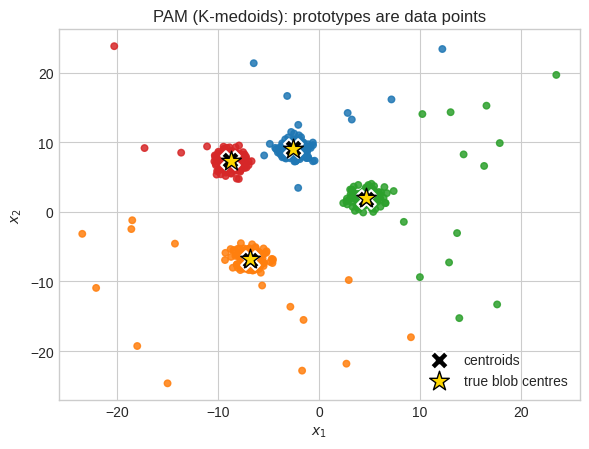

medoid recovery error: [0.09 0.12 0.08 0.16]
medoid 'python': ['python', 'typhon', 'pythons']
medoid 'kitten': ['kitten', 'sitting', 'mitten', 'bitten']
medoid 'banana': ['banana', 'bandana', 'cabana']
total edit distance to medoids: 11  (a centroid of strings does not exist, a medoid does)


In [27]:
def pam(D, K, max_swaps=200, random_state=RANDOM_STATE):
    """Partitioning Around Medoids on a precomputed dissimilarity matrix D (n x n). Greedy best-swap version."""
    rng = np.random.default_rng(random_state)
    n = len(D)
    medoids = list(rng.choice(n, K, replace=False))
    cost = D[:, medoids].min(axis=1).sum()
    for _ in range(max_swaps):
        best = (cost, None)
        for mi, m in enumerate(medoids):
            for h in range(n):
                if h in medoids:
                    continue
                trial = medoids.copy(); trial[mi] = h
                c = D[:, trial].min(axis=1).sum()
                if c < best[0] - 1e-12:
                    best = (c, trial)
        if best[1] is None:
            break
        cost, medoids = best
    labels = D[:, medoids].argmin(axis=1)
    return np.array(medoids), labels, float(cost)

# 1) on the blobs-with-outliers data, PAM on Euclidean distances behaves like K-medians: a real point cannot be dragged into empty space
D_out = cdist(X_out, X_out)
meds, lab_pam, cost_pam = pam(D_out, K=4)
fig, ax = plt.subplots(figsize=(6, 4.6))
plot_clusters(X_out, lab_pam, X_out[meds], ax=ax, title="PAM (K-medoids): prototypes are data points")
ax.scatter(true_centers[:, 0], true_centers[:, 1], marker="*", s=220, c="gold", edgecolor="k", zorder=6, label="true blob centres"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
print("medoid recovery error:", np.round(centre_error(X_out[meds]), 2))

# 2) on a dissimilarity you cannot average: edit distance between strings
def levenshtein(a, b):
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]

words = ["kitten", "sitting", "mitten", "bitten", "banana", "bandana", "cabana", "python", "typhon", "pythons"]
D_w = np.array([[levenshtein(a, b) for b in words] for a in words], dtype=float)
meds_w, lab_w, cost_w = pam(D_w, K=3)
for k in range(3):
    print(f"medoid '{words[meds_w[k]]}': {[words[i] for i in np.where(lab_w == k)[0]]}")
print(f"total edit distance to medoids: {cost_w:.0f}  (a centroid of strings does not exist, a medoid does)")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The black crosses are now *members* of their clusters, so they cannot be pulled into the empty space between blobs the way the mean prototypes were in Task 11. The string example is the point of medoids: there is no such thing as the average of "kitten" and "sitting", but "kitten" is a fine representative of its group, and PAM found it from the edit-distance table alone.

**The common misread:** using PAM on large data. Every swap trial costs $O(n)$ and there are $K(n-K)$ candidate swaps per pass, so PAM is $O(K n^2)$ per pass. CLARA (PAM on samples) and `sklearn_extra.cluster.KMedoids` (`method="alternate"`) are the scalable versions.

</div>

## 12.2 Mini-batch K-means: the same objective at a fraction of the cost

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Lloyd's update recomputes every centroid from every point on every pass. Mini-batch K-means (Sculley, 2010) draws a small random batch, assigns it, and moves each centroid a small step toward the batch mean of its points, with a **per-centroid learning rate** $1/n_k$ that shrinks as the centroid has seen more points. It is stochastic gradient descent on SSE. The result is a slightly worse SSE for a much shorter runtime, and the ability to stream data that does not fit in memory.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

For each point $x$ in the batch assigned to centroid $c_k$, with $n_k$ the running count of points that centroid has absorbed:

$$n_k \leftarrow n_k + 1, \qquad c_k \leftarrow c_k + \frac{1}{n_k}\,(x - c_k)$$

After $n_k$ such steps, $c_k$ is exactly the running mean of the points it has seen; the algorithm is Lloyd's update spread over time.

</div>


                                                seconds           SSE  ARI vs truth  SSE vs Lloyd
model                                                                                            
KMeans (Lloyd, n_init=1)                          0.243  4.506515e+06         1.000         1.000
MiniBatchKMeans (batch 1024)                      0.045  4.507684e+06         1.000         1.000
mini-batch from scratch (batch 256, 300 steps)    1.240  1.053218e+07         0.692         2.337


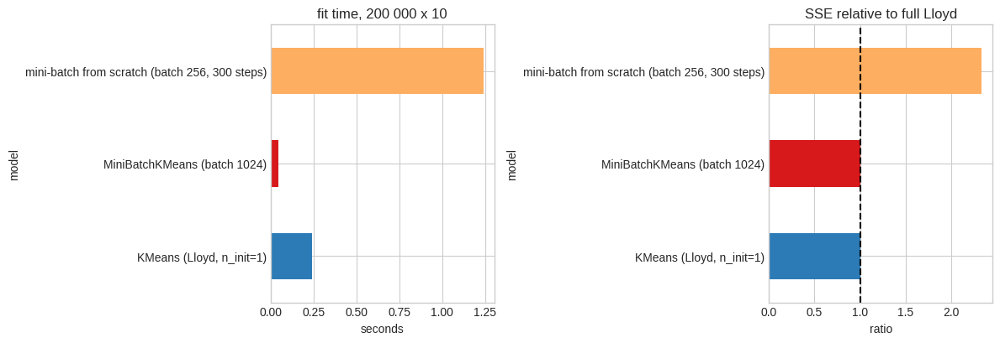

In [28]:
from sklearn.cluster import MiniBatchKMeans

def minibatch_kmeans_scratch(X, K, batch=100, n_iter=200, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    centers = X[rng.choice(len(X), K, replace=False)].copy()
    counts = np.zeros(K)
    for _ in range(n_iter):
        b = X[rng.choice(len(X), batch, replace=False)]
        labels = cdist(b, centers, "sqeuclidean").argmin(axis=1)
        for x, k in zip(b, labels):
            counts[k] += 1
            centers[k] += (x - centers[k]) / counts[k]          # per-centroid learning rate 1/n_k
    labels = cdist(X, centers, "sqeuclidean").argmin(axis=1)
    return labels, centers

# a bigger problem: 200k points, 8 blobs, 10 dimensions
X_big, y_big = make_blobs(n_samples=200_000, centers=8, n_features=10, cluster_std=1.5, random_state=RANDOM_STATE)
results = []
for name, model in [("KMeans (Lloyd, n_init=1)", KMeans(n_clusters=8, n_init=1, random_state=RANDOM_STATE)),
                    ("MiniBatchKMeans (batch 1024)", MiniBatchKMeans(n_clusters=8, batch_size=1024, n_init=1, random_state=RANDOM_STATE))]:
    t0 = time.perf_counter(); model.fit(X_big); t = time.perf_counter() - t0
    results.append({"model": name, "seconds": t, "SSE": model.inertia_, "ARI vs truth": adjusted_rand_score(y_big, model.labels_)})
t0 = time.perf_counter(); lab_mb, cen_mb = minibatch_kmeans_scratch(X_big, 8, batch=256, n_iter=300); t = time.perf_counter() - t0
results.append({"model": "mini-batch from scratch (batch 256, 300 steps)", "seconds": t, "SSE": sse(X_big, lab_mb, cen_mb), "ARI vs truth": adjusted_rand_score(y_big, lab_mb)})
res = pd.DataFrame(results).set_index("model")
res["SSE vs Lloyd"] = res["SSE"] / res["SSE"].iloc[0]
print(res.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
res["seconds"].plot.barh(ax=axes[0], color=["#2c7bb6", "#d7191c", "#fdae61"]); axes[0].set_title("fit time, 200 000 x 10"); axes[0].set_xlabel("seconds")
res["SSE vs Lloyd"].plot.barh(ax=axes[1], color=["#2c7bb6", "#d7191c", "#fdae61"]); axes[1].axvline(1, color="k", ls="--"); axes[1].set_title("SSE relative to full Lloyd"); axes[1].set_xlabel("ratio")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: wall-clock time. The library mini-batch is far faster than full Lloyd on 200 000 rows, and the from-scratch loop (a Python `for` over each point) is honest about what pure Python costs. Right: SSE relative to full Lloyd. The mini-batch answers sit a few percent above 1.0: a little worse, as the theory predicts, while the ARI against the true blobs stays essentially the same.

**The common misread:** expecting mini-batch to *converge* to Lloyd's answer. It converges to a noisy neighbourhood of a local optimum; the noise shrinks as $1/n_k$ but never vanishes. For a final polish, run a few full Lloyd iterations from the mini-batch centroids.

</div>

## 12.3 Task 12 Summary

**✅ Key Takeaways**
- A medoid is a data point; PAM works on any dissimilarity table and gives human-readable representatives, at $O(Kn^2)$ per pass.
- Mini-batch K-means is stochastic gradient descent on SSE with a per-centroid step $1/n_k$; it trades a few percent of SSE for a large speed-up and streaming.
- The library versions (`MiniBatchKMeans`, `sklearn_extra` `KMedoids`) are the ones to use; the scratch versions exist so you know what they do.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `pam(D, K)`, `levenshtein(a, b)` | greedy PAM on a dissimilarity matrix, and the edit distance used for the string example |
| `minibatch_kmeans_scratch(X, K)` | the streaming update with per-centroid learning rates |
| `X_big`, `y_big`, `res` | the 200k-row benchmark and its timing / SSE / ARI table |

**➡️ Next Up:** Task 13 lets a point belong to several clusters at once.


# Task 13 · Fuzzy c-means: Soft Memberships

## 13.1 From a label to a membership vector

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Hard K-means answers "which cluster?" with one index. Fuzzy c-means answers with a vector of memberships $u_{ik} \in [0,1]$ that sum to one across clusters. A point in the middle of a blob gets $(0.98, 0.01, 0.01)$; a point on the boundary between two blobs gets $(0.5, 0.5, 0)$. The **fuzzifier** $m > 1$ controls how soft: $m \to 1$ recovers hard K-means, large $m$ makes every point belong a little to everything.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

Objective: $J_m = \sum_i \sum_k u_{ik}^m\,\lVert x_i - c_k\rVert^2$ subject to $\sum_k u_{ik} = 1$. Setting the Lagrangian's derivatives to zero gives the two alternating updates:

$$c_k = \frac{\sum_i u_{ik}^m\, x_i}{\sum_i u_{ik}^m} \qquad\qquad u_{ik} = \frac{1}{\sum_{j=1}^{K}\left(\dfrac{\lVert x_i - c_k\rVert}{\lVert x_i - c_j\rVert}\right)^{2/(m-1)}}$$

The centroid is a membership-weighted mean; the membership is an inverse-distance share. Each update lowers $J_m$, so the loop converges like Lloyd's.

</div>


converged in 16 iterations | objective 9870 -> 871
memberships sum to 1: True | ARI of argmax vs truth: 1.000
points with max membership < 0.6 (boundary points): 1 of 600


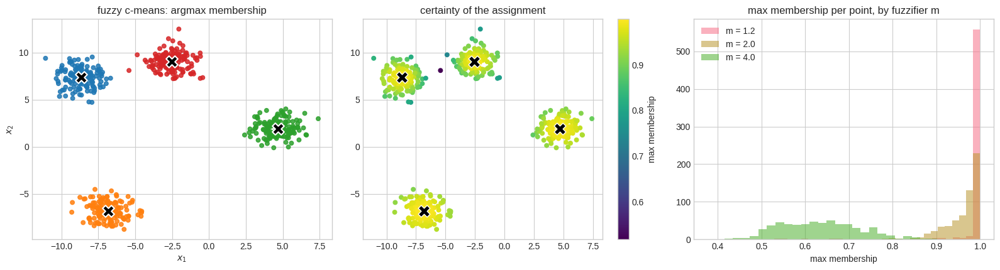

In [29]:
def fuzzy_cmeans(X, K, m=2.0, max_iter=200, tol=1e-6, random_state=RANDOM_STATE):
    """Fuzzy c-means (Bezdek). Returns membership matrix U (n x K), centers, objective history."""
    rng = np.random.default_rng(random_state)
    U = rng.dirichlet(np.ones(K), size=len(X))                       # random memberships, rows sum to 1
    hist = []
    for it in range(max_iter):
        Um = U ** m
        C = (Um.T @ X) / Um.sum(axis=0)[:, None]                      # weighted means
        D = cdist(X, C) + 1e-12
        ratio = (D[:, :, None] / D[:, None, :]) ** (2 / (m - 1))       # (n, K, K): (d_ik / d_ij)^(2/(m-1))
        U_new = 1.0 / ratio.sum(axis=2)                                  # the membership formula, one row per point
        hist.append(float((U_new ** m * D ** 2).sum()))
        if np.abs(U_new - U).max() < tol:
            U = U_new; break
        U = U_new
    return U, C, hist

U, C_f, hist_f = fuzzy_cmeans(X_blobs, K=4, m=2.0)
hard = U.argmax(axis=1)
conf = U.max(axis=1)                                                  # how sure the assignment is
print(f"converged in {len(hist_f)} iterations | objective {hist_f[0]:.0f} -> {hist_f[-1]:.0f}")
print(f"memberships sum to 1: {np.allclose(U.sum(axis=1), 1)} | ARI of argmax vs truth: {adjusted_rand_score(y_blobs, hard):.3f}")
print(f"points with max membership < 0.6 (boundary points): {(conf < 0.6).sum()} of {len(U)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
plot_clusters(X_blobs, hard, C_f, ax=axes[0], title="fuzzy c-means: argmax membership")
sc = axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=conf, cmap="viridis", s=22); plt.colorbar(sc, ax=axes[1], label="max membership")
axes[1].scatter(C_f[:, 0], C_f[:, 1], marker="X", s=180, c="black", edgecolor="white"); axes[1].set_title("certainty of the assignment")
for m_ in [1.2, 2.0, 4.0]:
    U_m, _, _ = fuzzy_cmeans(X_blobs, 4, m=m_)
    axes[2].hist(U_m.max(axis=1), bins=30, alpha=0.55, label=f"m = {m_}")
axes[2].set_title("max membership per point, by fuzzifier m"); axes[2].set_xlabel("max membership"); axes[2].legend()
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: taking the largest membership recovers the same four blobs as hard K-means. Middle: the colour is *how sure* that assignment is; the dark points between blobs are the ones hard K-means silently assigns with no warning. Right: the fuzzifier $m$ at work: at $m = 1.2$ nearly every point is confident (close to hard clustering); at $m = 4$ memberships smear toward $1/K$ and the histogram collapses to the left.

**The common misread:** treating memberships as probabilities. They are inverse-distance shares, not likelihoods: a point far from *every* centroid can still have membership 0.5 in two of them. For probabilities, use the Gaussian mixture in Task 14.

</div>

## 13.2 Task 13 Summary

**✅ Key Takeaways**
- Fuzzy c-means alternates weighted means and inverse-distance memberships; both updates come from one Lagrangian.
- The membership vector exposes boundary points that hard K-means hides; $m$ sets the softness, with $m \to 1$ recovering K-means.
- Memberships are not probabilities; the mixture model is the probabilistic sibling.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `fuzzy_cmeans(X, K, m)` | the two-update loop; returns $U$, centres and the objective history |
| `U`, `C_f`, `hard`, `conf` | memberships on the blobs, the centres, the argmax labels, and the certainty of each point |

**➡️ Next Up:** Task 14 replaces "share of inverse distance" with "posterior probability under a Gaussian": the EM algorithm, of which K-means is the hard-assignment special case.


# Task 14 · Gaussian Mixtures and EM: K-means as a Special Case

## 14.1 The generative story

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Imagine the data was *generated*: pick a cluster $k$ with probability $\pi_k$, then draw a point from a Gaussian $\mathcal N(\mu_k, \Sigma_k)$. Clustering becomes inference: given the points, what were the $\pi_k, \mu_k, \Sigma_k$, and which cluster produced each point? The EM algorithm answers by alternating an **E-step** (compute each point's *responsibility* $r_{ik}$, the posterior probability that cluster $k$ produced it) and an **M-step** (re-estimate the parameters as responsibility-weighted statistics). Freeze every covariance to $\sigma^2 I$ and let $\sigma \to 0$: the responsibilities become 0/1 and EM *is* K-means.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

$$\text{E-step:}\quad r_{ik} = \frac{\pi_k\,\mathcal N(x_i \mid \mu_k, \Sigma_k)}{\sum_j \pi_j\,\mathcal N(x_i \mid \mu_j, \Sigma_j)} \qquad
\text{M-step:}\quad \mu_k = \frac{\sum_i r_{ik} x_i}{\sum_i r_{ik}},\;\; \Sigma_k = \frac{\sum_i r_{ik}(x_i-\mu_k)(x_i-\mu_k)^\top}{\sum_i r_{ik}},\;\; \pi_k = \frac{1}{n}\sum_i r_{ik}$$

With $\Sigma_k = \sigma^2 I$ the responsibility is a softmax of $-\lVert x_i - \mu_k\rVert^2 / 2\sigma^2$; as $\sigma \to 0$ the softmax becomes an argmax and the M-step becomes the plain mean. That is the K-means limit.

</div>


EM from scratch: log-likelihood -3200 -> -2143, monotone: True
ARI vs truth   K-means 0.626 | GMM (scratch) 0.905 | GMM (sklearn) 0.896
mixing weights (scratch): [0.333 0.345 0.322] | sklearn: [0.333 0.325 0.342]


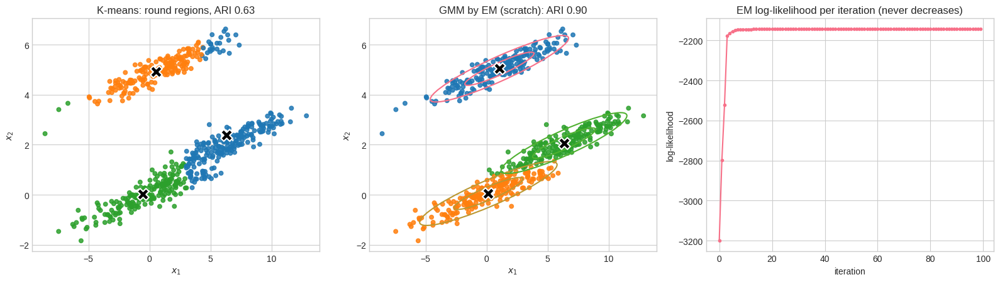

In [30]:
from scipy.stats import multivariate_normal
from sklearn.mixture import GaussianMixture

def gmm_em_scratch(X, K, n_iter=100, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    mu = X[rng.choice(len(X), K, replace=False)].copy()
    Sigma = np.array([np.cov(X.T) for _ in range(K)]); pi = np.full(K, 1 / K)
    ll_hist = []
    for _ in range(n_iter):
        dens = np.column_stack([pi[k] * multivariate_normal(mu[k], Sigma[k]).pdf(X) for k in range(K)])   # (n, K)
        ll_hist.append(float(np.log(dens.sum(axis=1)).sum()))
        R = dens / dens.sum(axis=1, keepdims=True)                                                          # E-step
        Nk = R.sum(axis=0)
        mu = (R.T @ X) / Nk[:, None]                                                                         # M-step
        Sigma = np.array([((R[:, k, None] * (X - mu[k])).T @ (X - mu[k])) / Nk[k] + 1e-6 * np.eye(X.shape[1]) for k in range(K)])
        pi = Nk / len(X)
    return R, mu, Sigma, pi, ll_hist

# stretched, tilted blobs: the case where K-means' round regions are wrong and a full-covariance GMM is right
rng = np.random.default_rng(3)
A = np.array([[2.5, 1.2], [0.4, 0.5]])
X_ell = np.vstack([rng.normal(size=(200, 2)) @ A.T + [0, 0], rng.normal(size=(200, 2)) @ A.T + [1, 5], rng.normal(size=(200, 2)) @ A.T + [6, 2]])
y_ell = np.repeat([0, 1, 2], 200)

R, mu_e, Sig_e, pi_e, ll = gmm_em_scratch(X_ell, 3)
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=RANDOM_STATE).fit(X_ell)
km_e = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_ell)
print(f"EM from scratch: log-likelihood {ll[0]:.0f} -> {ll[-1]:.0f}, monotone: {bool(np.all(np.diff(ll) >= -1e-6))}")
print(f"ARI vs truth   K-means {adjusted_rand_score(y_ell, km_e.labels_):.3f} | GMM (scratch) {adjusted_rand_score(y_ell, R.argmax(1)):.3f} | GMM (sklearn) {adjusted_rand_score(y_ell, gmm.predict(X_ell)):.3f}")
print("mixing weights (scratch):", np.round(pi_e, 3), "| sklearn:", np.round(gmm.weights_, 3))

def draw_ellipse(ax, mean, cov, color):
    vals, vecs = np.linalg.eigh(cov); ang = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
    from matplotlib.patches import Ellipse
    for s in (1, 2):
        ax.add_patch(Ellipse(mean, 2 * s * np.sqrt(vals[1]), 2 * s * np.sqrt(vals[0]), angle=ang, fill=False, color=color, lw=1.5))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
plot_clusters(X_ell, km_e.labels_, km_e.cluster_centers_, ax=axes[0], title=f"K-means: round regions, ARI {adjusted_rand_score(y_ell, km_e.labels_):.2f}")
plot_clusters(X_ell, R.argmax(1), mu_e, ax=axes[1], title=f"GMM by EM (scratch): ARI {adjusted_rand_score(y_ell, R.argmax(1)):.2f}")
for k, col in zip(range(3), ["C0", "C1", "C2"]):
    draw_ellipse(axes[1], mu_e[k], Sig_e[k], col)
axes[2].plot(ll, marker="."); axes[2].set_title("EM log-likelihood per iteration (never decreases)"); axes[2].set_xlabel("iteration"); axes[2].set_ylabel("log-likelihood")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three tilted, elongated clusters. K-means (left) can only draw boundaries halfway between centroids, so it slices the long clusters across their length and mixes them. EM with full covariances (middle) learns the tilt: the ellipses are the 1σ and 2σ contours of each fitted Gaussian, and the ARI is much higher. Right: the log-likelihood climbs monotonically, which is EM's convergence guarantee, the analogue of SSE never increasing in Lloyd's algorithm.

**The common misread:** "GMM is always better than K-means." It has $K(d + d(d+1)/2)$ parameters instead of $Kd$, it needs enough points per cluster to estimate a covariance, it can collapse a component onto one point (a singular covariance; the `+1e-6 I` guards against it), and it is slower. On round, well-separated clusters K-means is the right, cheaper tool.

</div>

## 14.2 The limit: EM with shrinking σ turns into K-means


In [31]:
def em_spherical(X, K, sigma, n_iter=30, init=None):
    """EM with fixed spherical covariance sigma^2 I. Returns responsibilities and means."""
    mu = np.array(init, dtype=float)
    for _ in range(n_iter):
        logits = -cdist(X, mu, "sqeuclidean") / (2 * sigma ** 2)
        logits -= logits.max(axis=1, keepdims=True)
        R = np.exp(logits); R /= R.sum(axis=1, keepdims=True)         # softmax responsibilities
        mu = (R.T @ X) / R.sum(axis=0)[:, None]
    return R, mu

init = X_blobs[np.random.default_rng(1).choice(len(X_blobs), 4, replace=False)]
lab_km, cen_km, _, _ = kmeans_scratch(X_blobs, init=init)
rows = []
for sigma in [3.0, 1.0, 0.5, 0.1, 0.02]:
    R_s, mu_s = em_spherical(X_blobs, 4, sigma, init=init)
    rows.append({"sigma": sigma, "mean max responsibility": R_s.max(axis=1).mean(), "ARI vs K-means": adjusted_rand_score(lab_km, R_s.argmax(1)),
                 "max |mu - K-means centroid|": cdist(mu_s, cen_km).min(axis=1).max()})
print(pd.DataFrame(rows).round(4).to_string(index=False))


 sigma  mean max responsibility  ARI vs K-means  max |mu - K-means centroid|
  3.00                   0.8713          0.7133                       3.1562
  1.00                   0.9995          1.0000                       0.0062
  0.50                   1.0000          1.0000                       0.0004
  0.10                   1.0000          1.0000                       0.0000
  0.02                   1.0000          1.0000                       0.0000


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Takeaway

As σ shrinks the responsibilities harden toward 0/1, the means converge to the K-means centroids from the same start, and the ARI reaches 1. K-means is EM for a spherical Gaussian mixture in the zero-variance limit; that is why it produces round clusters of equal spread, and why a full-covariance mixture is the fix when clusters are not round.

</div>

## 14.3 Task 14 Summary

**✅ Key Takeaways**
- EM alternates responsibilities (E) and weighted parameter estimates (M); the log-likelihood never decreases.
- Full covariances let clusters be elongated and tilted; K-means cannot, because its regions are always halfway between centroids.
- With $\Sigma_k = \sigma^2 I$ and $\sigma \to 0$, EM becomes Lloyd's algorithm exactly; the table shows the limit numerically.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `gmm_em_scratch(X, K)` | EM for a full-covariance mixture; returns $R$, means, covariances, weights and the log-likelihood path |
| `X_ell`, `y_ell`, `gmm`, `km_e` | the tilted-clusters data and the fitted sklearn GMM and K-means |
| `em_spherical(X, K, sigma, init)` | EM with a fixed spherical variance, for the K-means limit |

**➡️ Next Up:** Task 15 fixes the crescent moons without changing the data: K-means in a kernel feature space, and its cousin, spectral clustering.


# Task 15 · Kernel K-means and the Spectral Bridge

## 15.1 Round regions in a space where the moons are round

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

K-means fails on the moons because its regions are convex. Kernel K-means runs the same algorithm in a **feature space** $\phi(x)$ where the moons *are* convex, without ever computing $\phi$: all K-means needs is squared distances, and $\lVert \phi(x) - \phi(c)\rVert^2$ can be written with kernel values $\kappa(x, y) = \phi(x)^\top\phi(y)$ alone. The RBF kernel $\kappa(x,y) = \exp(-\gamma\lVert x - y\rVert^2)$ says "two points are similar if they are close", and a chain of close points along a crescent becomes one connected cluster.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

The centroid of cluster $k$ in feature space is $\bar\phi_k = \frac{1}{n_k}\sum_{j \in C_k}\phi(x_j)$, so

$$\lVert \phi(x_i) - \bar\phi_k\rVert^2 = \kappa(x_i, x_i) - \frac{2}{n_k}\sum_{j\in C_k}\kappa(x_i, x_j) + \frac{1}{n_k^2}\sum_{j, l \in C_k}\kappa(x_j, x_l)$$

Every term is a kernel value: the assignment step needs only the $n \times n$ kernel matrix. There is no explicit update step; the "centroid" lives implicitly in the assignments.

</div>


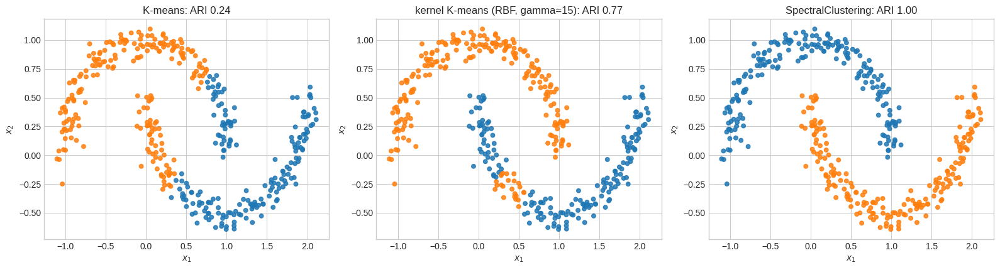

gamma sweep for kernel K-means (best of 10 starts):
  gamma= 0.5: ARI 0.31
  gamma=   2: ARI 0.42
  gamma=  15: ARI 0.77
  gamma=  60: ARI 0.22


In [32]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import SpectralClustering

def kernel_kmeans(Kmat, K, n_iter=50, random_state=RANDOM_STATE):
    """Kernel K-means on a precomputed kernel matrix. Assignments only; centroids are implicit."""
    rng = np.random.default_rng(random_state)
    labels = rng.integers(0, K, len(Kmat))
    diag = np.diag(Kmat)
    for _ in range(n_iter):
        D = np.zeros((len(Kmat), K))
        for k in range(K):
            idx = labels == k
            if idx.sum() == 0:
                D[:, k] = np.inf; continue
            D[:, k] = diag - 2 * Kmat[:, idx].sum(axis=1) / idx.sum() + Kmat[np.ix_(idx, idx)].sum() / idx.sum() ** 2
        new = D.argmin(axis=1)
        if np.array_equal(new, labels):
            break
        labels = new
    return labels

gamma = 15.0
Kmat = rbf_kernel(X_moons, gamma=gamma)
best = None
for seed in range(10):                                                  # kernel K-means is init-sensitive too: keep the best of 10
    lab = kernel_kmeans(Kmat, 2, random_state=seed)
    score = adjusted_rand_score(y_moons, lab)
    if best is None or score > best[0]:
        best = (score, lab)
lab_kk = best[1]
lab_km_moons = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_moons)
lab_sp = SpectralClustering(n_clusters=2, affinity="rbf", gamma=gamma, random_state=RANDOM_STATE).fit_predict(X_moons)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
plot_clusters(X_moons, lab_km_moons, ax=axes[0], title=f"K-means: ARI {adjusted_rand_score(y_moons, lab_km_moons):.2f}")
plot_clusters(X_moons, lab_kk, ax=axes[1], title=f"kernel K-means (RBF, gamma={gamma:g}): ARI {best[0]:.2f}")
plot_clusters(X_moons, lab_sp, ax=axes[2], title=f"SpectralClustering: ARI {adjusted_rand_score(y_moons, lab_sp):.2f}")
plt.tight_layout(); plt.show()
print("gamma sweep for kernel K-means (best of 10 starts):")
for g in [0.5, 2, 15, 60]:
    Kg = rbf_kernel(X_moons, gamma=g)
    print(f"  gamma={g:>4}: ARI {max(adjusted_rand_score(y_moons, kernel_kmeans(Kg, 2, random_state=s)) for s in range(10)):.2f}")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Plain K-means (left) cuts the moons with a straight line and gets about half of each crescent wrong. Kernel K-means (middle) with a well-chosen RBF width follows the crescents. Spectral clustering (right) does the same job by a different route: it builds the same similarity graph, takes the eigenvectors of its Laplacian, and runs ordinary K-means on those; the two methods optimise closely related objectives (Dhillon, Guan and Kulis, 2004, showed the equivalence for weighted kernel K-means and normalised cuts). The gamma sweep is the honest part: too small a width and every point is similar to every other (back to one blob), too large and each point is similar only to itself.

**The common misread:** "kernel K-means solves the shape problem." It moves the problem into choosing $\gamma$ and costs an $n\times n$ kernel matrix. For the crescents you would reach for DBSCAN first (Part 7 compares them); kernel methods earn their place when the data is a similarity matrix to begin with.

</div>

## 15.2 Task 15 Summary

**✅ Key Takeaways**
- Kernel K-means is Lloyd's assignment step written with kernel values only; centroids exist implicitly in feature space.
- With an RBF kernel of the right width, the convex-region limitation disappears; with the wrong width, nothing works.
- Spectral clustering is the eigenvector route to the same graph-cut objective, and its last step is plain K-means.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `kernel_kmeans(Kmat, K)` | kernel K-means on a precomputed kernel matrix |
| `Kmat`, `gamma`, `lab_kk`, `lab_sp` | the RBF kernel on the moons, its width, and the kernel / spectral labels |

**➡️ Next Up:** Part 6 answers the question every clustering must face: is it any good? Internal and external validity, the SSE + SSB = TSS identity, similarity-matrix pictures, random-data baselines, and choosing K.


# Part 6 · Metrics and Cluster Validity ⭐⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

K-means always returns K clusters, even on uniform noise. So "is this clustering any good?" needs its own machinery. The textbook organises it in three questions: **is there structure at all** (clustering tendency), **how good is a clustering without labels** (unsupervised / internal validity: cohesion, separation, silhouette, the similarity matrix), and **how well does it match known classes** (supervised / external validity: entropy, purity, Rand, NMI). The last Task turns internal validity into the decision everyone actually needs: **how many clusters?**

</div>


# Task 16 · Internal Metrics: Cohesion, Separation, and SSE + SSB = TSS

## 16.1 Cohesion and separation

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Two things make a clustering look right: points in a cluster are close to each other (**cohesion**) and clusters are far from each other (**separation**). For prototype-based clustering, cohesion of cluster $k$ is its SSE, and separation is how far its centroid sits from the overall mean, weighted by its size (**SSB**, between-group sum of squares). The surprise is that they are not independent: cohesion plus separation is a constant of the data. Lowering SSE *is* raising SSB.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

With overall mean $c$ and cluster centroids $c_k$ of sizes $m_k$:

$$\underbrace{\sum_i \lVert x_i - c\rVert^2}_{\text{TSS}} \;=\; \underbrace{\sum_k \sum_{i \in C_k}\lVert x_i - c_k\rVert^2}_{\text{SSE (cohesion)}} \;+\; \underbrace{\sum_k m_k\,\lVert c_k - c\rVert^2}_{\text{SSB (separation)}}$$

The cross term vanishes because $\sum_{i\in C_k}(x_i - c_k) = 0$ (the centroid is the mean). TSS depends only on the data, so every partition splits the same total between the two.

</div>


       SSE      SSB  SSE + SSB     TSS  SSB / TSS
K                                                
1  2314.00     0.00     2314.0  2314.0       0.00
2  1658.76   655.24     2314.0  2314.0       0.28
3  1277.93  1036.07     2314.0  2314.0       0.45
4  1175.43  1138.57     2314.0  2314.0       0.49
6  1046.00  1268.00     2314.0  2314.0       0.55
8   935.20  1378.80     2314.0  2314.0       0.60

SSE + SSB equals TSS at every K: True


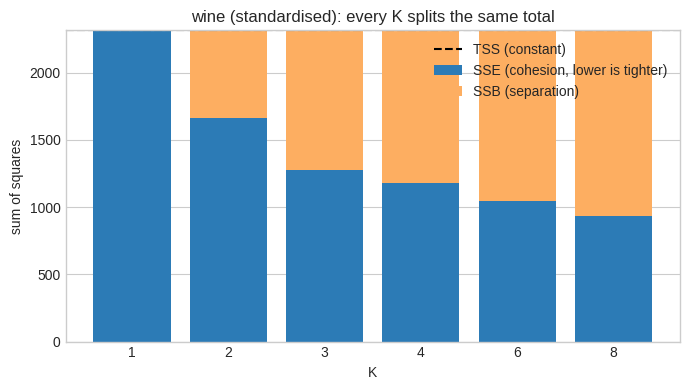

In [33]:
def tss(X):
    return float(((X - X.mean(axis=0)) ** 2).sum())

def ssb(X, labels, centers):
    c = X.mean(axis=0)
    return float(sum((labels == k).sum() * ((centers[k] - c) ** 2).sum() for k in range(len(centers))))

X_std_wine = StandardScaler().fit_transform(X_wine)
rows = []
for K in [1, 2, 3, 4, 6, 8]:
    km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X_std_wine)
    rows.append({"K": K, "SSE": km.inertia_, "SSB": ssb(X_std_wine, km.labels_, km.cluster_centers_)})
id_tab = pd.DataFrame(rows).set_index("K")
id_tab["SSE + SSB"] = id_tab.SSE + id_tab.SSB
id_tab["TSS"] = tss(X_std_wine)
id_tab["SSB / TSS"] = id_tab.SSB / id_tab.TSS
print(id_tab.round(2).to_string())
print(f"\nSSE + SSB equals TSS at every K: {np.allclose(id_tab['SSE + SSB'], id_tab['TSS'])}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(id_tab.index.astype(str), id_tab.SSE, label="SSE (cohesion, lower is tighter)", color="#2c7bb6")
ax.bar(id_tab.index.astype(str), id_tab.SSB, bottom=id_tab.SSE, label="SSB (separation)", color="#fdae61")
ax.axhline(tss(X_std_wine), color="k", ls="--", label="TSS (constant)"); ax.set_xlabel("K"); ax.set_ylabel("sum of squares"); ax.legend()
ax.set_title("wine (standardised): every K splits the same total")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Every bar reaches the same dashed line: SSE plus SSB is the total sum of squares no matter how many clusters. As K grows the blue part (SSE) shrinks and the orange part (SSB) grows; at $K = n$ SSE would be zero. The ratio SSB / TSS is the "fraction of variance explained" by the clustering and it always rises with K, which is why it cannot pick K on its own.

**The common misread:** using SSE to compare clusterings with *different* K. SSE only falls with K; it compares clusterings at the *same* K (different inits, different algorithms). Task 20 shows the metrics that do compare across K.

</div>

## 16.2 Silhouette, Calinski–Harabasz, Davies–Bouldin

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

The **silhouette** of a point compares its mean distance to its own cluster ($a$) with its mean distance to the nearest other cluster ($b$): $s = (b - a)/\max(a, b)$. Near 1: well placed; near 0: on a boundary; negative: probably in the wrong cluster. It works per point, so it doubles as a diagnostic. **Calinski–Harabasz** is the ratio of separation to cohesion, each divided by its degrees of freedom: $\frac{\text{SSB}/(K-1)}{\text{SSE}/(n-K)}$; higher is better. **Davies–Bouldin** averages, over clusters, the worst ratio of within-spread to between-distance; lower is better. All three are label-free.

</div>


silhouette by hand vs sklearn: max |diff| = 8.33e-16, mean = 0.285
Calinski-Harabasz 70.9 | Davies-Bouldin 1.389


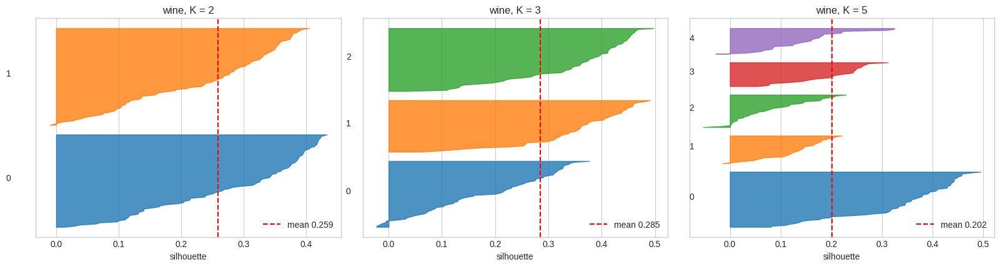

In [34]:
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score

def silhouette_by_hand(X, labels):
    D = cdist(X, X)
    s = np.zeros(len(X))
    for i in range(len(X)):
        own = labels == labels[i]; own[i] = False
        a = D[i, own].mean() if own.any() else 0.0
        b = min(D[i, labels == k].mean() for k in np.unique(labels) if k != labels[i])
        s[i] = (b - a) / max(a, b)
    return s

km3 = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_std_wine)
s_hand = silhouette_by_hand(X_std_wine, km3.labels_)
s_lib = silhouette_samples(X_std_wine, km3.labels_)
print(f"silhouette by hand vs sklearn: max |diff| = {np.abs(s_hand - s_lib).max():.2e}, mean = {s_hand.mean():.3f}")
print(f"Calinski-Harabasz {calinski_harabasz_score(X_std_wine, km3.labels_):.1f} | Davies-Bouldin {davies_bouldin_score(X_std_wine, km3.labels_):.3f}")

def silhouette_plot(X, labels, ax, title=""):
    s = silhouette_samples(X, labels); y0 = 0
    for k in np.unique(labels):
        sk = np.sort(s[labels == k])
        ax.fill_betweenx(np.arange(y0, y0 + len(sk)), 0, sk, color=plt.cm.tab10(k), alpha=0.8)
        ax.text(-0.08, y0 + len(sk) / 2, str(k)); y0 += len(sk) + 8
    ax.axvline(s.mean(), color="red", ls="--", label=f"mean {s.mean():.3f}"); ax.set_xlabel("silhouette"); ax.set_yticks([]); ax.set_title(title); ax.legend(loc="lower right")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, K in zip(axes, [2, 3, 5]):
    lab = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit_predict(X_std_wine)
    silhouette_plot(X_std_wine, lab, ax, title=f"wine, K = {K}")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three silhouette plots for the standardised wine data. Each cluster is a stack of horizontal bars, one per point, sorted by silhouette; the red dashed line is the mean. A good clustering has every cluster's bars reaching past the mean and few negative bars. At $K = 3$ (the true number of cultivars) the three stacks are similar in size and shape; at $K = 2$ one stack is fat with a long tail of weak points, and at $K = 5$ two of the stacks are thin and short: clusters the data does not support.

**The common misread:** reading only the mean silhouette. Two clusterings can share a mean while one has a cluster made entirely of negative bars; the plot exists to show the shape, and negative bars are the points Part 9 will inspect.

</div>

## 16.3 Task 16 Summary

**✅ Key Takeaways**
- SSE (cohesion) + SSB (separation) = TSS for every partition; the split shifts toward SSB as K grows, so SSE cannot pick K.
- Silhouette is per point and diagnoses boundary and misplaced points; CH and DB are cluster-level ratios of separation to cohesion.
- The by-hand silhouette matches `silhouette_samples` to floating-point precision; the plot's shape matters more than its mean.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `tss(X)`, `ssb(X, labels, centers)`, `id_tab` | the identity's three terms and the table proving it at several K |
| `X_std_wine`, `km3` | standardised wine data and a 3-cluster fit |
| `silhouette_by_hand`, `silhouette_plot` | the per-point silhouette and the stacked-bar plot |

**➡️ Next Up:** Task 17 draws the whole clustering as one picture: the similarity matrix, ordered by cluster.


# Task 17 · The Similarity Matrix and the Incidence Correlation

## 17.1 If the clusters are real, the ordered similarity matrix is block-diagonal

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Sort the points by cluster label and draw the $n \times n$ matrix of pairwise similarities. Real clusters show up as bright blocks on the diagonal (within-cluster pairs are similar) against a dark background (between-cluster pairs are not). Random data shows no blocks no matter how it is sorted. A number for the same idea: build the **incidence matrix** (1 if two points share a cluster, else 0) and correlate it with the similarity matrix; high correlation means the clustering explains the similarities.

</div>


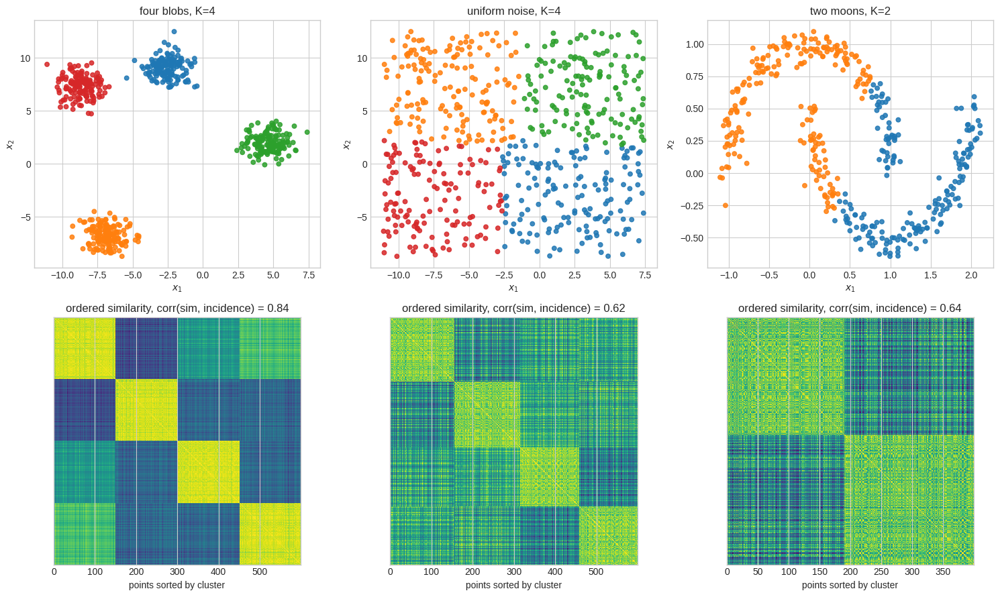

In [35]:
def ordered_similarity(X, labels):
    order = np.argsort(labels, kind="stable")
    D = cdist(X[order], X[order])
    return 1 - D / D.max(), order                      # similarity in [0, 1]

def incidence_correlation(X, labels):
    D = cdist(X, X); S = 1 - D / D.max()
    inc = (labels[:, None] == labels[None, :]).astype(float)
    iu = np.triu_indices(len(X), 1)                     # upper triangle only: no self-pairs, no double counting
    return float(np.corrcoef(S[iu], inc[iu])[0, 1])

rng = np.random.default_rng(RANDOM_STATE)
X_rand = rng.uniform(X_blobs.min(axis=0), X_blobs.max(axis=0), size=X_blobs.shape)     # uniform noise in the same box
lab_blobs = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit_predict(X_blobs)
lab_rand = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit_predict(X_rand)
lab_moons = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_moons)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for j, (X, lab, name) in enumerate([(X_blobs, lab_blobs, "four blobs, K=4"), (X_rand, lab_rand, "uniform noise, K=4"), (X_moons, lab_moons, "two moons, K=2")]):
    plot_clusters(X, lab, ax=axes[0, j], title=name)
    S, order = ordered_similarity(X, lab)
    axes[1, j].imshow(S, cmap="viridis", interpolation="nearest"); axes[1, j].set_title(f"ordered similarity, corr(sim, incidence) = {incidence_correlation(X, lab):.2f}")
    axes[1, j].set_xlabel("points sorted by cluster"); axes[1, j].set_yticks([])
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Top row: three datasets with K-means labels. Bottom row: their ordered similarity matrices. The blobs give four crisp bright squares on the diagonal and a high similarity–incidence correlation. The uniform noise, forced into four "clusters", still shows faint blocks, because sorting by any K-means labelling groups nearby points together; the correlation is lower but not zero, which is the warning. The moons show two blocks with heavy bleeding between them: the crescents are not compact.

**The common misread:** treating faint blocks as proof of structure. K-means on noise *always* produces some blocks, because it partitions space. The next Task builds the baseline that says how strong the blocks would be if there were no clusters at all.

</div>

## 17.2 Task 17 Summary

**✅ Key Takeaways**
- Sorting the similarity matrix by cluster label turns real clusters into diagonal blocks; the picture is the fastest sanity check there is.
- The similarity–incidence correlation is the same check as a number.
- Random data also produces weak blocks under K-means, so the check needs a random baseline.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `ordered_similarity(X, labels)`, `incidence_correlation(X, labels)` | the picture and its number |
| `X_rand`, `lab_rand` | uniform noise in the blobs' bounding box, and its forced 4-cluster labels |

**➡️ Next Up:** Task 18 grades a clustering against known classes: the supervised measures.


# Task 18 · External Metrics: When the Classes Are Known

## 18.1 The cluster-versus-class table

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

When each object also has a class label, every external measure starts from one table: rows are clusters, columns are classes, cells are counts. **Purity** asks "what fraction of each cluster is its majority class?" **Entropy** asks "how mixed is each cluster?" **Precision, recall and F** treat cluster $i$ as a retrieval of class $j$. The **pair-counting** family (Rand, Jaccard, adjusted Rand) asks, for every pair of objects, whether the clustering and the classes agree about being together. The **information-theoretic** family (NMI, AMI, homogeneity, completeness, V-measure) measures how much knowing the cluster tells you about the class.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

With $m_{ij}$ objects of class $j$ in cluster $i$, $m_i = \sum_j m_{ij}$, $p_{ij} = m_{ij}/m_i$:

$$e_i = -\sum_j p_{ij}\log_2 p_{ij}, \quad e = \sum_i \frac{m_i}{m} e_i \qquad\qquad \text{purity}_i = \max_j p_{ij}, \quad \text{purity} = \sum_i \frac{m_i}{m}\,\text{purity}_i$$

$$\text{precision}(i,j) = p_{ij}, \qquad \text{recall}(i,j) = \frac{m_{ij}}{m_j}, \qquad F(i,j) = \frac{2\,\text{prec}\cdot\text{rec}}{\text{prec} + \text{rec}}$$

Pair counting: with $f_{11}$ pairs together in both, $f_{00}$ apart in both, $f_{10}$ and $f_{01}$ the disagreements, $\text{Rand} = \frac{f_{00} + f_{11}}{\text{all pairs}}$ and $\text{Jaccard} = \frac{f_{11}}{f_{11} + f_{10} + f_{01}}$. Adjusted Rand subtracts what a random clustering would score.

</div>


In [36]:
from sklearn.metrics import (adjusted_rand_score, rand_score, normalized_mutual_info_score, adjusted_mutual_info_score,
                             homogeneity_score, completeness_score, v_measure_score, fowlkes_mallows_score)

def cluster_class_table(labels, classes):
    return pd.crosstab(pd.Series(labels, name="cluster"), pd.Series(classes, name="class"))

def external_by_hand(labels, classes):
    M = cluster_class_table(labels, classes).to_numpy().astype(float)
    m = M.sum(); mi = M.sum(axis=1); mj = M.sum(axis=0)
    P = M / mi[:, None]
    ent = float(sum(mi[i] / m * -np.nansum(np.where(P[i] > 0, P[i] * np.log2(P[i]), 0)) for i in range(len(mi))))
    purity = float((M.max(axis=1)).sum() / m)
    prec = P; rec = M / mj[None, :]
    F = np.where(prec + rec > 0, 2 * prec * rec / (prec + rec + 1e-12), 0)
    F_overall = float(sum(mj[j] / m * F[:, j].max() for j in range(len(mj))))     # for each class, the best cluster's F
    # pair counting from the table: f11 = pairs together in both
    comb = lambda x: x * (x - 1) / 2
    f11 = comb(M).sum(); same_cluster = comb(mi).sum(); same_class = comb(mj).sum(); total = comb(m)
    f10 = same_cluster - f11; f01 = same_class - f11; f00 = total - f11 - f10 - f01
    rand = (f00 + f11) / total; jacc = f11 / (f11 + f10 + f01)
    expected = same_cluster * same_class / total
    ari = (f11 - expected) / (0.5 * (same_cluster + same_class) - expected)
    return dict(entropy=ent, purity=purity, F=F_overall, rand=float(rand), jaccard=float(jacc), ARI=float(ari)), F

lab_iris = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit_predict(StandardScaler().fit_transform(X_iris))
tab = cluster_class_table(lab_iris, y_iris)
print("cluster x class table (iris, standardised, K=3):"); print(tab.to_string())
hand, F = external_by_hand(lab_iris, y_iris)
lib = dict(rand=rand_score(y_iris, lab_iris), ARI=adjusted_rand_score(y_iris, lab_iris), NMI=normalized_mutual_info_score(y_iris, lab_iris),
           AMI=adjusted_mutual_info_score(y_iris, lab_iris), homogeneity=homogeneity_score(y_iris, lab_iris),
           completeness=completeness_score(y_iris, lab_iris), V=v_measure_score(y_iris, lab_iris), FMI=fowlkes_mallows_score(y_iris, lab_iris))
print("\nby hand :", {k: round(v, 3) for k, v in hand.items()})
print("sklearn :", {k: round(v, 3) for k, v in lib.items()})
print(f"agreement on Rand {abs(hand['rand'] - lib['rand']):.1e}, on ARI {abs(hand['ARI'] - lib['ARI']):.1e}")


cluster x class table (iris, standardised, K=3):
class     0   1   2
cluster            
0         0  39  14
1        50   0   0
2         0  11  36

by hand : {'entropy': 0.54, 'purity': 0.833, 'F': 0.833, 'rand': 0.832, 'jaccard': 0.594, 'ARI': 0.62}
sklearn : {'rand': np.float64(0.832), 'ARI': 0.62, 'NMI': np.float64(0.659), 'AMI': np.float64(0.655), 'homogeneity': np.float64(0.659), 'completeness': np.float64(0.66), 'V': np.float64(0.659), 'FMI': np.float64(0.745)}
agreement on Rand 0.0e+00, on ARI 0.0e+00


## 18.2 Which external metric lies, and when


In [37]:
# three clusterings of the same 300 objects (3 classes of 100) that expose the metrics' blind spots
rng = np.random.default_rng(RANDOM_STATE)
truth = np.repeat([0, 1, 2], 100)
perfect = truth.copy()
each_alone = np.arange(300)                                   # every object its own cluster: purity 1, useless
one_blob = np.zeros(300, dtype=int)                           # everything in one cluster: completeness 1, useless
random_lab = rng.integers(0, 3, 300)                          # random labels: Rand still looks decent
swapped = truth.copy(); swapped[truth == 1] = 2; swapped[truth == 2] = 1   # same partition, permuted names

rows = []
for name, lab in [("perfect", perfect), ("permuted names", swapped), ("each object alone (K=300)", each_alone), ("one cluster (K=1)", one_blob), ("random (K=3)", random_lab)]:
    h, _ = external_by_hand(lab, truth)
    rows.append({"clustering": name, "purity": h["purity"], "entropy": h["entropy"], "Rand": rand_score(truth, lab), "ARI": adjusted_rand_score(truth, lab),
                 "NMI": normalized_mutual_info_score(truth, lab), "AMI": adjusted_mutual_info_score(truth, lab),
                 "homogeneity": homogeneity_score(truth, lab), "completeness": completeness_score(truth, lab)})
ext = pd.DataFrame(rows).set_index("clustering")
print(ext.round(3).to_string())


                           purity  entropy   Rand  ARI    NMI  AMI  homogeneity  completeness
clustering                                                                                   
perfect                     1.000    0.000  1.000  1.0  1.000  1.0        1.000         1.000
permuted names              1.000    0.000  1.000  1.0  1.000  1.0        1.000         1.000
each object alone (K=300)   1.000    0.000  0.669  0.0  0.323  0.0        1.000         0.193
one cluster (K=1)           0.333    1.585  0.331  0.0  0.000  0.0        0.000         1.000
random (K=3)                0.380    1.575  0.557 -0.0  0.006 -0.0        0.006         0.006


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Five clusterings of the same three classes. Every metric is invariant to renaming clusters (row 2 equals row 1), as it must be. Then the traps: **purity** and **homogeneity** hit 1.0 when every object is alone; **completeness** hits 1.0 when everything is one cluster; **Rand** gives random labels a score above 0.5 because most pairs are "apart in both"; and **NMI** rewards the each-alone clustering more than it should. The *adjusted* measures (ARI, AMI) are the ones that sit at 0 for random labels and punish both degenerate cases.

**The common misread:** reporting purity alone. Purity rewards more clusters unconditionally; pair it with entropy or, better, report ARI and AMI, which are chance-corrected.

</div>

## 18.3 Task 18 Summary

**✅ Key Takeaways**
- Every external measure comes from the cluster × class table; entropy, purity, precision/recall/F, Rand, Jaccard and ARI were computed from it by hand and match sklearn.
- Purity and homogeneity reward over-splitting; completeness rewards under-splitting; plain Rand is inflated by "apart in both" pairs.
- ARI and AMI are chance-corrected: 0 for random labels, 1 for perfect, and invariant to renaming; report those.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `cluster_class_table`, `external_by_hand` | the contingency table and every textbook measure computed from it |
| `lab_iris`, `tab`, `ext` | the iris clustering, its table, and the five-clustering comparison |

**➡️ Next Up:** Task 19 asks the question that must come first: is there any structure to find?


# Task 19 · The Statistical Framework: Is There Structure at All?

## 19.1 Clustering tendency: the Hopkins statistic

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Before clustering, ask whether the data is clustered at all. The **Hopkins statistic** compares two kinds of nearest-neighbour distances: from random points sprinkled in the data's bounding box to their nearest real point ($u_i$), and from real points to their nearest other real point ($w_i$). If the data is uniform, the two are alike and $H = \frac{\sum u}{\sum u + \sum w} \approx 0.5$. If the data is clustered, real points have close neighbours ($w$ small) while random points land in empty space ($u$ large), and $H \to 1$.

</div>


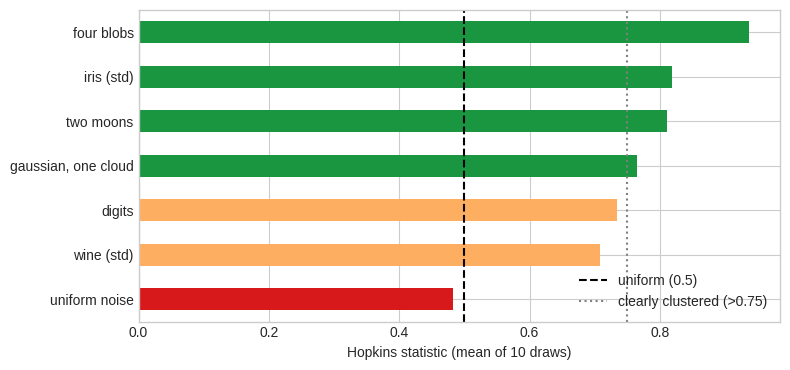

four blobs             0.937
two moons              0.811
uniform noise          0.483
iris (std)             0.819
wine (std)             0.708
digits                 0.734
gaussian, one cloud    0.766


In [38]:
from sklearn.neighbors import NearestNeighbors

def hopkins(X, n_samples=None, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    n = len(X); s = n_samples or min(100, n // 5)
    nn = NearestNeighbors(n_neighbors=2).fit(X)
    real = X[rng.choice(n, s, replace=False)]
    w = nn.kneighbors(real, n_neighbors=2)[0][:, 1]                                  # nearest OTHER real point
    uniform = rng.uniform(X.min(axis=0), X.max(axis=0), size=(s, X.shape[1]))
    u = nn.kneighbors(uniform, n_neighbors=1)[0][:, 0]
    return float(u.sum() / (u.sum() + w.sum()))

datasets = {"four blobs": X_blobs, "two moons": X_moons, "uniform noise": X_rand, "iris (std)": StandardScaler().fit_transform(X_iris),
            "wine (std)": X_std_wine, "digits": X_digits, "gaussian, one cloud": rng.normal(size=(600, 2))}
h = pd.Series({name: np.mean([hopkins(X, random_state=s) for s in range(10)]) for name, X in datasets.items()})
fig, ax = plt.subplots(figsize=(8, 3.8))
h.sort_values().plot.barh(ax=ax, color=["#d7191c" if v < 0.6 else "#fdae61" if v < 0.75 else "#1a9641" for v in h.sort_values()])
ax.axvline(0.5, color="k", ls="--", label="uniform (0.5)"); ax.axvline(0.75, color="gray", ls=":", label="clearly clustered (>0.75)"); ax.set_xlabel("Hopkins statistic (mean of 10 draws)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
print(h.round(3).to_string())


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Uniform noise sits at 0.5, as the theory says. The blobs, the moons and the digits are far above 0.75: strongly clustered. A single Gaussian cloud scores well above 0.5 too, which is the honest caveat: Hopkins detects *non-uniformity* (density variation), not clusters as such; one dense cloud is non-uniform. Iris and wine fall in between: real but overlapping structure.

**The common misread:** "H = 0.8, so there are clusters." H says the data is not uniform. Combine it with the random-data baseline below, and with the similarity-matrix picture, before believing a partition.

</div>

## 19.2 The random-data baseline: how good would SSE be if there were no clusters?

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

The textbook's framework for judging a validity index: generate many datasets with *no* structure (uniform in the same box), cluster each the same way, and look at the distribution of the index. If the real data's index is far outside that distribution, the structure is real. It is a permutation-style hypothesis test with SSE (or silhouette) as the statistic.

</div>


four blobs: real silhouette 0.809 vs random 0.405 ± 0.011  ->  z = 37.8, fraction of random runs at least as good: 0.00
two moons: real silhouette 0.487 vs random 0.475 ± 0.013  ->  z = 0.9, fraction of random runs at least as good: 0.17


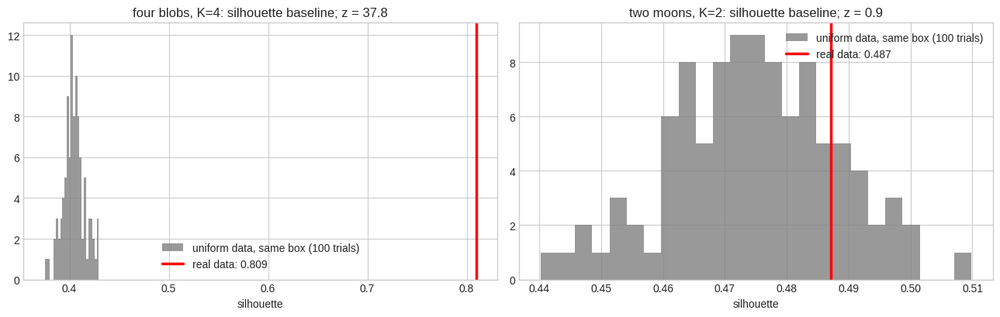

In [39]:
def random_baseline(X, K, n_trials=100, metric="sse", random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    vals = []
    for _ in range(n_trials):
        Xr = rng.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
        km = KMeans(n_clusters=K, n_init=3, random_state=random_state).fit(Xr)
        vals.append(km.inertia_ if metric == "sse" else silhouette_score(Xr, km.labels_))
    return np.array(vals)

km_b = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE).fit(X_blobs)
km_m = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_moons)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (X, km, K, name) in zip(axes, [(X_blobs, km_b, 4, "four blobs"), (X_moons, km_m, 2, "two moons")]):
    base = random_baseline(X, K, metric="silhouette")
    real = silhouette_score(X, km.labels_)
    ax.hist(base, bins=25, color="gray", alpha=0.8, label="uniform data, same box (100 trials)")
    ax.axvline(real, color="red", lw=2.5, label=f"real data: {real:.3f}")
    z = (real - base.mean()) / base.std()
    ax.set_title(f"{name}, K={K}: silhouette baseline; z = {z:.1f}"); ax.set_xlabel("silhouette"); ax.legend()
    print(f"{name}: real silhouette {real:.3f} vs random {base.mean():.3f} ± {base.std():.3f}  ->  z = {z:.1f}, fraction of random runs at least as good: {(base >= real).mean():.2f}")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Grey: the silhouette that K-means achieves on 100 datasets with no structure. Red: the real data. The blobs sit many standard deviations to the right of anything noise can produce. The moons are the instructive case: their K-means silhouette is only modestly above the noise distribution, because K-means' two halves of the crescents are not compact clusters. A value that is *possible on noise* is not evidence.

**The common misread:** comparing a silhouette to a fixed rule of thumb ("above 0.5 is good"). The right comparison is to the same statistic on structureless data of the same size, shape and dimension; in high dimensions the noise baseline shifts.

</div>

## 19.3 Task 19 Summary

**✅ Key Takeaways**
- Hopkins ≈ 0.5 means uniform; well above 0.75 means non-uniform, which includes one dense cloud, so it is a screen, not a verdict.
- The random-data baseline turns any validity index into a hypothesis test: real structure sits far outside the noise distribution.
- K-means on the moons is "better than noise" only modestly: the index is honest about a wrong model.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `hopkins(X)` | the clustering-tendency statistic |
| `random_baseline(X, K, metric)` | the distribution of SSE or silhouette on uniform data in the same box |

**➡️ Next Up:** Task 20 uses the internal metrics for the decision everyone needs: choosing K.


# Task 20 · Choosing K: Elbow, Silhouette, Gap Statistic, Stability

## 20.1 Four answers to one question

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

- **Elbow**: plot SSE against K; the "knee" is where adding a cluster stops paying. Cheap, and often ambiguous.
- **Silhouette / CH / DB**: score each K by a cohesion–separation ratio; pick the best. These *can* compare across K because they normalise for it.
- **Gap statistic** (Tibshirani, Walther and Hastie, 2001): compare $\log \text{SSE}_K$ with its expectation on uniform data; pick the smallest K whose gap is within one standard error of the next. It is Task 19's baseline turned into a rule.
- **Stability**: cluster two random halves of the data and check whether the partitions agree (ARI); the right K is one the data reproduces.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

$$\text{Gap}(K) = \mathbb{E}^*\big[\log \text{SSE}^*_K\big] - \log \text{SSE}_K, \qquad s_K = \text{sd}^*\big(\log \text{SSE}^*_K\big)\sqrt{1 + 1/B}$$

with $B$ uniform reference datasets. Choose the smallest $K$ such that $\text{Gap}(K) \ge \text{Gap}(K+1) - s_{K+1}$.

</div>


          SSE  silhouette        CH     DB    gap    s_k  stability (ARI)
K                                                                        
1   39531.819         NaN       NaN    NaN  0.001  0.027              NaN
2   18438.516       0.597   684.100  0.515  0.204  0.042            1.000
3    3977.880       0.768  2667.967  0.343  1.318  0.034            1.000
4     941.899       0.809  8139.440  0.269  2.339  0.032            1.000
5     849.057       0.707  6777.000  0.578  2.247  0.032            0.827
6     763.036       0.571  6036.845  0.830  2.156  0.026            0.706
7     684.773       0.464  5606.796  1.003  2.117  0.027            0.545
8     608.488       0.338  5410.471  1.168  2.076  0.033            0.608
9     553.556       0.339  5201.853  1.066  2.040  0.036            0.593
10    497.811       0.354  5141.061  0.982  2.042  0.035            0.687

gap rule picks K = 4 | silhouette picks K = 4 | CH picks 4 | DB picks 4 | stability picks 2


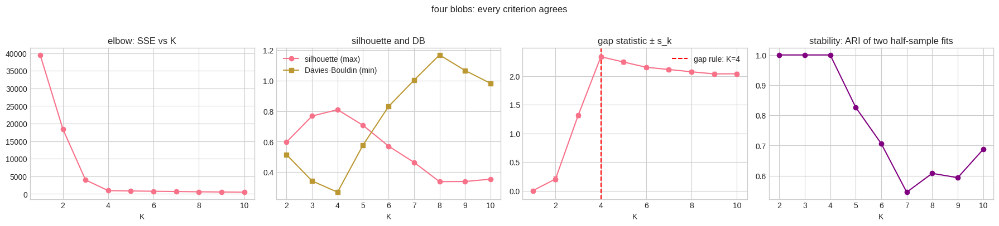

In [40]:
def choose_k_table(X, Ks, B=20, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    rows = []
    ref_logs = {K: [] for K in Ks}
    for b in range(B):
        Xr = rng.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
        for K in Ks:
            ref_logs[K].append(np.log(KMeans(n_clusters=K, n_init=2, random_state=random_state).fit(Xr).inertia_))
    for K in Ks:
        km = KMeans(n_clusters=K, n_init=10, random_state=random_state).fit(X)
        row = {"K": K, "SSE": km.inertia_, "silhouette": silhouette_score(X, km.labels_) if K > 1 else np.nan,
               "CH": calinski_harabasz_score(X, km.labels_) if K > 1 else np.nan, "DB": davies_bouldin_score(X, km.labels_) if K > 1 else np.nan,
               "gap": np.mean(ref_logs[K]) - np.log(km.inertia_), "s_k": np.std(ref_logs[K]) * np.sqrt(1 + 1 / B)}
        # stability: ARI between clusterings of two random halves, evaluated on the overlap via predict
        idx = rng.permutation(len(X)); a, b_ = idx[: len(X) // 2], idx[len(X) // 2 :]
        ka = KMeans(n_clusters=K, n_init=5, random_state=random_state).fit(X[a]); kb = KMeans(n_clusters=K, n_init=5, random_state=random_state + 1).fit(X[b_])
        row["stability (ARI)"] = adjusted_rand_score(ka.predict(X), kb.predict(X)) if K > 1 else np.nan
        rows.append(row)
    t = pd.DataFrame(rows).set_index("K")
    gap_ok = [k for k in Ks[:-1] if t.loc[k, "gap"] >= t.loc[k + 1, "gap"] - t.loc[k + 1, "s_k"]]
    t.attrs["gap_choice"] = gap_ok[0] if gap_ok else Ks[-1]
    return t

Ks = list(range(1, 11))
t_blobs = choose_k_table(X_blobs, Ks)
print(t_blobs.round(3).to_string())
print(f"\ngap rule picks K = {t_blobs.attrs['gap_choice']} | silhouette picks K = {t_blobs.silhouette.idxmax()} | CH picks {t_blobs.CH.idxmax()} | DB picks {t_blobs.DB.idxmin()} | stability picks {t_blobs['stability (ARI)'].idxmax()}")

def plot_choose_k(t, title):
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.9))
    axes[0].plot(t.index, t.SSE, marker="o"); axes[0].set_title("elbow: SSE vs K"); axes[0].set_xlabel("K")
    axes[1].plot(t.index, t.silhouette, marker="o", label="silhouette (max)"); axes[1].plot(t.index, t.DB, marker="s", label="Davies-Bouldin (min)"); axes[1].legend(); axes[1].set_title("silhouette and DB"); axes[1].set_xlabel("K")
    axes[2].errorbar(t.index, t.gap, yerr=t.s_k, marker="o", capsize=3); axes[2].axvline(t.attrs["gap_choice"], color="red", ls="--", label=f"gap rule: K={t.attrs['gap_choice']}"); axes[2].legend(); axes[2].set_title("gap statistic ± s_k"); axes[2].set_xlabel("K")
    axes[3].plot(t.index, t["stability (ARI)"], marker="o", color="purple"); axes[3].set_title("stability: ARI of two half-sample fits"); axes[3].set_xlabel("K")
    fig.suptitle(title, y=1.03); plt.tight_layout(); plt.show()

plot_choose_k(t_blobs, "four blobs: every criterion agrees")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

On clean blobs all four criteria point at K = 4: a sharp elbow, a silhouette peak, a Davies–Bouldin minimum, the gap rule's first qualifying K, and a stability that is essentially 1 at K = 4 and drops beyond it (extra clusters split blobs arbitrarily, so two half-samples disagree about where). Easy data gives unanimous answers.

**The common misread:** expecting unanimity on real data. The next cell shows the usual case.

</div>


wine (std): gap picks 4 | silhouette picks 3 | CH picks 3 | DB picks 3 | stability picks 4  (true cultivars: 3)


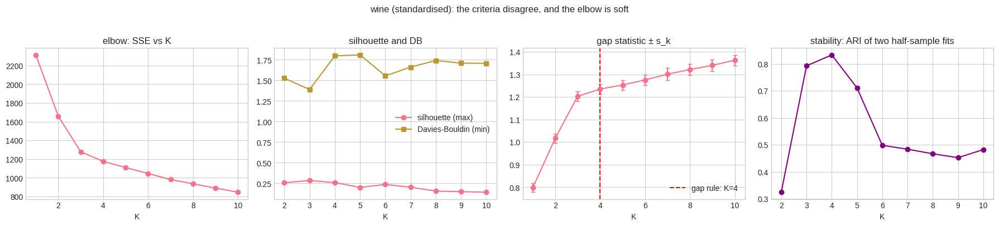

iris (std): gap picks 3 | silhouette picks 2 | CH picks 2 | DB picks 2 | stability picks 2  (true species: 3)


In [41]:
t_wine = choose_k_table(X_std_wine, list(range(1, 11)))
print(f"wine (std): gap picks {t_wine.attrs['gap_choice']} | silhouette picks {t_wine.silhouette.idxmax()} | CH picks {t_wine.CH.idxmax()} | DB picks {t_wine.DB.idxmin()} | stability picks {t_wine['stability (ARI)'].idxmax()}  (true cultivars: 3)")
plot_choose_k(t_wine, "wine (standardised): the criteria disagree, and the elbow is soft")
X_iris_std = StandardScaler().fit_transform(X_iris)
t_iris = choose_k_table(X_iris_std, list(range(1, 9)))
print(f"iris (std): gap picks {t_iris.attrs['gap_choice']} | silhouette picks {t_iris.silhouette.idxmax()} | CH picks {t_iris.CH.idxmax()} | DB picks {t_iris.DB.idxmin()} | stability picks {t_iris['stability (ARI)'].idxmax()}  (true species: 3)")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Wine has three cultivars and the criteria mostly agree on 3, but the elbow is a gentle bend and the silhouette peak is low, because the classes overlap in 13 dimensions. Iris is the famous disagreement: two species overlap so much that silhouette prefers K = 2 while the labels say 3. Neither criterion is wrong; they answer "how many *well-separated* groups?", and the answer to that question for iris genuinely is two.

**The common misread:** treating the "true" number of classes as the correct K. Classes are what someone labelled; clusters are what the geometry supports. When they differ, the disagreement is the finding.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: choose K with three criteria and a reason

Run silhouette, the gap statistic and stability; where they agree, you are done. Where they disagree, look at the silhouette plots and the similarity matrix for the candidate Ks, and pick the one whose clusters you can *describe* (Part 9 shows how). And remember that the business often fixes K for you (four customer tiers, sixteen colours); then the question is not "which K?" but "is this K defensible?", which the random baseline answers.

</div>

## 20.2 Task 20 Summary

**✅ Key Takeaways**
- SSE alone cannot choose K; silhouette, CH, DB, the gap statistic and stability can, because each normalises for K in its own way.
- On clean data every criterion agrees; on real data they disagree, and the disagreement is information about overlap.
- The gap statistic is the random-data baseline turned into a rule; stability asks whether the data reproduces the partition.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `choose_k_table(X, Ks, B)` | SSE, silhouette, CH, DB, gap ± s_k and half-sample stability for every K; the gap rule's choice in `.attrs` |
| `plot_choose_k(t, title)` | the four-panel picture |
| `t_blobs`, `t_wine`, `t_iris` | the tables for blobs, wine and iris |

**➡️ Next Up:** Part 7 is the honest chapter: the shapes, sizes and densities K-means gets wrong, the remedies, and the one comparison with hierarchical clustering and DBSCAN.


# Part 7 · Strengths, Weaknesses, and the Textbook's Failure Cases ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

K-means is simple, fast, and scales to millions of rows, which is why it is the first clustering anyone runs. It also has a fixed idea of what a cluster is: a round region of roughly equal size and density, halfway between two centroids. This Part shows, one at a time, the data that breaks that idea (unequal sizes, unequal densities, non-globular shapes, unscaled features, high dimensions, categorical columns, missing values), and the remedy for each. The last Task is the only place hierarchical clustering and DBSCAN appear: on exactly these failure cases.

</div>


# Task 21 · Sizes, Densities, Shapes: the Three Classic Failures

## 21.1 What K-means assumes

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Minimising SSE means the algorithm would rather cut a big cluster in two than leave a small one whole, because a big cluster contributes more squared error. Assigning each point to the *nearest* centroid means every region is convex and its boundary is the perpendicular bisector between two centroids. Neither rule knows about density. So: a large cluster next to small ones gets split; a dense cluster next to a sparse one gets a piece of the sparse one; and any cluster that curves around another is sliced.

</div>


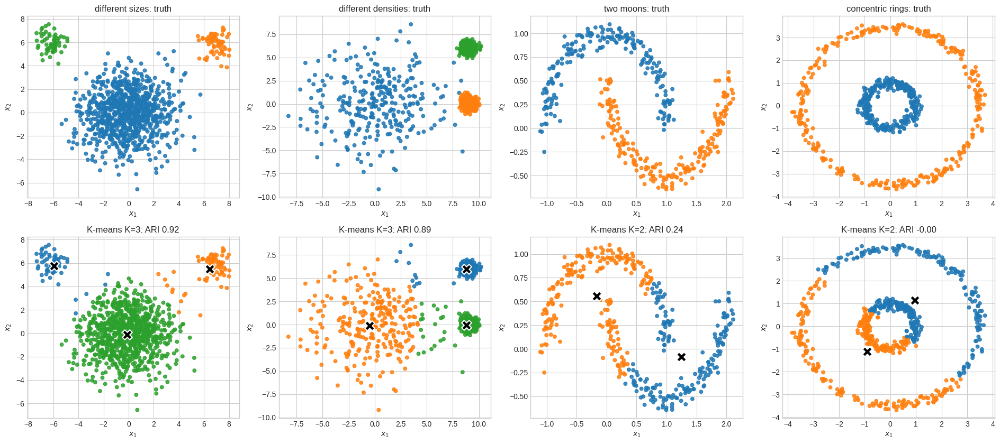

In [42]:
rng = np.random.default_rng(RANDOM_STATE)

# 1) different sizes: one cluster with 900 points, two with 60
X_sizes = np.vstack([rng.normal([0, 0], 1.8, (900, 2)), rng.normal([7, 6], 0.7, (60, 2)), rng.normal([-6, 6], 0.7, (60, 2))])
y_sizes = np.repeat([0, 1, 2], [900, 60, 60])
# 2) different densities: same count, very different spread
X_dens = np.vstack([rng.normal([0, 0], 3.0, (300, 2)), rng.normal([9, 0], 0.4, (300, 2)), rng.normal([9, 6], 0.4, (300, 2))])
y_dens = np.repeat([0, 1, 2], 300)
# 3) non-globular: two moons (from setup) and two concentric rings
ang = rng.uniform(0, 2 * np.pi, 600); r = np.r_[np.full(300, 1.0), np.full(300, 3.5)] + rng.normal(0, 0.12, 600)
X_rings = np.c_[r * np.cos(ang), r * np.sin(ang)]; y_rings = np.repeat([0, 1], 300)

cases = [("different sizes", X_sizes, y_sizes, 3), ("different densities", X_dens, y_dens, 3), ("two moons", X_moons, y_moons, 2), ("concentric rings", X_rings, y_rings, 2)]
fig, axes = plt.subplots(2, 4, figsize=(19, 8.5))
for j, (name, X, y, K) in enumerate(cases):
    km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X)
    plot_clusters(X, y, ax=axes[0, j], title=f"{name}: truth")
    plot_clusters(X, km.labels_, km.cluster_centers_, ax=axes[1, j], title=f"K-means K={K}: ARI {adjusted_rand_score(y, km.labels_):.2f}")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Top row: the truth. Bottom row: what K-means does with the right K. **Sizes**: the big cluster is split and the two small ones are merged into one region, because that lowers SSE. **Densities**: the wide cluster is carved up and the two tight ones share a centroid. **Moons** and **rings**: straight-line boundaries through curved clusters. In every panel the centroids are exactly where SSE wants them; the objective is the problem, not the optimiser.

**The common misread:** blaming the initialisation and running `n_init=50`. These are not local optima. On the rings, the *global* SSE optimum with K = 2 is a straight cut through both rings; no initialisation finds a ring, because a ring is not an SSE-shaped cluster.

</div>

## 21.2 The textbook remedy: over-cluster, then merge

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Ask for many more clusters than you want. Each small K-means cluster is now a *piece* of a true cluster, and pieces of the same true cluster touch each other. Then merge pieces that are close, using single-link hierarchical clustering on the centroids (or on the pieces' nearest-point distances). Two dozen convex pieces stitched together can be any shape at all, and the pieces of a large cluster simply outnumber the pieces of a small one instead of being cut.

</div>


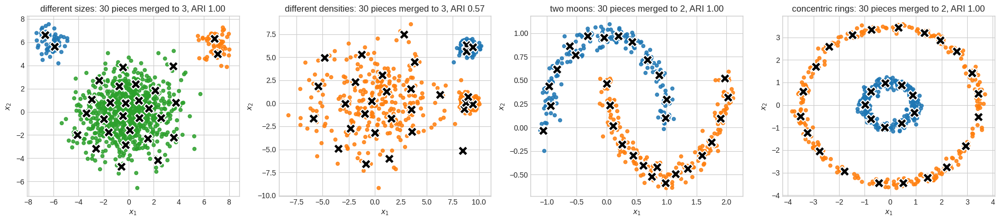

the crosses are the 30 K-means pieces; colours are the merged clusters


In [43]:
from scipy.cluster.hierarchy import linkage, fcluster

def overcluster_then_merge(X, K_final, K_many=30, link="single", random_state=RANDOM_STATE):
    km = KMeans(n_clusters=K_many, n_init=5, random_state=random_state).fit(X)
    # distance between two pieces = the closest pair of points across them (single link on the pieces)
    D = np.full((K_many, K_many), np.inf)
    for a in range(K_many):
        for b in range(a + 1, K_many):
            D[a, b] = D[b, a] = cdist(X[km.labels_ == a], X[km.labels_ == b]).min()
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=link)
    piece_to_cluster = fcluster(Z, K_final, criterion="maxclust") - 1
    return piece_to_cluster[km.labels_], km

fig, axes = plt.subplots(1, 4, figsize=(19, 4.3))
for ax, (name, X, y, K) in zip(axes, cases):
    lab, km_many = overcluster_then_merge(X, K, K_many=30)
    plot_clusters(X, lab, km_many.cluster_centers_, ax=ax, title=f"{name}: 30 pieces merged to {K}, ARI {adjusted_rand_score(y, lab):.2f}")
plt.tight_layout(); plt.show()
print("the crosses are the 30 K-means pieces; colours are the merged clusters")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The same four datasets with thirty K-means pieces merged by single link down to the true K. The moons and the rings are now recovered, because chains of adjacent pieces follow the curve. The size case is fixed too: the big cluster owns most of the pieces. The density case is the one that stays hard, since single link happily bridges the sparse cluster to a dense one through a nearby piece; the ARI there depends on the seed.

**The common misread:** treating this as a free lunch. The merge step inherits single link's weakness (chaining through noise), and `K_many` is one more knob. It is the right tool when you want K-means' speed on shapes K-means cannot draw; DBSCAN (Task 23) is the more direct answer for density.

</div>

## 21.3 Task 21 Summary

**✅ Key Takeaways**
- K-means clusters are convex regions halfway between centroids, sized by SSE; unequal sizes, unequal densities and curved shapes all break that.
- These are failures of the objective, not of the optimiser: more restarts do not help.
- Over-clustering then merging with single link stitches convex pieces into arbitrary shapes and fixes the size and shape cases.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `X_sizes`, `X_dens`, `X_rings` (+ labels), `cases` | the three classic failure datasets plus the moons, as one list |
| `overcluster_then_merge(X, K_final, K_many)` | the textbook remedy: many K-means pieces merged by single link |

**➡️ Next Up:** Task 22 covers the failures that come from the *columns*: unscaled features, too many dimensions, categorical values and missing cells.


# Task 22 · Scaling, Dimensions, Categoricals and Missing Values

## 22.1 Standardise, or the widest column decides

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Euclidean distance adds squared differences across columns. A column measured in thousands (proline in the wine data) contributes squared differences a million times larger than a column measured in units (hue), so K-means on raw wine data clusters by proline alone. Standardising each column to zero mean and unit variance gives every feature the same vote. That is the single most common K-means mistake in practice, and the cheapest to fix.

</div>


feature standard deviations (raw wine):
proline              314.02
magnesium             14.24
alcalinity_of_ash      3.33
color_intensity        2.31
malic_acid             1.11
... hue                     0.228
nonflavanoid_phenols    0.124

ARI vs cultivar: raw 0.371 | standardised 0.897
ARI between raw K-means and K-means on proline ALONE: 1.000


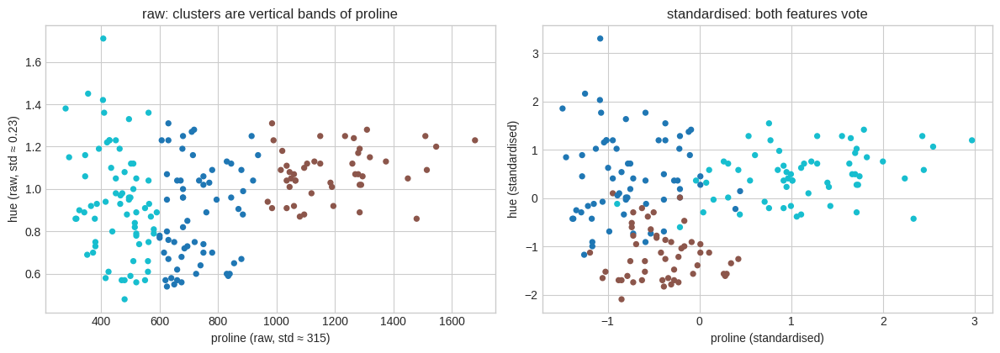

In [44]:
raw = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_wine)
std = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_std_wine)
spread = pd.Series(X_wine.std(axis=0), index=wine.feature_names).sort_values(ascending=False)
print("feature standard deviations (raw wine):"); print(spread.round(2).head(5).to_string()); print("...", spread.round(3).tail(2).to_string())
print(f"\nARI vs cultivar: raw {adjusted_rand_score(y_wine, raw.labels_):.3f} | standardised {adjusted_rand_score(y_wine, std.labels_):.3f}")
# how much of raw K-means is explained by proline alone?
one_col = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_wine[:, [list(wine.feature_names).index("proline")]])
print(f"ARI between raw K-means and K-means on proline ALONE: {adjusted_rand_score(raw.labels_, one_col.labels_):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
i, j = list(wine.feature_names).index("proline"), list(wine.feature_names).index("hue")
axes[0].scatter(X_wine[:, i], X_wine[:, j], c=raw.labels_, cmap="tab10", s=18); axes[0].set_xlabel("proline (raw, std ≈ 315)"); axes[0].set_ylabel("hue (raw, std ≈ 0.23)"); axes[0].set_title("raw: clusters are vertical bands of proline")
axes[1].scatter(X_std_wine[:, i], X_std_wine[:, j], c=std.labels_, cmap="tab10", s=18); axes[1].set_xlabel("proline (standardised)"); axes[1].set_ylabel("hue (standardised)"); axes[1].set_title("standardised: both features vote")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: on raw wine data the three clusters are vertical bands, cut by proline alone; hue plays no part, and the ARI between "K-means on 13 features" and "K-means on proline only" says so. Right: after standardising, the clusters use both axes and the agreement with the cultivars jumps.

**The common misread:** standardising *always*. If the columns share a unit and the scale is meaningful (pixel intensities, dollar amounts across categories), standardising throws away information: a feature with tiny variance is then inflated to equal importance. Scale when units differ; think when they do not.

</div>

## 22.2 The curse of dimensionality: distances concentrate

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

In high dimensions the nearest and farthest neighbour of a point are almost equally far away: the *ratio* of farthest to nearest distance tends to 1 as $d$ grows. "Nearest centroid" then means little, and the silhouette of any clustering slides toward zero. The cure is to cluster in a lower-dimensional space that keeps the structure: PCA, or the embeddings of Part 11.

</div>


      farthest/nearest (uniform noise)  silhouette (4 blobs, std 4)  ARI (4 blobs, std 4)
d                                                                                        
2                                  inf                        0.397                 0.588
5                                  inf                        0.269                 0.785
10                                 inf                        0.291                 0.943
50                                 inf                        0.427                 1.000
100                                inf                        0.439                 1.000
500                                inf                        0.427                 1.000
1000                               inf                        0.428                 1.000


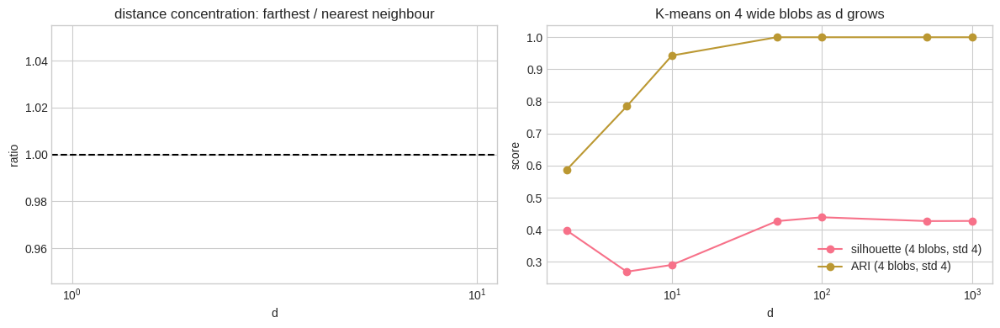

In [45]:
rows = []
for d in [2, 5, 10, 50, 100, 500, 1000]:
    Xd = rng.normal(size=(500, d))
    D = cdist(Xd[:50], Xd); np.fill_diagonal(D[:, :50], np.inf)
    ratio = D.max(axis=1) / D.min(axis=1)
    Xc, yc = make_blobs(n_samples=500, centers=4, n_features=d, cluster_std=4.0, random_state=RANDOM_STATE)
    lab = KMeans(n_clusters=4, n_init=5, random_state=RANDOM_STATE).fit_predict(Xc)
    rows.append({"d": d, "farthest/nearest (uniform noise)": ratio.mean(), "silhouette (4 blobs, std 4)": silhouette_score(Xc, lab), "ARI (4 blobs, std 4)": adjusted_rand_score(yc, lab)})
curse = pd.DataFrame(rows).set_index("d")
print(curse.round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
curse.iloc[:, 0].plot(ax=axes[0], marker="o", logx=True); axes[0].axhline(1, color="k", ls="--"); axes[0].set_title("distance concentration: farthest / nearest neighbour"); axes[0].set_ylabel("ratio")
curse.iloc[:, 1:].plot(ax=axes[1], marker="o", logx=True); axes[1].set_title("K-means on 4 wide blobs as d grows"); axes[1].set_ylabel("score")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: in 2 dimensions a point's farthest neighbour is many times farther than its nearest; by 1 000 dimensions the ratio is close to 1 and "near" has lost its meaning. Right: for four blobs whose spread is wide relative to their separation, K-means recovers them well in low dimensions, and the silhouette decays toward zero as the dimension grows even though the ARI can stay high for a while: the clusters are still *found*, but no internal metric can *see* them.

**The common misread:** "high-dimensional data cannot be clustered." It can, when the clusters live on a low-dimensional structure inside the high-dimensional space (digits do; Part 8 shows PCA and t-SNE before K-means). What fails is the *internal validity* of the result, so choose K in the reduced space.

</div>

## 22.3 Categorical columns: one-hot, or K-modes

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A mean of "red" and "blue" does not exist. Two workable answers: **one-hot encode** the categorical columns (the mean of one-hot vectors is a frequency vector, so K-means works and the centroid reads as "70 % red, 30 % blue"), or use **K-modes** (Huang, 1998), which swaps Euclidean distance for the number of mismatched attributes and the mean for the per-column **mode**. K-prototypes combines both for mixed tables. Missing values need a decision before either: impute (median for numeric, mode for categorical) or drop, and record which.

</div>


In [46]:
# a mixed toy table: 400 households, three planted segments, two categorical + two numeric columns, 5% missing
n = 400; seg = rng.integers(0, 3, n)
city = np.where(seg == 0, rng.choice(["metro", "city"], n, p=[0.8, 0.2]), np.where(seg == 1, rng.choice(["town", "city"], n, p=[0.7, 0.3]), rng.choice(["metro", "town", "city"], n)))
car = np.where(seg == 2, rng.random(n) < 0.9, rng.random(n) < 0.3)
income = np.where(seg == 0, rng.normal(9000, 1200, n), np.where(seg == 1, rng.normal(4000, 800, n), rng.normal(6000, 900, n)))
dining = np.where(seg == 2, rng.normal(600, 120, n), rng.normal(250, 80, n))
mixed = pd.DataFrame({"city": city, "owns_car": car, "income": income.round(0), "dining": dining.round(0)})
mixed.loc[rng.random(n) < 0.05, "dining"] = np.nan
mixed.loc[rng.random(n) < 0.05, "city"] = None
print("missing per column:", mixed.isna().sum().to_dict())

def kmodes(Xcat, K, n_iter=20, random_state=RANDOM_STATE):
    """K-modes: Hamming distance (number of mismatches) and per-column modes as prototypes."""
    rng_ = np.random.default_rng(random_state)
    modes = Xcat[rng_.choice(len(Xcat), K, replace=False)].copy()
    for _ in range(n_iter):
        D = np.array([[np.sum(x != m) for m in modes] for x in Xcat])
        labels = D.argmin(axis=1)
        new = np.array([[pd.Series(Xcat[labels == k, j]).mode().iloc[0] if np.any(labels == k) else modes[k, j] for j in range(Xcat.shape[1])] for k in range(K)], dtype=object)
        if np.array_equal(new, modes):
            break
        modes = new
    return labels, modes

# route A: impute + one-hot + standardise + K-means
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
pre = ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), ["income", "dining"]),
                         ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(sparse_output=False))]), ["city", "owns_car"])])
Xm = pre.fit_transform(mixed)
lab_onehot = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit_predict(Xm)
# route B: K-modes on the categorical columns only (after mode imputation)
Xcat = mixed[["city", "owns_car"]].fillna(mixed[["city", "owns_car"]].mode().iloc[0]).astype(str).to_numpy()
lab_modes, modes = kmodes(Xcat, 3)
print(f"\nARI vs planted segments: one-hot + K-means {adjusted_rand_score(seg, lab_onehot):.3f} | K-modes (categoricals only) {adjusted_rand_score(seg, lab_modes):.3f}")
print("K-modes prototypes (city, owns_car):", [tuple(m) for m in modes])
centroid_table = pd.DataFrame(KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(Xm).cluster_centers_, columns=pre.get_feature_names_out()).round(2)
print("\none-hot centroids read as frequencies:"); print(centroid_table.to_string())


missing per column: {'city': 25, 'owns_car': 0, 'income': 0, 'dining': 13}

ARI vs planted segments: one-hot + K-means 0.913 | K-modes (categoricals only) 0.129
K-modes prototypes (city, owns_car): [('city', 'True'), ('metro', 'True'), ('metro', 'False')]

one-hot centroids read as frequencies:
   num__income  num__dining  cat__city_city  cat__city_metro  cat__city_town  cat__city_None  cat__owns_car_False  cat__owns_car_True
0        -1.00        -0.58            0.30             0.01            0.64            0.04                 0.61                0.39
1         1.19        -0.62            0.22             0.72            0.00            0.06                 0.77                0.23
2        -0.20         1.24            0.29             0.35            0.27            0.08                 0.08                0.92


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: put the preprocessing in the pipeline

`ColumnTransformer` → `KMeans` in one `Pipeline` means the imputation statistics and the one-hot vocabulary are learned once and applied identically to new rows (Part 10 saves and reloads exactly this object). The one-hot centroids are readable on their own: a cluster whose `city_metro` coordinate is 0.8 is "mostly metro". K-modes wins when the table is *all* categorical and large, because it never builds a wide one-hot matrix.

</div>

## 22.4 Task 22 Summary

**✅ Key Takeaways**
- Unscaled columns let the widest one decide; standardise when units differ, and think before standardising when they do not.
- In high dimensions distances concentrate and internal metrics go blind; reduce first, then cluster and choose K.
- Categoricals: one-hot gives frequency centroids inside a standard pipeline; K-modes swaps in Hamming distance and modes. Impute missing values deliberately and record it.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `raw`, `std`, `spread` | wine clustered raw vs standardised, and the column spreads that explain the difference |
| `curse` | farthest/nearest ratio and K-means scores as dimension grows |
| `mixed`, `pre`, `Xm`, `kmodes(Xcat, K)` | the mixed toy table, its preprocessing pipeline and the from-scratch K-modes |

**➡️ Next Up:** Task 23 puts hierarchical clustering and DBSCAN next to K-means on the failure cases, once, so the trade-offs are concrete.


# Task 23 · One Comparison: K-means vs Hierarchical vs DBSCAN on the Failure Cases

## 23.1 Three definitions of a cluster

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

K-means: a cluster is a region around a prototype. **Agglomerative hierarchical clustering**: a cluster is what you get by repeatedly merging the two closest groups, where "closest" is single link (nearest points), complete link (farthest points) or Ward (smallest SSE increase; Ward is the hierarchical cousin of K-means). **DBSCAN**: a cluster is a connected region of high density; points in sparse regions are noise, and K is not chosen at all, only a radius `eps` and a minimum count. The survey notebook in this folder covers each in depth; here they meet on K-means' own failure cases.

</div>


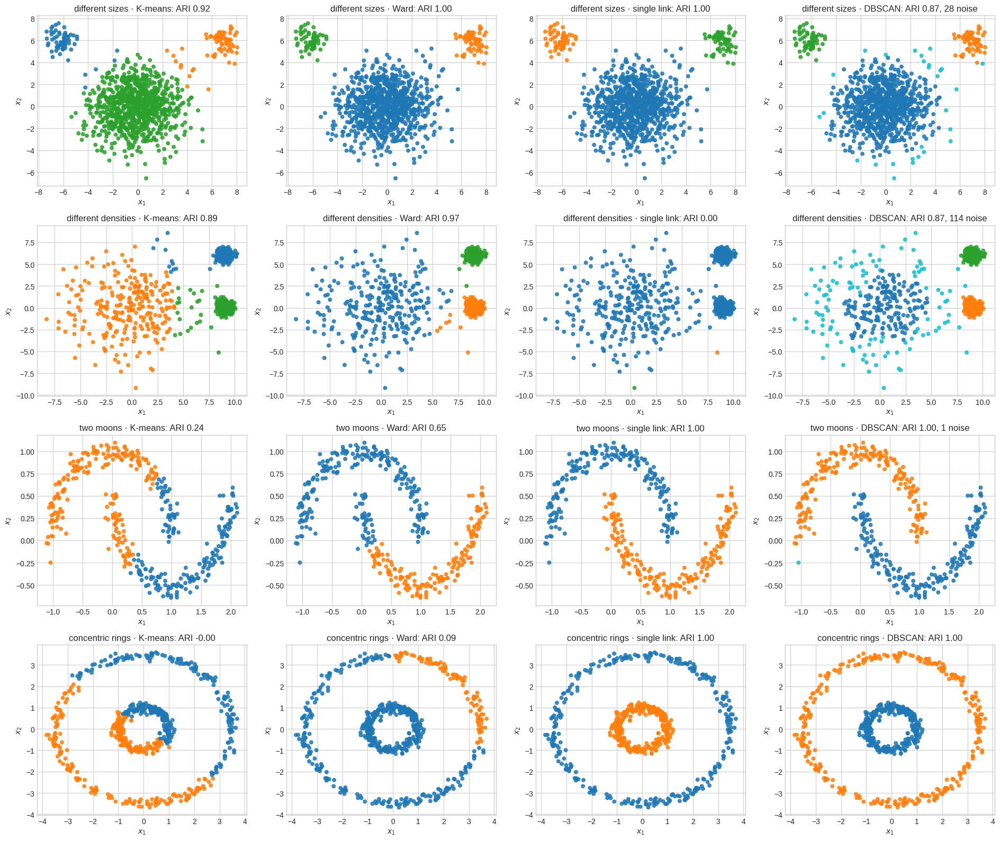

ARI vs truth (DBSCAN noise points count as their own label):
                     K-means  Ward  single link  DBSCAN
different sizes         0.92  1.00          1.0    0.87
different densities     0.89  0.97          0.0    0.87
two moons               0.24  0.65          1.0    1.00
concentric rings       -0.00  0.09          1.0    1.00


In [47]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN

methods = {
    "K-means": lambda X, K: KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit_predict(X),
    "Ward": lambda X, K: AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(X),
    "single link": lambda X, K: AgglomerativeClustering(n_clusters=K, linkage="single").fit_predict(X),
    "DBSCAN": None,   # eps per dataset below
}
eps_for = {"different sizes": 0.9, "different densities": 0.9, "two moons": 0.2, "concentric rings": 0.5}
scores, timings = {}, {}
fig, axes = plt.subplots(4, 4, figsize=(19, 16))
for i, (name, X, y, K) in enumerate(cases):
    for j, (mname, fn) in enumerate(methods.items()):
        t0 = time.perf_counter()
        lab = DBSCAN(eps=eps_for[name], min_samples=8).fit_predict(X) if mname == "DBSCAN" else fn(X, K)
        timings[(name, mname)] = time.perf_counter() - t0
        noise = int((lab == -1).sum())
        scores[(name, mname)] = adjusted_rand_score(y, lab)
        plot_clusters(X, np.where(lab < 0, 9, lab), ax=axes[i, j], title=f"{name} · {mname}: ARI {scores[(name, mname)]:.2f}" + (f", {noise} noise" if noise else ""))
plt.tight_layout(); plt.show()
score_tab = pd.Series(scores).unstack().loc[[c[0] for c in cases], list(methods)]
print("ARI vs truth (DBSCAN noise points count as their own label):"); print(score_tab.round(2).to_string())


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Rows are the failure cases, columns the methods. **Ward** behaves like K-means (same objective, greedy instead of iterative) and fails the same way on shapes. **Single link** follows chains, so it recovers the moons and the rings, and it falls apart on the size and density cases where a few bridging points merge everything into one blob plus singletons. **DBSCAN** handles shapes and sizes with one `eps`, marks stragglers as noise (grey), and is the method that also handles *varying* density worst of all when a single `eps` must serve both a dense and a sparse cluster.

**The common misread:** picking "the best method" from this table. Each column is right about a different definition of a cluster. The size and density rows show that no method here is right about everything; HDBSCAN (in the SOTA clustering notebook) is the modern answer to the density row.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: the DBSCAN numbers above used a hand-picked `eps` per dataset

That is the honest cost of DBSCAN: `eps` is in the data's units and there is no universal default. The k-distance plot (sort each point's distance to its `min_samples`-th neighbour; the knee is `eps`) is the standard way to choose it. K-means needs K; DBSCAN needs `eps`; neither is free.

</div>

## 23.2 When K-means still wins


seconds (single link skipped above 5 000 rows: its distance matrix would be 3.2 GB at 20 000):
       K-means    Ward  single link  DBSCAN
n                                          
1000     0.023   0.036        0.020   0.012
5000     0.046   1.078        0.207   0.042
20000    0.066  42.477          NaN   0.770


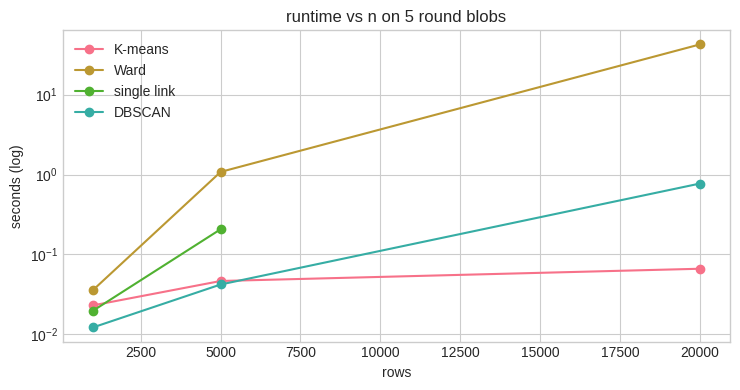

In [48]:
# scale: the same four methods on growing n (2-D blobs), wall-clock seconds
rows = []
for n in [1_000, 5_000, 20_000]:
    Xn, _ = make_blobs(n_samples=n, centers=5, random_state=RANDOM_STATE)
    row = {"n": n}
    for mname, fn in methods.items():
        if mname == "single link" and n > 5_000:
            row[mname] = np.nan; continue                       # O(n^2) memory: skipped deliberately
        t0 = time.perf_counter()
        DBSCAN(eps=0.5, min_samples=8).fit(Xn) if mname == "DBSCAN" else fn(Xn, 5)
        row[mname] = time.perf_counter() - t0
    rows.append(row)
scale_tab = pd.DataFrame(rows).set_index("n")
print("seconds (single link skipped above 5 000 rows: its distance matrix would be 3.2 GB at 20 000):"); print(scale_tab.round(3).to_string())
fig, ax = plt.subplots(figsize=(7.5, 4))
scale_tab.plot(ax=ax, marker="o", logy=True); ax.set_title("runtime vs n on 5 round blobs"); ax.set_ylabel("seconds (log)"); ax.set_xlabel("rows")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Runtime on a log scale as the row count grows. K-means and DBSCAN grow roughly linearly; Ward's agglomerative clustering grows faster and single link is stopped at 5 000 rows because its full distance matrix would not fit in memory at 20 000. The gap between the K-means line and the others is the reason K-means is the default at scale.

**The common misread:** comparing runtimes at one size. The slopes matter more than the heights; a method that is fast at 1 000 rows and quadratic will lose at 100 000.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Takeaway: the honest decision table

| Data looks like | Reach for |
|---|---|
| Round, similar-size groups, or you need prototypes / a codebook / speed at scale | **K-means** (mini-batch beyond ~10⁶ rows) |
| Elongated or tilted groups with enough points per group | Gaussian mixture (Part 5) |
| Curved shapes, chains, rings | DBSCAN/HDBSCAN, or over-cluster-and-merge, or spectral |
| A hierarchy is the deliverable (taxonomy, dendrogram) | Agglomerative (Ward for compact groups), or bisecting K-means (Part 4) at scale |
| Very different densities | HDBSCAN |
| Only a similarity matrix, no coordinates | K-medoids, spectral, hierarchical |

K-means keeps its place because it is the fastest, the most scalable, the one with a prototype to show, and the one whose failure modes are the easiest to see coming.

</div>

## 23.3 Task 23 Summary

**✅ Key Takeaways**
- Ward is K-means' hierarchical twin and shares its blind spots; single link sees shapes and chains through noise; DBSCAN sees shapes and sizes, needs `eps`, and struggles with varying density.
- On round blobs at scale, K-means is one to two orders of magnitude faster than the alternatives and the only one whose memory is linear in n.
- Choose by the definition of a cluster the data needs, not by a leaderboard.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `methods`, `eps_for`, `score_tab` | the four methods, the hand-picked DBSCAN radii, and the ARI table on the failure cases |
| `scale_tab` | runtime vs n for the four methods |

**➡️ Next Up:** Part 8 does the real work: customer segmentation with a full preprocessing pipeline, colour quantisation of a real photograph, and digit clustering graded against the truth.


# Part 8 · Real-World End-to-End ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Three complete projects, each the way it would be done at work. **Customer segmentation**: a mixed table with categoricals and missing values, a preprocessing pipeline, choosing K, profiling the segments into names a marketing team can use, and checking that the segments are stable. **Colour quantisation**: K-means on the pixels of a photograph to compress sixteen million colours into sixteen, the example that makes "prototype" visible. **Digits**: clustering images without labels, drawing the centroids as images, and grading the result against the truth, then improving it with a non-linear embedding before clustering.

</div>


# Task 24 · Customer Segmentation, Start to Finish

## 24.1 The data and the pipeline

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A segmentation project has five steps: choose the features that describe *behaviour* (not identifiers), preprocess them in a pipeline that can be reused on new customers, choose K with the criteria of Part 6, **profile** each cluster (what is high, what is low, compared with everyone), and name the segments. The names are the deliverable; the centroids are just numbers.

</div>


In [49]:
# a realistic synthetic customer table: 2 000 customers, five planted behaviours, categoricals, skewed spends, 3% missing
rng = np.random.default_rng(RANDOM_STATE)
N = 2000
seg_true = rng.choice(5, N, p=[0.30, 0.25, 0.20, 0.15, 0.10])
profiles = {  # (visits/month, avg basket, online share, months tenure, returns rate)
    0: (2, 45, 0.20, 24, 0.03), 1: (8, 30, 0.10, 60, 0.02), 2: (3, 140, 0.70, 12, 0.10),
    3: (1, 220, 0.90, 6, 0.15), 4: (12, 15, 0.05, 90, 0.01)}
P = np.array([profiles[s] for s in seg_true], dtype=float)
cust = pd.DataFrame({
    "customer_id": np.arange(N),
    "visits_per_month": np.clip(rng.normal(P[:, 0], 1.2), 0.2, None).round(1),
    "avg_basket": np.clip(rng.lognormal(np.log(P[:, 1]), 0.35), 5, None).round(0),
    "online_share": np.clip(rng.normal(P[:, 2], 0.12), 0, 1).round(2),
    "tenure_months": np.clip(rng.normal(P[:, 3], 8), 1, None).round(0),
    "returns_rate": np.clip(rng.normal(P[:, 4], 0.03), 0, 1).round(3),
    "channel": np.where(P[:, 2] > 0.5, rng.choice(["app", "web", "store"], N, p=[0.5, 0.4, 0.1]), rng.choice(["app", "web", "store"], N, p=[0.1, 0.2, 0.7])),
    "plan": rng.choice(["free", "plus", "premium"], N, p=[0.6, 0.3, 0.1]),
})
for col in ["avg_basket", "tenure_months"]:
    cust.loc[rng.random(N) < 0.03, col] = np.nan
cust.loc[rng.random(N) < 0.02, "channel"] = None
NUM = ["visits_per_month", "avg_basket", "online_share", "tenure_months", "returns_rate"]; CAT = ["channel", "plan"]
print(cust.head().to_string()); print("\nmissing:", cust.isna().sum()[cust.isna().sum() > 0].to_dict())

from sklearn.preprocessing import FunctionTransformer
seg_pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), ("sc", StandardScaler())]), NUM),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))]), CAT)])
Xs = seg_pre.fit_transform(cust)
feat_names = seg_pre.get_feature_names_out()
print(f"\npreprocessed matrix: {Xs.shape} | columns: {list(feat_names)}")


   customer_id  visits_per_month  avg_basket  online_share  tenure_months  returns_rate channel     plan
0            0               0.2       109.0          0.92            1.0         0.202   store     free
1            1               9.1         NaN          0.00           59.0         0.039     app  premium
2            2               0.2       310.0          0.99            9.0         0.224     web     free
3            3               2.7       112.0          0.53           17.0         0.077     app     plus
4            4               1.3        34.0          0.35           22.0         0.000   store     plus

missing: {'avg_basket': 67, 'tenure_months': 56, 'channel': 52}

preprocessed matrix: (2000, 12) | columns: ['num__visits_per_month', 'num__avg_basket', 'num__online_share', 'num__tenure_months', 'num__returns_rate', 'cat__channel_app', 'cat__channel_store', 'cat__channel_web', 'cat__channel_None', 'cat__plan_free', 'cat__plan_plus', 'cat__plan_premium']


<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: `customer_id` is not a feature

An id column would give every customer a unique coordinate and K-means would happily cluster on it. The pipeline above lists the behavioural columns explicitly. The same goes for anything that is a *consequence* of the segment you hope to find (a "VIP" flag someone assigned by hand): leave it out and use it afterwards to check the clusters.

</div>

## 24.2 Choosing K, then profiling


   silhouette     DB    gap  stability (ARI)
K                                           
2       0.433  0.938  0.578            1.000
3       0.334  1.166  0.750            0.999
4       0.282  1.547  0.759            0.976
5       0.231  1.692  0.757            0.757
6       0.212  1.884  0.750            0.962
7       0.204  1.916  0.737            0.857
8       0.205  1.886  0.731            0.935
9       0.207  1.838  0.726            0.918

silhouette picks K = 2; gap rule picks 3; stability picks 2  (planted: 5)


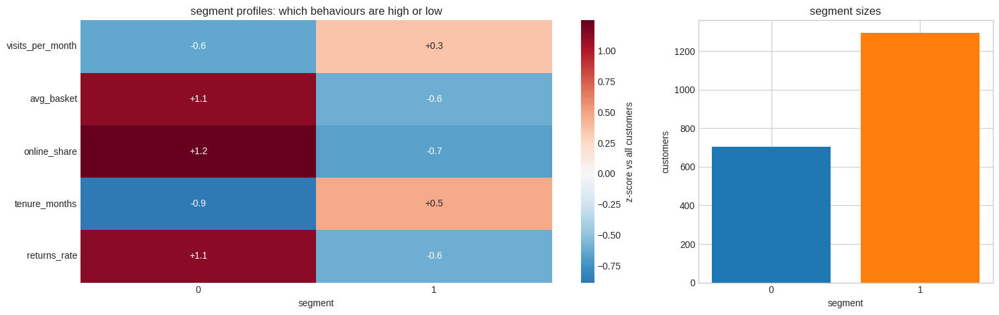

         visits_per_month  avg_basket  online_share  tenure_months  returns_rate channel  plan     n
segment                                                                                             
0                     2.2       186.8           0.8           10.1           0.1     app  free   705
1                     5.9        36.4           0.1           48.4           0.0   store  free  1295

ARI vs the planted behaviours: 0.379


In [50]:
t_seg = choose_k_table(Xs, list(range(2, 10)), B=10)
print(t_seg[["silhouette", "DB", "gap", "stability (ARI)"]].round(3).to_string())
K_SEG = int(t_seg.silhouette.idxmax())
print(f"\nsilhouette picks K = {K_SEG}; gap rule picks {t_seg.attrs['gap_choice']}; stability picks {t_seg['stability (ARI)'].idxmax()}  (planted: 5)")

seg_km = KMeans(n_clusters=K_SEG, n_init=20, random_state=RANDOM_STATE).fit(Xs)
cust["segment"] = seg_km.labels_
# profile: mean of each raw feature per segment, as a z-score relative to the whole base (how unusual each segment is)
prof = cust.groupby("segment")[NUM].mean()
z_prof = (prof - cust[NUM].mean()) / cust[NUM].std()
share = cust.groupby("segment")[["channel", "plan"]].agg(lambda s: s.value_counts(normalize=True).idxmax())
sizes = cust.segment.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [2, 1]})
sns.heatmap(z_prof.T, annot=True, fmt="+.1f", cmap="RdBu_r", center=0, ax=axes[0], cbar_kws={"label": "z-score vs all customers"})
axes[0].set_title("segment profiles: which behaviours are high or low"); axes[0].set_xlabel("segment")
axes[1].bar(sizes.index.astype(str), sizes.values, color=plt.cm.tab10(sizes.index)); axes[1].set_title("segment sizes"); axes[1].set_xlabel("segment"); axes[1].set_ylabel("customers")
plt.tight_layout(); plt.show()
summary = prof.round(1).join(share).join(sizes.rename("n"))
print(summary.to_string())
print(f"\nARI vs the planted behaviours: {adjusted_rand_score(seg_true, cust.segment):.3f}")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: each column is a segment, each row a behaviour, and the colour is how far that segment's average sits from the whole customer base in standard deviations. Reading down a column gives the segment's story: one is "frequent, small baskets, in-store, long tenure" (loyal regulars), one is "rare, huge baskets, online, new, high returns" (big-ticket online shoppers), and so on. Right: the sizes, which matter as much as the profiles: a 10 % segment with distinctive behaviour is a campaign; a 2 % segment is noise.

**The common misread:** describing a segment by its raw means ("average basket 140"). The z-score profile says what is *distinctive*, and distinctiveness is what a name should capture.

</div>

## 24.3 Name them, and check they are stable


In [51]:
def name_segment(z):
    hi = [f for f in NUM if z[f] > 0.5]; lo = [f for f in NUM if z[f] < -0.5]
    return ("high " + ", ".join(hi) if hi else "") + ((" / " if hi and lo else "") + "low " + ", ".join(lo) if lo else "") or "average on everything"
names = {k: name_segment(z_prof.loc[k]) for k in z_prof.index}
for k, v in names.items():
    print(f"segment {k} ({sizes[k]:4d} customers, mostly {share.loc[k, 'channel']}/{share.loc[k, 'plan']}): {v}")

# stability across seeds and across bootstrap samples: does the segmentation survive?
labs = [KMeans(n_clusters=K_SEG, n_init=1, random_state=s).fit_predict(Xs) for s in range(8)]
seed_ari = [adjusted_rand_score(labs[0], l) for l in labs[1:]]
boot_ari = []
for s in range(8):
    idx = rng.choice(N, N, replace=True)
    kb = KMeans(n_clusters=K_SEG, n_init=5, random_state=s).fit(Xs[idx])
    boot_ari.append(adjusted_rand_score(seg_km.labels_, kb.predict(Xs)))
print(f"\nstability: ARI across 8 single-init seeds = {np.mean(seed_ari):.3f} ± {np.std(seed_ari):.3f} | across 8 bootstrap refits = {np.mean(boot_ari):.3f} ± {np.std(boot_ari):.3f}")


segment 0 ( 705 customers, mostly app/free): high avg_basket, online_share, returns_rate / low visits_per_month, tenure_months
segment 1 (1295 customers, mostly store/free): low avg_basket, online_share, returns_rate

stability: ARI across 8 single-init seeds = 1.000 ± 0.000 | across 8 bootstrap refits = 1.000 ± 0.001


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: a segmentation is a claim; stability is its evidence

If refitting on a bootstrap sample moves 30 % of customers to another segment, the segments are artefacts of the sample and no campaign should be built on them. Report the bootstrap ARI next to the profiles. And keep the pipeline object: Part 10 shows how the *same* preprocessing and centroids assign next month's customers, which is the only way the segment names keep meaning anything.

</div>

## 24.4 Task 24 Summary

**✅ Key Takeaways**
- Behavioural features in, identifiers and consequences out; preprocessing lives in a `ColumnTransformer` so it can be reused.
- Choose K with several criteria, then profile with z-scores against the base: distinctiveness, not raw means, gives the names.
- Bootstrap and seed stability are the evidence that the segments are real.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `cust`, `NUM`, `CAT`, `seg_pre`, `Xs` | the customer table, its feature lists, the preprocessing pipeline and the matrix |
| `K_SEG`, `seg_km`, `z_prof`, `names`, `summary` | the chosen K, the fit, the z-score profiles, the generated names and the summary table |
| `seed_ari`, `boot_ari` | the two stability checks |

**➡️ Next Up:** Task 25 clusters the pixels of a photograph.


# Task 25 · Colour Quantisation: Sixteen Million Colours to Sixteen

## 25.1 Pixels are points in a 3-D colour space

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A colour photograph is a table with one row per pixel and three columns (red, green, blue). Run K-means with K = 16 on that table and each centroid is a colour; replace every pixel by its centroid and the image needs only 4 bits per pixel instead of 24. The picture still looks like the picture, because the sixteen prototypes were chosen to minimise the total colour error. This is the example that makes "a centroid is a prototype" literal, and it is vector quantisation, the idea behind codebooks in Part 11.

</div>


image (427, 640, 3) -> 273,280 pixels x 3 channels | distinct colours: 96,615


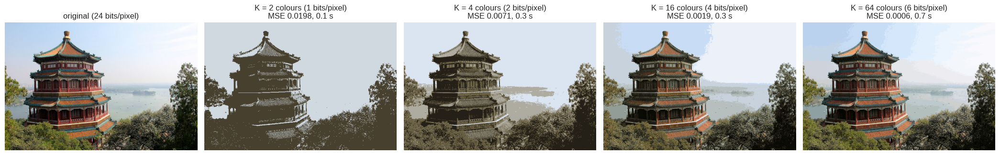

In [52]:
from sklearn.datasets import load_sample_image
china = load_sample_image("china.jpg")                        # ships with scikit-learn, no download
pixels = china.reshape(-1, 3).astype(float) / 255.0
print(f"image {china.shape} -> {pixels.shape[0]:,} pixels x 3 channels | distinct colours: {len(np.unique(china.reshape(-1, 3), axis=0)):,}")

# fit on a 10% sample of pixels (mini-batch K-means would also do), then quantise every pixel
sample = pixels[rng.choice(len(pixels), 100_000, replace=False)]
quantised = {}
for K in [2, 4, 16, 64]:
    t0 = time.perf_counter()
    km = MiniBatchKMeans(n_clusters=K, batch_size=4096, n_init=3, random_state=RANDOM_STATE).fit(sample)
    lab = km.predict(pixels)
    quantised[K] = (km.cluster_centers_[lab].reshape(china.shape), km, lab, time.perf_counter() - t0)

fig, axes = plt.subplots(1, 5, figsize=(21, 4.6))
axes[0].imshow(china); axes[0].set_title("original (24 bits/pixel)"); axes[0].axis("off")
for ax, K in zip(axes[1:], [2, 4, 16, 64]):
    img, km, lab, t = quantised[K]
    mse = float(((pixels - km.cluster_centers_[lab]) ** 2).mean())
    ax.imshow(np.clip(img, 0, 1)); ax.set_title(f"K = {K} colours ({np.log2(K):.0f} bits/pixel)\nMSE {mse:.4f}, {t:.1f} s"); ax.axis("off")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left to right: the original and the same photograph rendered with 2, 4, 16 and 64 colours. Two colours is a silhouette; four is a poster; sixteen is recognisably the photo with flat patches in the sky and the shadows; sixty-four is hard to tell from the original at this size. The MSE under each panel is SSE per pixel, K-means' own objective, and it falls with K as Part 6 said it must.

**The common misread:** expecting the sixteen colours to be "the sixteen most common colours". They are the sixteen *prototypes* that minimise total squared error, which spends more colours where the image has many similar shades (the sky's gradient) and fewer where the colours are rare but distinct.

</div>

## 25.2 The colour space before and after


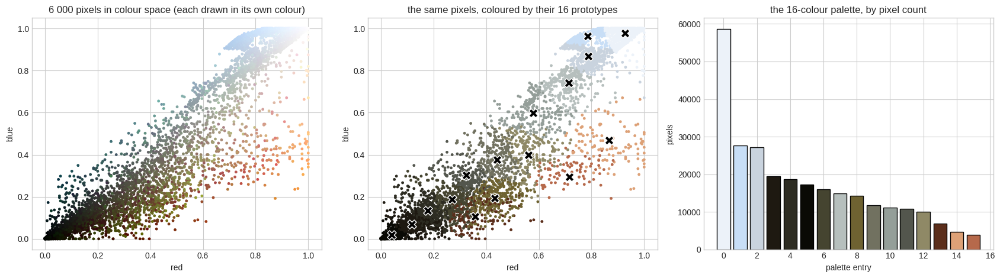

the palette (16 x 3 floats) plus one 4-bit index per pixel: 136,832 bytes vs 819,840 bytes raw -> 6.0x smaller


In [53]:
img16, km16, lab16, _ = quantised[16]
idx = rng.choice(len(pixels), 6000, replace=False)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].scatter(pixels[idx, 0], pixels[idx, 2], c=pixels[idx], s=6); axes[0].set_xlabel("red"); axes[0].set_ylabel("blue"); axes[0].set_title("6 000 pixels in colour space (each drawn in its own colour)")
axes[1].scatter(pixels[idx, 0], pixels[idx, 2], c=km16.cluster_centers_[lab16[idx]], s=6); axes[1].scatter(km16.cluster_centers_[:, 0], km16.cluster_centers_[:, 2], c="black", marker="X", s=120, edgecolor="white")
axes[1].set_xlabel("red"); axes[1].set_ylabel("blue"); axes[1].set_title("the same pixels, coloured by their 16 prototypes")
counts = np.bincount(lab16, minlength=16); order = np.argsort(counts)[::-1]
axes[2].bar(range(16), counts[order], color=np.clip(km16.cluster_centers_[order], 0, 1), edgecolor="k"); axes[2].set_title("the 16-colour palette, by pixel count"); axes[2].set_xlabel("palette entry"); axes[2].set_ylabel("pixels")
plt.tight_layout(); plt.show()
print(f"the palette (16 x 3 floats) plus one 4-bit index per pixel: {16 * 3 * 4 + len(pixels) * 0.5:,.0f} bytes vs {len(pixels) * 3:,} bytes raw -> {len(pixels) * 3 / (16 * 12 + len(pixels) * 0.5):.1f}x smaller")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: a sample of pixels placed by their red and blue values, each drawn in its own colour: a continuous cloud. Middle: the same pixels drawn in the colour of their prototype, with the sixteen prototypes as crosses: the cloud has been tiled into sixteen Voronoi cells. Right: the palette sorted by use; the most-used entries are the sky and the shadow tones, which is where the pixels are.

**The common misread:** treating the crosses as "cluster centres" in the usual sense. In this application nobody cares whether the sixteen cells are "real clusters": they are a codebook, and the only score is the reconstruction error. The same shift of perspective, from clusters to codes, is the whole of Part 11.

</div>

## 25.3 Task 25 Summary

**✅ Key Takeaways**
- An image is a pixel table; K-means centroids in RGB space are a palette; the labels are the compressed image.
- MSE per pixel is SSE per point; it falls with K, and 16 to 64 colours already look like the photo.
- Fit on a sample with mini-batch K-means, then `predict` on every pixel; this is vector quantisation.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `china`, `pixels`, `sample` | the photograph, its pixel table in [0, 1], and the fitting sample |
| `quantised[K]` | reconstructed image, the fitted `MiniBatchKMeans`, per-pixel labels and the fit time per K |

**➡️ Next Up:** Task 26 clusters handwritten digits, draws the centroids as images, and improves the result with an embedding before clustering.


# Task 26 · Digits: Cluster Centres as Images, and Embedding Before Clustering

## 26.1 Ten clusters of 64-pixel vectors

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Each digit image is a point in 64 dimensions (8 × 8 pixels). K-means with K = 10 knows nothing about digits, yet its ten centroids, reshaped back to 8 × 8, look like digits: the prototype of a cluster of sevens is a blurred seven. Grading it needs the trick from Part 6's external metrics: cluster labels are arbitrary numbers, so map each cluster to the true digit that occurs most often in it (the mode) and then compute accuracy, or skip the mapping and use ARI / NMI, which do not need it.

</div>


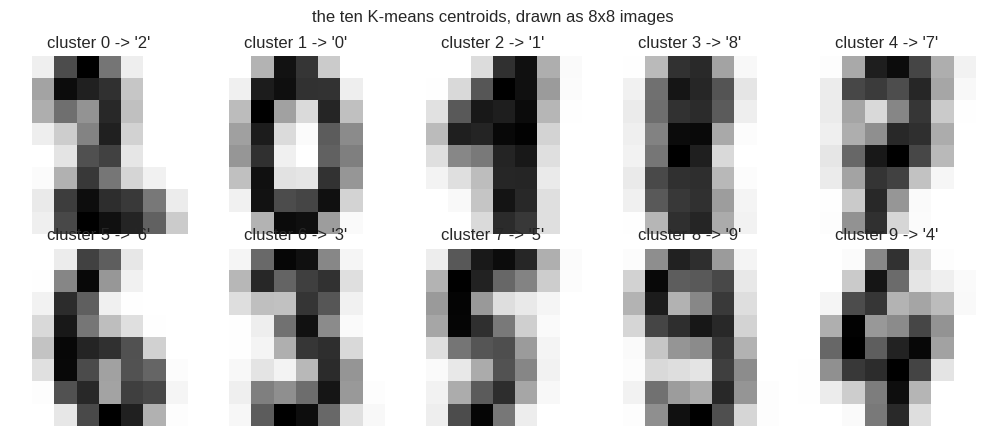

accuracy after mode-mapping: 0.794 | ARI 0.667 | NMI 0.739
clusters mapped to the same digit (a digit split across clusters): none | digits with no cluster of their own: none


In [54]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix

km_d = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE).fit(X_digits)
centers_img = km_d.cluster_centers_.reshape(10, 8, 8)

def map_clusters_to_labels(cluster_labels, y):
    mapping = {k: mode(y[cluster_labels == k], keepdims=False).mode for k in np.unique(cluster_labels)}
    return np.array([mapping[k] for k in cluster_labels]), mapping

pred_d, mapping_d = map_clusters_to_labels(km_d.labels_, y_digits)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for ax, k in zip(axes.flat, range(10)):
    ax.imshow(centers_img[k], cmap="binary", interpolation="nearest"); ax.set_title(f"cluster {k} -> '{mapping_d[k]}'"); ax.axis("off")
plt.suptitle("the ten K-means centroids, drawn as 8x8 images"); plt.tight_layout(); plt.show()
print(f"accuracy after mode-mapping: {accuracy_score(y_digits, pred_d):.3f} | ARI {adjusted_rand_score(y_digits, km_d.labels_):.3f} | NMI {normalized_mutual_info_score(y_digits, km_d.labels_):.3f}")
print("clusters mapped to the same digit (a digit split across clusters):", [d for d in range(10) if list(mapping_d.values()).count(d) > 1] or "none",
      "| digits with no cluster of their own:", sorted(set(range(10)) - set(mapping_d.values())) or "none")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Ten centroids that a person can read as digits, found without a single label. The title on each shows which true digit that cluster mostly holds. The printed lines tell the usual story: most digits get one clean cluster, while the pairs that look alike in pixel space (1 and 8, 4 and 9, 5 and 8) share or split clusters, so the accuracy after mapping is well below what a classifier would reach.

**The common misread:** reporting the mode-mapped accuracy as "the clustering's accuracy". The mapping uses the labels, so it is an *evaluation* convenience, not something the algorithm had. ARI and NMI are the honest label-free-to-label-aware scores.

</div>

## 26.2 The confusion structure, and the fix: embed first


                 accuracy (mode-mapped)    ARI    NMI
raw 64-D pixels                   0.794  0.667  0.739
PCA-30                            0.794  0.668  0.745
t-SNE-2                           0.945  0.889  0.912

PCA took 0.05 s, t-SNE 16.8 s


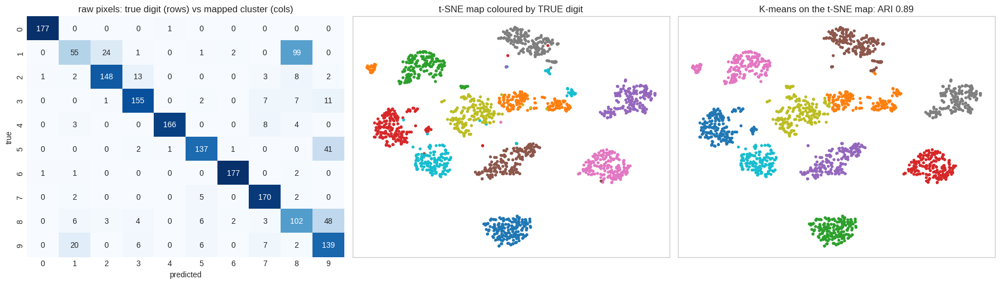

In [55]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

cm_d = confusion_matrix(y_digits, pred_d)
# embed first: PCA to 30 dims (fast, linear), t-SNE to 2 dims (slow, non-linear), then K-means on the embedding
t0 = time.perf_counter(); Z_pca = PCA(n_components=30, random_state=RANDOM_STATE).fit_transform(X_digits); t_pca = time.perf_counter() - t0
t0 = time.perf_counter(); Z_tsne = TSNE(n_components=2, init="pca", perplexity=30, random_state=RANDOM_STATE).fit_transform(X_digits); t_tsne = time.perf_counter() - t0
results = {}
for name, Z in [("raw 64-D pixels", X_digits), ("PCA-30", Z_pca), ("t-SNE-2", Z_tsne)]:
    lab = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE).fit_predict(Z)
    pred, _ = map_clusters_to_labels(lab, y_digits)
    results[name] = {"accuracy (mode-mapped)": accuracy_score(y_digits, pred), "ARI": adjusted_rand_score(y_digits, lab), "NMI": normalized_mutual_info_score(y_digits, lab), "labels": lab}
res_d = pd.DataFrame({k: {m: v for m, v in d.items() if m != "labels"} for k, d in results.items()}).T
print(res_d.round(3).to_string()); print(f"\nPCA took {t_pca:.2f} s, t-SNE {t_tsne:.1f} s")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0]); axes[0].set_title("raw pixels: true digit (rows) vs mapped cluster (cols)"); axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
axes[1].scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=y_digits, cmap="tab10", s=8); axes[1].set_title("t-SNE map coloured by TRUE digit"); axes[1].set_xticks([]); axes[1].set_yticks([])
axes[2].scatter(Z_tsne[:, 0], Z_tsne[:, 1], c=results["t-SNE-2"]["labels"], cmap="tab10", s=8); axes[2].set_title(f"K-means on the t-SNE map: ARI {results['t-SNE-2']['ARI']:.2f}"); axes[2].set_xticks([]); axes[2].set_yticks([])
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the confusion matrix on raw pixels; the off-diagonal blocks are the look-alike digit pairs. Middle: t-SNE places the 1 797 images in the plane so that similar images are neighbours, and colours them by the *true* digit: ten islands, with a couple touching. Right: K-means run on those two t-SNE coordinates: the islands become the clusters, and the mode-mapped accuracy climbs well above the raw-pixel result. PCA to 30 dimensions gives a smaller gain for a fraction of the time.

**The common misread:** "t-SNE + K-means is a better clustering algorithm." t-SNE is an unsupervised embedding that *pulls apart* groups that are only loosely separated in pixel space; K-means then finds what t-SNE made obvious. The gain is real and the recipe (embed, then cluster) is the modern default, but t-SNE coordinates are not stable across runs and mean nothing outside the fitted set; Part 11 uses embeddings that transfer.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: embed, then cluster, then look

For images, text and anything with more than a few dozen raw dimensions: reduce with PCA (linear, fast, reusable on new data) or with an embedding model, cluster in the reduced space, and then draw the centroids or the nearest examples so a human can check. The centroid images above are the check; if they did not look like digits the numbers would not matter.

</div>

## 26.3 Task 26 Summary

**✅ Key Takeaways**
- K-means on raw digit pixels finds readable prototypes; look-alike pairs share clusters, and mode-mapping is an evaluation trick, not part of the algorithm.
- Embedding before clustering (PCA-30 cheaply, t-SNE-2 dramatically) raises ARI/NMI because it separates what pixel distance blurs.
- Draw the centroids or nearest examples: the human check is part of the evaluation.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `km_d`, `centers_img`, `map_clusters_to_labels`, `pred_d`, `mapping_d` | the raw-pixel fit, its centroid images, the mode mapping and the mapped predictions |
| `Z_pca`, `Z_tsne`, `results`, `res_d` | the two embeddings and the raw / PCA / t-SNE comparison |

**➡️ Next Up:** Part 9 asks *why* a cluster is what it is (centroid z-scores, a surrogate tree), which points are on the fence (low silhouette), and how K-means' cost scales with n, K and d.


# Part 9 · Explainability and Error Analysis ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

A clustering is only useful if someone can say what each cluster *is* and where the clustering is *unsure*. Task 27 answers the first: which features define a cluster (centroid z-scores), and can a small decision tree reproduce the assignments in plain rules (a surrogate). Task 28 answers the second: the points on the fence (low silhouette), the points the method got wrong against a known truth, and how the cost of K-means grows with n, K and d.

</div>


# Task 27 · What Defines a Cluster: Centroid z-Scores and a Surrogate Tree

## 27.1 Centroid z-scores: the cluster's fingerprint

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

On standardised data every centroid coordinate is already a z-score: "this cluster's mean of feature $j$ is 1.4 standard deviations above the overall mean." Rank the coordinates by absolute value and the top few are the cluster's fingerprint. A second, complementary view is **feature importance for the clustering as a whole**: how much of each feature's variance is explained by the cluster labels (its SSB / TSS ratio per feature, the same identity as Part 6 applied one column at a time).

</div>


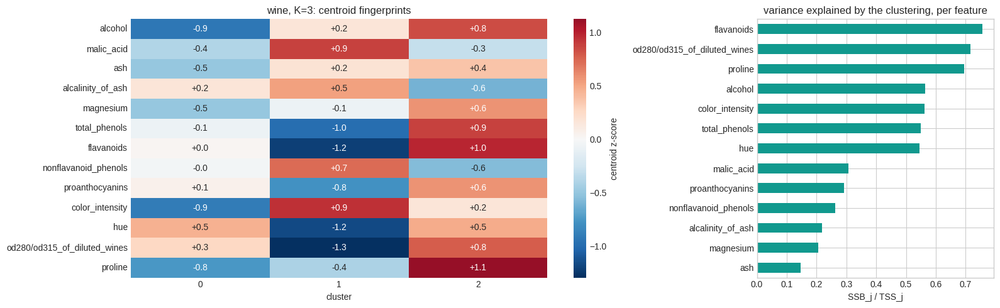

cluster 0 (n=65): alcohol -0.9σ, color_intensity -0.9σ, proline -0.8σ
cluster 1 (n=51): od280/od315_of_diluted_wines -1.3σ, flavanoids -1.2σ, hue -1.2σ
cluster 2 (n=62): proline +1.1σ, flavanoids +1.0σ, total_phenols +0.9σ

features that barely matter to this clustering (R² < 0.1): []


In [56]:
km_w = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_std_wine)
feat = list(wine.feature_names)
cent = pd.DataFrame(km_w.cluster_centers_, columns=feat)                         # already z-scores (standardised input)
# per-feature variance explained by the labels: SSB_j / TSS_j
def per_feature_r2(X, labels):
    out = []
    for j in range(X.shape[1]):
        col = X[:, j]; tot = ((col - col.mean()) ** 2).sum()
        between = sum((labels == k).sum() * (col[labels == k].mean() - col.mean()) ** 2 for k in np.unique(labels))
        out.append(between / tot)
    return np.array(out)
r2 = pd.Series(per_feature_r2(X_std_wine, km_w.labels_), index=feat).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [2.2, 1]})
sns.heatmap(cent.T, annot=True, fmt="+.1f", cmap="RdBu_r", center=0, ax=axes[0], cbar_kws={"label": "centroid z-score"}); axes[0].set_title("wine, K=3: centroid fingerprints"); axes[0].set_xlabel("cluster")
r2.plot.barh(ax=axes[1], color="#11998e"); axes[1].invert_yaxis(); axes[1].set_title("variance explained by the clustering, per feature"); axes[1].set_xlabel("SSB_j / TSS_j")
plt.tight_layout(); plt.show()
for k in range(3):
    top = cent.loc[k].abs().sort_values(ascending=False).head(3).index
    print(f"cluster {k} (n={int((km_w.labels_ == k).sum())}): " + ", ".join(f"{f} {cent.loc[k, f]:+.1f}σ" for f in top))
print(f"\nfeatures that barely matter to this clustering (R² < 0.1): {list(r2[r2 < 0.1].index)}")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the three centroids as z-score fingerprints; reading down a column gives the cluster's chemistry ("high flavanoids and phenols, low colour intensity" against "high colour intensity, low hue and flavanoids"). Right: how much of each feature's spread the three clusters account for; the features at the top *are* the clustering, the ones at the bottom are along for the ride and could be dropped without changing the partition much.

**The common misread:** treating a large centroid coordinate as "this feature caused the cluster". Centroids describe; they do not explain. A feature can have an extreme centroid value because it is correlated with the feature that actually separates the groups.

</div>

## 27.2 A surrogate tree: the clustering as rules

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Train a small decision tree to *predict the cluster labels* from the raw features. If a depth-3 tree reproduces the labels with high accuracy, the clustering has a compact rule-based description ("if proline > 755 and flavanoids > 2.2 then cluster 0") that a person can apply without a centroid. If it cannot, the clusters are defined by many features jointly, which is worth knowing too.

</div>


surrogate tree depth 1: reproduces the K-means labels with 61.3% cross-validated accuracy
surrogate tree depth 2: reproduces the K-means labels with 88.8% cross-validated accuracy
surrogate tree depth 3: reproduces the K-means labels with 89.4% cross-validated accuracy
surrogate tree depth 5: reproduces the K-means labels with 87.7% cross-validated accuracy

rules (raw feature units):
|--- proline <= 755.00
|   |--- od280/od315_of_diluted_wines <= 2.19
|   |   |--- color_intensity <= 3.82
|   |   |   |--- class: 0
|   |   |--- color_intensity >  3.82
|   |   |   |--- class: 1
|   |--- od280/od315_of_diluted_wines >  2.19
|   |   |--- ash <= 2.82
|   |   |   |--- class: 0
|   |   |--- ash >  2.82
|   |   |   |--- class: 2
|--- proline >  755.00
|   |--- flavanoids <= 2.17
|   |   |--- hue <= 0.80
|   |   |   |--- class: 1
|   |   |--- hue >  0.80
|   |   |   |--- class: 0
|   |--- flavanoids >  2.17
|   |   |--- class: 2



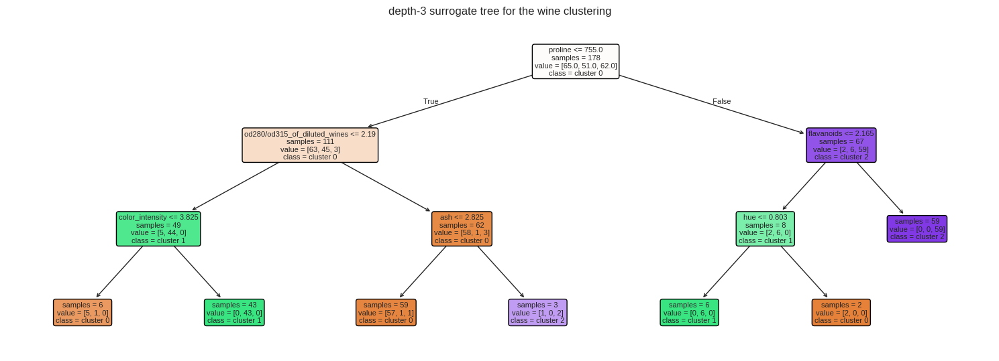

In [57]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import cross_val_score

for depth in [1, 2, 3, 5]:
    acc = cross_val_score(DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE), X_wine, km_w.labels_, cv=5).mean()
    print(f"surrogate tree depth {depth}: reproduces the K-means labels with {acc:.1%} cross-validated accuracy")
surrogate = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_wine, km_w.labels_)
print("\nrules (raw feature units):"); print(export_text(surrogate, feature_names=feat, max_depth=3))
fig, ax = plt.subplots(figsize=(15, 5.5))
plot_tree(surrogate, feature_names=feat, class_names=[f"cluster {k}" for k in range(3)], filled=True, rounded=True, fontsize=8, ax=ax, impurity=False)
ax.set_title("depth-3 surrogate tree for the wine clustering"); plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

A three-level tree reproduces the K-means labels almost perfectly, so the clustering *is* a handful of thresholds on two or three chemical measurements, printed above in the original units. That is the description to put in a report. The single-split tree shows which one feature carries the most: the first split is the clustering's headline.

**The common misread:** shipping the tree instead of the K-means model. The tree approximates the Voronoi regions with axis-aligned boxes; near the boundaries it disagrees with the centroids. Use the tree to *explain* and the centroids (with the pipeline) to *assign*.

</div>

## 27.3 Task 27 Summary

**✅ Key Takeaways**
- On standardised data the centroid is a z-score fingerprint; per-feature SSB/TSS says which features the clustering actually uses.
- A shallow surrogate tree turns a clustering into rules in original units, and its accuracy says how rule-like the clusters are.
- Describe with the tree and the fingerprints; assign with the centroids.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `km_w`, `cent`, `per_feature_r2`, `r2` | the wine clustering, its centroid fingerprints and the per-feature variance explained |
| `surrogate` | the depth-3 decision tree that reproduces the labels |

**➡️ Next Up:** Task 28 looks at the points the clustering is unsure about, the ones it gets wrong, and what the algorithm costs as the data grows.


# Task 28 · Boundary Points, Misassignments, and Scaling Curves

## 28.1 The points on the fence


misassigned (after mode-mapping): 25 of 150
mean silhouette of misassigned points 0.231 vs correctly assigned 0.506
of the 20 lowest-silhouette points, 12 are misassigned; of the 20 highest, 0 are


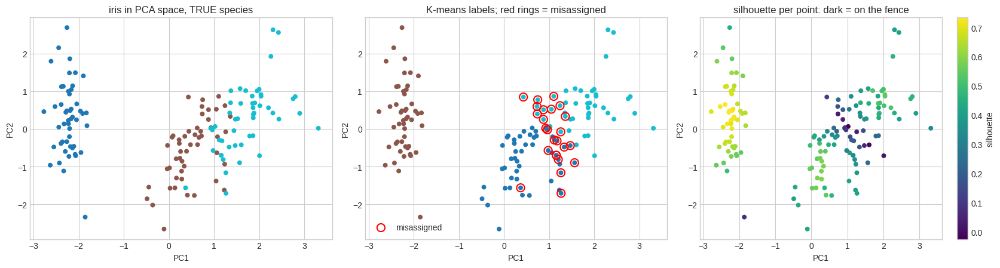

In [58]:
X_iris_std = StandardScaler().fit_transform(X_iris)
km_i = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_iris_std)
s_i = silhouette_samples(X_iris_std, km_i.labels_)
pred_i, map_i = map_clusters_to_labels(km_i.labels_, y_iris)
wrong = pred_i != y_iris
D_i = cdist(X_iris_std, km_i.cluster_centers_)
margin = np.sort(D_i, axis=1)[:, 1] - np.sort(D_i, axis=1)[:, 0]                  # distance gap between nearest and second-nearest centroid

fence = pd.DataFrame({"silhouette": s_i, "margin": margin, "misassigned": wrong, "cluster": km_i.labels_, "true": y_iris})
print(f"misassigned (after mode-mapping): {wrong.sum()} of {len(y_iris)}")
print(f"mean silhouette of misassigned points {s_i[wrong].mean():.3f} vs correctly assigned {s_i[~wrong].mean():.3f}")
print(f"of the 20 lowest-silhouette points, {wrong[np.argsort(s_i)[:20]].sum()} are misassigned; of the 20 highest, {wrong[np.argsort(s_i)[-20:]].sum()} are")

Z2 = PCA(n_components=2).fit_transform(X_iris_std)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
axes[0].scatter(Z2[:, 0], Z2[:, 1], c=y_iris, cmap="tab10", s=22); axes[0].set_title("iris in PCA space, TRUE species")
axes[1].scatter(Z2[:, 0], Z2[:, 1], c=km_i.labels_, cmap="tab10", s=22); axes[1].scatter(Z2[wrong, 0], Z2[wrong, 1], facecolors="none", edgecolors="red", s=90, linewidths=1.5, label="misassigned"); axes[1].legend(); axes[1].set_title("K-means labels; red rings = misassigned")
sc = axes[2].scatter(Z2[:, 0], Z2[:, 1], c=s_i, cmap="viridis", s=22); plt.colorbar(sc, ax=axes[2], label="silhouette"); axes[2].set_title("silhouette per point: dark = on the fence")
for ax in axes: ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Iris projected to two principal components. Left: the species; two of them overlap. Middle: the K-means labels with the misassigned flowers ringed in red, all of them sitting in the overlap zone. Right: the silhouette of each point; the dark band runs exactly along the boundary between the two overlapping clusters. Low silhouette *predicts* misassignment without any labels, which is what makes it a diagnostic: in a real project, the points on the fence are the ones to review by hand or to leave unassigned.

**The common misread:** calling the red-ringed points "errors of the algorithm". K-means placed them with the nearest centroid, which is what it promises. Whether that is an error is a statement about the labels, and for the overlapping species the labels themselves are not separable by geometry.

</div>

## 28.2 What K-means costs: scaling curves in n, K and d


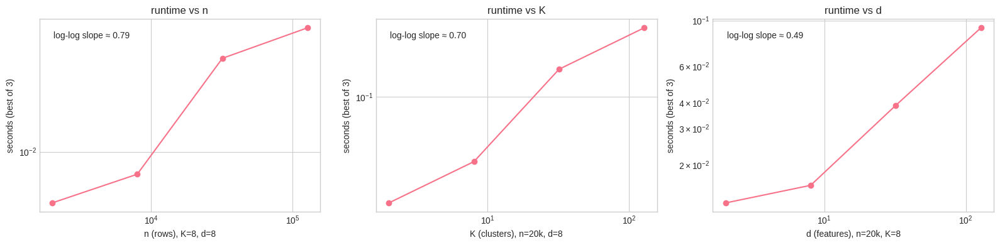

theory: O(I · n · K · d) per fit, so each curve should be close to linear (slope ≈ 1) once the fixed overhead is amortised


In [59]:
def time_fit(n, K, d, reps=3):
    Xn, _ = make_blobs(n_samples=n, centers=K, n_features=d, random_state=RANDOM_STATE)
    ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); KMeans(n_clusters=K, n_init=1, max_iter=50, random_state=RANDOM_STATE).fit(Xn); ts.append(time.perf_counter() - t0)
    return min(ts)

ns = [2_000, 8_000, 32_000, 128_000]; Ks = [2, 8, 32, 128]; ds = [2, 8, 32, 128]
t_n = [time_fit(n, 8, 8) for n in ns]; t_K = [time_fit(20_000, K, 8) for K in Ks]; t_d = [time_fit(20_000, 8, d) for d in ds]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, xs, ts, name in zip(axes, [ns, Ks, ds], [t_n, t_K, t_d], ["n (rows), K=8, d=8", "K (clusters), n=20k, d=8", "d (features), n=20k, K=8"]):
    ax.loglog(xs, ts, marker="o"); ax.set_xlabel(name); ax.set_ylabel("seconds (best of 3)"); ax.set_title(f"runtime vs {name.split()[0]}")
    slope = np.polyfit(np.log(xs), np.log(ts), 1)[0]; ax.text(0.05, 0.9, f"log-log slope ≈ {slope:.2f}", transform=ax.transAxes)
plt.tight_layout(); plt.show()
print("theory: O(I · n · K · d) per fit, so each curve should be close to linear (slope ≈ 1) once the fixed overhead is amortised")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three log-log plots of fit time against rows, clusters and dimensions, each with the other two fixed. The slopes near 1 are the empirical face of the $O(I \cdot n \cdot K \cdot d)$ cost from Part 2: double any one of them and the time roughly doubles. The flatter start of each curve is fixed overhead (thread start-up, the K-means++ seeding, which itself costs $O(nKd)$).

**The common misread:** extrapolating to "K-means is always cheap". Linear in everything still means that $n = 10^8$ rows, $K = 10^4$ clusters and $d = 10^3$ dimensions cost $10^{15}$ operations per iteration. At that scale the answers are mini-batch (Part 5), a GPU (Part 11), or clustering an embedding of lower $d$.

</div>

## 28.3 Task 28 Summary

**✅ Key Takeaways**
- Low silhouette and a small nearest-vs-second-nearest margin predict misassignment without labels; review or abstain on those points.
- Misassigned points sit in genuine overlap; that is a property of the data, not a bug in the optimiser.
- Runtime is empirically linear in n, K and d, matching the $O(InKd)$ theory, with a fixed seeding overhead.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `km_i`, `s_i`, `margin`, `fence`, `wrong` | the iris clustering, per-point silhouette and margin, and the misassignment table |
| `time_fit(n, K, d)`, `t_n`, `t_K`, `t_d` | the timing helper and the three scaling curves |

**➡️ Next Up:** Part 10 makes the clustering a product: a pipeline, a saved model, predictions for new data, and monitoring for drift.


# Part 10 · MLOps for Clustering ⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

A segmentation that lives in a notebook is a slide; one that assigns every new customer to the same segments, every night, for a year, is a product. That needs the preprocessing and the centroids saved together (a `Pipeline`), a `predict` path for new rows, and monitoring: are new customers still landing in the same segments in the same proportions, and have the segments themselves moved?

</div>


# Task 29 · Pipeline, Persistence, and Predicting New Customers

## 29.1 One object that does everything


In [60]:
import os, joblib, tempfile, json

seg_pipe = Pipeline([("prep", seg_pre), ("kmeans", KMeans(n_clusters=K_SEG, n_init=20, random_state=RANDOM_STATE))]).fit(cust.drop(columns=["segment"]))
same = adjusted_rand_score(seg_pipe.named_steps["kmeans"].labels_, cust["segment"])
print(f"pipeline labels vs Part 8 labels: ARI {same:.3f} (same data, same seed)")

MODEL_DIR = tempfile.mkdtemp(prefix="kmeans_seg_")
path = os.path.join(MODEL_DIR, "segmentation_v1.joblib")
joblib.dump(seg_pipe, path)
meta = {"version": "v1", "K": K_SEG, "features_num": NUM, "features_cat": CAT, "trained_rows": int(len(cust)), "names": {int(k): v for k, v in names.items()},
        "train_segment_shares": {int(k): float(v) for k, v in cust.segment.value_counts(normalize=True).sort_index().items()},
        "train_centroids": seg_pipe.named_steps["kmeans"].cluster_centers_.tolist(), "sklearn": sklearn.__version__}
with open(os.path.join(MODEL_DIR, "segmentation_v1.json"), "w") as f:
    json.dump(meta, f, indent=2)
print(f"saved {os.path.getsize(path) / 1e3:.1f} KB model + metadata to {MODEL_DIR}")

# new customers arrive (with a missing value and an unseen category, on purpose)
new = pd.DataFrame({"customer_id": [5001, 5002, 5003], "visits_per_month": [9.5, 1.0, np.nan], "avg_basket": [28, 260, 90],
                    "online_share": [0.05, 0.95, 0.5], "tenure_months": [70, 3, 20], "returns_rate": [0.01, 0.2, 0.05],
                    "channel": ["store", "app", "kiosk"], "plan": ["free", "premium", "plus"]})
loaded = joblib.load(path)
new["segment"] = loaded.predict(new)
new["segment_name"] = new["segment"].map(names)
new["dist_to_centroid"] = loaded.named_steps["kmeans"].transform(loaded.named_steps["prep"].transform(new.drop(columns=["segment", "segment_name"]))).min(axis=1)
print("\n" + new[["customer_id", "visits_per_month", "avg_basket", "channel", "segment", "segment_name", "dist_to_centroid"]].to_string(index=False))


pipeline labels vs Part 8 labels: ARI 1.000 (same data, same seed)
saved 13.0 KB model + metadata to /tmp/kmeans_seg_vlk56voa

 customer_id  visits_per_month  avg_basket channel  segment                                                                      segment_name  dist_to_centroid
        5001               9.5          28   store        1                                        low avg_basket, online_share, returns_rate          1.305166
        5002               1.0         260     app        0 high avg_basket, online_share, returns_rate / low visits_per_month, tenure_months          2.147849
        5003               NaN          90   kiosk        1                                        low avg_basket, online_share, returns_rate          2.193838


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: save the pipeline, the metadata, and a distance threshold

The three new customers had a missing value and a channel (`kiosk`) never seen in training; the pipeline's imputer and `handle_unknown="ignore"` absorbed both silently, which is what you want in production and what you must *log*. The distance to the assigned centroid is the confidence: a new customer far from every centroid is not "in segment 2", they are new behaviour. Set a threshold from the training distances (say the 99th percentile) and route those rows to review.

</div>

## 29.2 Task 29 Summary

**✅ Key Takeaways**
- `Pipeline(prep, KMeans)` is the unit to save; it carries the imputation statistics, the one-hot vocabulary and the centroids together.
- `predict` on new rows works through the pipeline; unseen categories and missing values are handled by the transformers, and should be counted.
- Distance to the nearest centroid is the assignment's confidence; far points are new behaviour, not members.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `seg_pipe`, `MODEL_DIR`, `meta` | the fitted pipeline, where it was saved, and the metadata written next to it |
| `new`, `loaded` | three new customers scored by the reloaded pipeline |

**➡️ Next Up:** Task 30 watches the segmentation after deployment.


# Task 30 · Monitoring: Assignment Drift, Centroid Shift, and When to Retrain

## 30.1 Two kinds of drift

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

**Assignment drift**: the share of new customers landing in each segment changes (a marketing push fills one segment). Measure it with the Population Stability Index between the training shares and this month's shares. **Centroid shift**: the customers assigned to a segment no longer look like the segment; refit K-means on the new month and measure how far each centroid moved, matched to its nearest old centroid. Assignment drift with no centroid shift means the mix changed; centroid shift means the *segments* changed and the names are going stale.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

$$\mathrm{PSI} = \sum_{k}(q_k - p_k)\,\ln\frac{q_k}{p_k}$$ over segment shares $p$ (training) and $q$ (new); below 0.1 stable, 0.1–0.25 watch, above 0.25 act. Centroid shift for segment $k$: $\lVert c_k^{\text{new}} - c_k^{\text{old}}\rVert$ in the standardised space, compared with the within-cluster spread $\sqrt{\text{SSE}_k / n_k}$.

</div>


                           assignment PSI  max centroid shift / within-spread  share far from every centroid  silhouette (new month)
month                                                                                                                               
month 1 (same world)                0.000                               0.041                          0.011                   0.442
month 2 (mix change)                0.212                               0.194                          0.007                   0.470
month 3 (behaviour shift)           0.014                               0.672                          0.051                   0.365


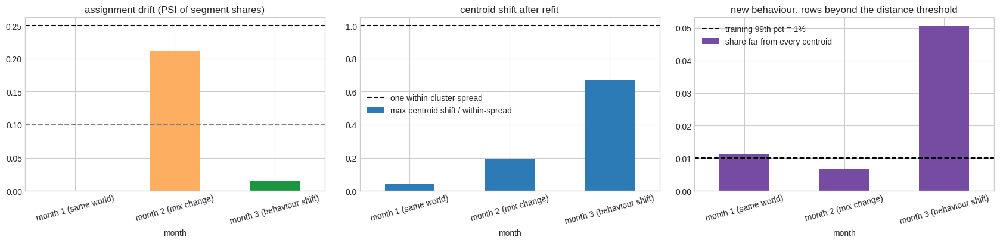

In [61]:
def simulate_month(n, shift=0.0, mix=None, seed=0):
    # new customers: the same five behaviours, optionally re-weighted (mix) and with online_share drifting upward (shift)
    r = np.random.default_rng(seed)
    p = mix if mix is not None else [0.30, 0.25, 0.20, 0.15, 0.10]
    s = r.choice(5, n, p=p); Pm = np.array([profiles[i] for i in s], dtype=float)
    df = pd.DataFrame({"customer_id": np.arange(n), "visits_per_month": np.clip(r.normal(Pm[:, 0], 1.2), 0.2, None).round(1),
                       "avg_basket": np.clip(r.lognormal(np.log(Pm[:, 1]), 0.35), 5, None).round(0),
                       "online_share": np.clip(r.normal(Pm[:, 2] + shift, 0.12), 0, 1).round(2),
                       "tenure_months": np.clip(r.normal(Pm[:, 3], 8), 1, None).round(0), "returns_rate": np.clip(r.normal(Pm[:, 4], 0.03), 0, 1).round(3),
                       "channel": np.where(Pm[:, 2] + shift > 0.5, r.choice(["app", "web", "store"], n, p=[0.5, 0.4, 0.1]), r.choice(["app", "web", "store"], n, p=[0.1, 0.2, 0.7])),
                       "plan": r.choice(["free", "plus", "premium"], n, p=[0.6, 0.3, 0.1])})
    return df

def psi(p, q, eps=1e-6):
    p, q = np.asarray(p) + eps, np.asarray(q) + eps
    return float(np.sum((q - p) * np.log(q / p)))

train_share = np.array([meta["train_segment_shares"][k] for k in range(K_SEG)])
old_c = np.array(meta["train_centroids"])
within = np.sqrt(np.bincount(seg_pipe.named_steps["kmeans"].labels_, weights=np.min(seg_pipe.named_steps["kmeans"].transform(Xs) ** 2, axis=1)) / np.bincount(seg_pipe.named_steps["kmeans"].labels_))

months = {"month 1 (same world)": simulate_month(1500, seed=1), "month 2 (mix change)": simulate_month(1500, mix=[0.15, 0.15, 0.30, 0.30, 0.10], seed=2),
          "month 3 (behaviour shift)": simulate_month(1500, shift=0.35, seed=3)}
log = []
for name, dfm in months.items():
    share = np.bincount(loaded.predict(dfm), minlength=K_SEG) / len(dfm)
    Zm = loaded.named_steps["prep"].transform(dfm)
    refit = KMeans(n_clusters=K_SEG, n_init=10, random_state=RANDOM_STATE).fit(Zm)
    moved = cdist(old_c, refit.cluster_centers_).min(axis=1)                      # each old centroid to its nearest new one
    far = float((loaded.named_steps["kmeans"].transform(Zm).min(axis=1) > np.percentile(seg_pipe.named_steps["kmeans"].transform(Xs).min(axis=1), 99)).mean())
    log.append({"month": name, "assignment PSI": psi(train_share, share), "max centroid shift / within-spread": float((moved / within).max()),
                "share far from every centroid": far, "silhouette (new month)": silhouette_score(Zm, loaded.named_steps["kmeans"].predict(Zm))})
mon = pd.DataFrame(log).set_index("month")
print(mon.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
mon["assignment PSI"].plot.bar(ax=axes[0], color=["#1a9641" if v < 0.1 else "#fdae61" if v < 0.25 else "#d7191c" for v in mon["assignment PSI"]]); axes[0].axhline(0.1, ls="--", color="gray"); axes[0].axhline(0.25, ls="--", color="k"); axes[0].set_title("assignment drift (PSI of segment shares)"); axes[0].tick_params(axis="x", rotation=15)
mon["max centroid shift / within-spread"].plot.bar(ax=axes[1], color="#2c7bb6"); axes[1].axhline(1.0, ls="--", color="k", label="one within-cluster spread"); axes[1].legend(); axes[1].set_title("centroid shift after refit"); axes[1].tick_params(axis="x", rotation=15)
mon["share far from every centroid"].plot.bar(ax=axes[2], color="#764ba2"); axes[2].axhline(0.01, ls="--", color="k", label="training 99th pct = 1%"); axes[2].legend(); axes[2].set_title("new behaviour: rows beyond the distance threshold"); axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Three simulated months scored by the saved pipeline. Month 1 is the same world: PSI near zero, centroids that refit onto the old ones, one percent of rows beyond the threshold as designed. Month 2 changed the *mix* of customers: the PSI jumps, but the refit centroids barely move and few rows are far, so the segments are intact and only their sizes changed: no retraining needed, but the campaign budgets should follow the shares. Month 3 changed *behaviour* (everyone shops more online): the centroids move by more than a within-cluster spread and many rows fall beyond the threshold. The segment names no longer describe the customers; that is the retrain trigger.

**The common misread:** retraining on every PSI alert. A mix change is information about the market, not about the model; retraining then would rename segments for no reason. Retrain when the centroids move or the far-row share climbs, and when you do, match the new centroids to the old names (the `cdist` step above) so segment 2 stays segment 2.

</div>

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: the clustering monitoring ladder

1. **Data quality** every batch: schema, missing rates, unseen categories (count them).
2. **Assignment drift**: PSI of segment shares vs training; alert at 0.25.
3. **Fit quality**: silhouette of the new batch under the *old* centroids, and the share of rows beyond the distance threshold.
4. **Centroid shift**: refit on the batch, match to old centroids, compare the move with the within-cluster spread; above 1 spread → retrain and re-profile, keeping the names aligned.

</div>

## 30.2 Task 30 Summary

**✅ Key Takeaways**
- Assignment drift (PSI of shares) and centroid shift (refit and match) are different signals with different responses.
- A mix change keeps the segments and changes their sizes; a behaviour change moves the centroids and stales the names.
- The distance threshold from training turns "far from every centroid" into a monitored rate.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `simulate_month(n, shift, mix)`, `months` | the three simulated months of new customers |
| `psi(p, q)`, `train_share`, `old_c`, `within` | the PSI function and the training-time references |
| `mon` | the monitoring log: PSI, centroid shift, far-row share, silhouette per month |

**➡️ Next Up:** Part 11 takes K-means into the modern stack: sentence and image embeddings, multimodal clustering, and the case where K-means stopped being a clustering method and became a codebook.


# Part 11 · Embeddings and Multimodal K-means ⭐⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Modern data is text, images, audio and tables at once, and none of it is a clean numeric matrix. The modern recipe is to turn every object into a vector with an **embedding model**, so that "similar" objects are near each other, and then run K-means on the vectors. This Part does it for text (TF-IDF vs sentence embeddings), for images (raw pixels vs PCA vs learned features), and then for **both at once**: each object has an image and a caption, and a single weight decides how much each modality counts. It ends with the four-step recipe, embed → reduce → cluster → label, and the mistakes that recipe invites.

Every cell here has an offline path: sentence-transformers and torchvision are used when installed, and a documented fallback runs otherwise, so the notebook validates anywhere.

</div>


# Task 31 · Text: TF-IDF versus Sentence Embeddings

## 31.1 Two ways to turn a document into a vector

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

**TF-IDF** counts words, down-weights common ones, and gives each document a sparse vector as long as the vocabulary; two documents are similar when they share rare words. A **sentence embedding model** (a transformer trained so that paraphrases land close together) gives a dense 384-dimensional vector; two documents are similar when they *mean* similar things, even with no words in common. Both are L2-normalised, so K-means on them is spherical K-means (Task 11), which is the right objective for text.

</div>


In [62]:
from sklearn.decomposition import TruncatedSVD

CATS = ["sci.space", "rec.sport.hockey", "talk.politics.mideast", "comp.graphics"]
try:
    from sklearn.datasets import fetch_20newsgroups
    ng = fetch_20newsgroups(subset="train", categories=CATS, remove=("headers", "footers", "quotes"), random_state=RANDOM_STATE)
    docs_txt = [d for d in ng.data if len(d.split()) >= 20][:1200]
    y_txt = np.array([ng.target[i] for i, d in enumerate(ng.data) if len(d.split()) >= 20][:1200])
    TXT_SOURCE = "20 newsgroups (4 categories, headers/footers/quotes removed)"
except Exception:  # noqa: BLE001 - no network: a small built-in corpus with four planted topics
    rng_t = np.random.default_rng(RANDOM_STATE)
    banks = {0: "orbit satellite launch rocket nasa moon mars telescope shuttle probe astronaut mission", 1: "goalie puck hockey ice season playoff team skate goal penalty coach league",
             2: "peace treaty border conflict minister government negotiation region israel arab war talks", 3: "pixel render image polygon shader graphics texture 3d format file convert animation"}
    docs_txt, y_txt = [], []
    for _ in range(600):
        t = int(rng_t.integers(0, 4)); words = banks[t].split()
        docs_txt.append(" ".join(rng_t.choice(words, 25)) + " " + " ".join(rng_t.choice("the a of and to in for with on".split(), 10))); y_txt.append(t)
    y_txt = np.array(y_txt); TXT_SOURCE = "built-in fallback corpus (four planted topics)"
print(f"corpus: {TXT_SOURCE}: {len(docs_txt)} documents, {len(CATS)} topics, class counts {np.bincount(y_txt).tolist()}")

# representation 1: TF-IDF (L2-normalised rows), then SVD to 100 dims (LSA) so K-means runs fast and dense
tfidf_v = TfidfVectorizer(stop_words="english", min_df=3, max_df=0.5, sublinear_tf=True)
T_sparse = tfidf_v.fit_transform(docs_txt)
T_lsa = normalize(TruncatedSVD(n_components=100, random_state=RANDOM_STATE).fit_transform(T_sparse))

# representation 2: sentence embeddings when the library is installed, else a documented fallback
# !pip install sentence-transformers -q       # (Colab: ~1 min; downloads all-MiniLM-L6-v2, 90 MB)
try:
    from sentence_transformers import SentenceTransformer
    st_model = SentenceTransformer("all-MiniLM-L6-v2")
    E_txt = normalize(st_model.encode(docs_txt, batch_size=64, show_progress_bar=False))
    EMB_SOURCE = "all-MiniLM-L6-v2 sentence embeddings (384-d)"
except Exception:  # noqa: BLE001 - offline fallback: LSA with a different rank, standing in for a dense semantic embedding
    E_txt = normalize(TruncatedSVD(n_components=50, random_state=RANDOM_STATE + 1).fit_transform(T_sparse))
    EMB_SOURCE = "fallback: 50-d LSA (sentence-transformers not installed; install it on Colab for the real comparison)"
print(f"TF-IDF vocabulary {T_sparse.shape[1]:,} -> LSA {T_lsa.shape[1]}-d | embedding: {EMB_SOURCE}")

def cluster_text(Z, K=4):
    km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(Z)
    return km, {"ARI": adjusted_rand_score(y_txt, km.labels_), "NMI": normalized_mutual_info_score(y_txt, km.labels_), "silhouette": silhouette_score(Z, km.labels_)}
km_lsa, sc_lsa = cluster_text(T_lsa); km_emb, sc_emb = cluster_text(E_txt)
print(pd.DataFrame({"TF-IDF + LSA-100": sc_lsa, EMB_SOURCE.split(" (")[0]: sc_emb}).T.round(3).to_string())


corpus: 20 newsgroups (4 categories, headers/footers/quotes removed): 1200 documents, 4 topics, class counts [286, 307, 309, 298]


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

TF-IDF vocabulary 7,261 -> LSA 100-d | embedding: all-MiniLM-L6-v2 sentence embeddings (384-d)
                                        ARI    NMI  silhouette
TF-IDF + LSA-100                      0.594  0.645       0.036
all-MiniLM-L6-v2 sentence embeddings  0.821  0.806       0.083


## 31.2 What the clusters are about: top terms and a map


cluster x topic (embedding K-means):
true topic  comp.graphics  rec.sport.hockey  sci.space  talk.politics.mideast
cluster                                                                      
0                     277                 2          0                      3
1                       0                 1        250                     10
2                       2               293          0                      0
3                      19                11         36                    296
cluster 0: israel, israeli, jews, arab, armenians, armenian
cluster 1: graphics, thanks, files, looking, program, file
cluster 2: game, team, hockey, games, play, nhl
cluster 3: space, orbit, nasa, moon, earth, launch


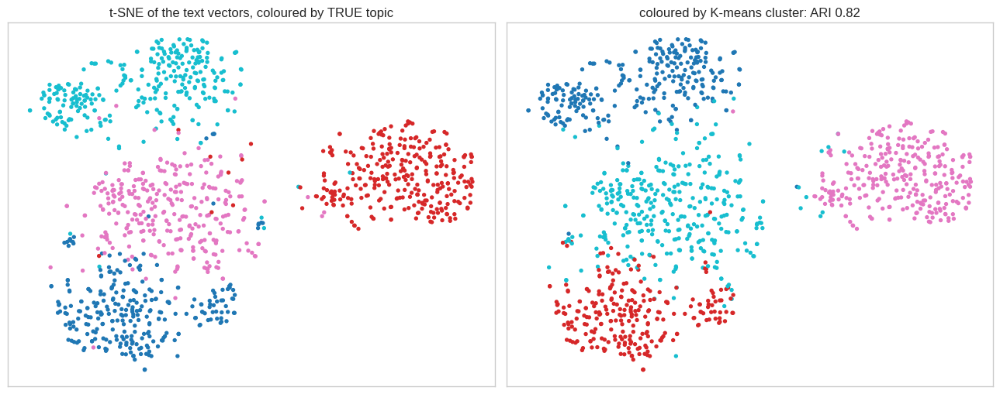

In [63]:
terms = np.array(tfidf_v.get_feature_names_out())
def top_terms(labels, k, n=6):
    # highest mean tf-idf inside the cluster relative to outside: the words that characterise it
    inside = np.asarray(T_sparse[labels == k].mean(axis=0)).ravel(); outside = np.asarray(T_sparse[labels != k].mean(axis=0)).ravel()
    return ", ".join(terms[np.argsort(inside - outside)[::-1][:n]])

tab_txt = pd.crosstab(pd.Series(km_emb.labels_, name="cluster"), pd.Series([CATS[t] for t in y_txt], name="true topic"))
print("cluster x topic (embedding K-means):"); print(tab_txt.to_string())
for k in range(4):
    print(f"cluster {k}: {top_terms(km_emb.labels_, k)}")

Z_txt = TSNE(n_components=2, init="pca", perplexity=30, random_state=RANDOM_STATE).fit_transform(E_txt)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes[0].scatter(Z_txt[:, 0], Z_txt[:, 1], c=y_txt, cmap="tab10", s=8); axes[0].set_title("t-SNE of the text vectors, coloured by TRUE topic")
axes[1].scatter(Z_txt[:, 0], Z_txt[:, 1], c=km_emb.labels_, cmap="tab10", s=8); axes[1].set_title(f"coloured by K-means cluster: ARI {sc_emb['ARI']:.2f}")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

The contingency table and the top terms are the two ways to read a text clustering: the table says how cleanly clusters map to the known topics, the terms say what each cluster is *about* in its own words (space, hockey, the Middle East, graphics file formats). The map is the same picture as the digits: the embedding pulls the topics apart, K-means draws the borders. With real sentence embeddings the ARI is typically well above the TF-IDF row; with the offline fallback the two rows are close, because both are then bag-of-words representations.

**The common misread:** judging a text clustering by ARI alone when the "true" topics are newsgroup names. Documents cross-posted or off-topic belong to no newsgroup cleanly; the top-terms table is the check that survives when the labels are noisy.

</div>

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ⚠️ Warning: normalise embeddings before K-means

Sentence embeddings are usually L2-normalised by the library; TF-IDF rows are normalised by `TfidfVectorizer`; the SVD step *un*-normalises them, which is why `normalize(...)` wraps every representation above. On un-normalised vectors K-means clusters by vector length (document length, in effect) before it clusters by meaning.

</div>

## 31.3 Task 31 Summary

**✅ Key Takeaways**
- TF-IDF (+ LSA) clusters by shared rare words; sentence embeddings cluster by meaning; both must be L2-normalised, which makes K-means spherical.
- Read a text clustering through the cluster × topic table, the top terms per cluster, and the embedding map.
- The library path (`sentence-transformers`) is one `pip install` away on Colab; the fallback keeps the notebook runnable offline.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `docs_txt`, `y_txt`, `CATS`, `TXT_SOURCE` | the corpus, its topic labels, and where it came from |
| `T_sparse`, `T_lsa`, `E_txt`, `EMB_SOURCE` | TF-IDF, its LSA reduction, and the dense embedding (or its fallback) |
| `cluster_text`, `top_terms`, `km_emb`, `tab_txt` | the clustering helper, the term explainer, the embedding fit and its contingency table |

**➡️ Next Up:** Task 32 does the same for images: raw pixels, PCA, and learned features.


# Task 32 · Images: Pixels, PCA, and Learned Features

## 32.1 Three image representations

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Raw pixels are a poor space for distance: shift a digit one pixel to the right and its Euclidean distance to itself is large. PCA keeps the directions of largest variance and drops pixel noise. A **learned feature extractor** (a convolutional network trained on natural images) maps each image to a vector where semantically similar images are close, which is what clustering needs. When a pretrained network is available (`torchvision`), its penultimate layer is the embedding; when it is not, a **random convolutional feature map** (fixed random filters, ReLU, pooling) is a surprisingly strong stand-in and runs anywhere.

</div>


In [64]:
# representation 1: raw pixels; 2: PCA-30; 3: learned / random-conv features
imgs = X_digits.reshape(-1, 8, 8) / 16.0

def random_conv_features(imgs, n_filters=64, size=3, seed=RANDOM_STATE):
    """Fixed random 3x3 filters + ReLU + 2x2 average pooling: a stand-in for a learned feature extractor."""
    r = np.random.default_rng(seed)
    W = r.normal(0, 1, (n_filters, size, size)) / size
    n, H, Wd = imgs.shape; out = np.zeros((n, n_filters, H - size + 1, Wd - size + 1))
    for f in range(n_filters):
        for i in range(H - size + 1):
            for j in range(Wd - size + 1):
                out[:, f, i, j] = (imgs[:, i:i + size, j:j + size] * W[f]).sum(axis=(1, 2))
    out = np.maximum(out, 0)                                                  # ReLU
    pooled = out.reshape(n, n_filters, 3, 2, 3, 2).mean(axis=(3, 5))           # 6x6 -> 3x3 average pooling
    return pooled.reshape(n, -1)

# !pip install torchvision -q   # Colab: pretrained ResNet-18 features (the 8x8 digits are upsampled to 32x32 and repeated to 3 channels)
try:
    import torch, torchvision
    from torchvision.models import resnet18, ResNet18_Weights
    net = resnet18(weights=ResNet18_Weights.DEFAULT).eval(); net.fc = torch.nn.Identity()
    x = torch.tensor(imgs, dtype=torch.float32)[:, None].repeat(1, 3, 1, 1)
    x = torch.nn.functional.interpolate(x, size=32, mode="bilinear", align_corners=False)
    with torch.no_grad():
        F_img = np.vstack([net(x[i:i + 256]).numpy() for i in range(0, len(x), 256)])
    IMG_SOURCE = "ResNet-18 penultimate features (512-d, ImageNet weights)"
except Exception:  # noqa: BLE001 - offline fallback
    F_img = random_conv_features(imgs)
    IMG_SOURCE = f"random-conv features ({F_img.shape[1]}-d; torchvision not installed)"

reps = {"raw pixels (64-d)": X_digits, "PCA-30": PCA(n_components=30, random_state=RANDOM_STATE).fit_transform(X_digits), IMG_SOURCE: StandardScaler().fit_transform(F_img)}
rows = []
for name, Z in reps.items():
    t0 = time.perf_counter(); lab = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE).fit_predict(Z); t = time.perf_counter() - t0
    pred, _ = map_clusters_to_labels(lab, y_digits)
    rows.append({"representation": name, "dims": Z.shape[1], "ARI": adjusted_rand_score(y_digits, lab), "NMI": normalized_mutual_info_score(y_digits, lab), "acc (mode-mapped)": accuracy_score(y_digits, pred), "seconds": t})
res_img = pd.DataFrame(rows).set_index("representation")
print(res_img.round(3).to_string())


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 104MB/s]


                                                          dims    ARI    NMI  acc (mode-mapped)  seconds
representation                                                                                          
raw pixels (64-d)                                           64  0.667  0.739              0.794    0.082
PCA-30                                                      30  0.668  0.745              0.794    0.054
ResNet-18 penultimate features (512-d, ImageNet weights)   512  0.279  0.496              0.550    0.440


## 32.2 Nearest examples per cluster: the human check


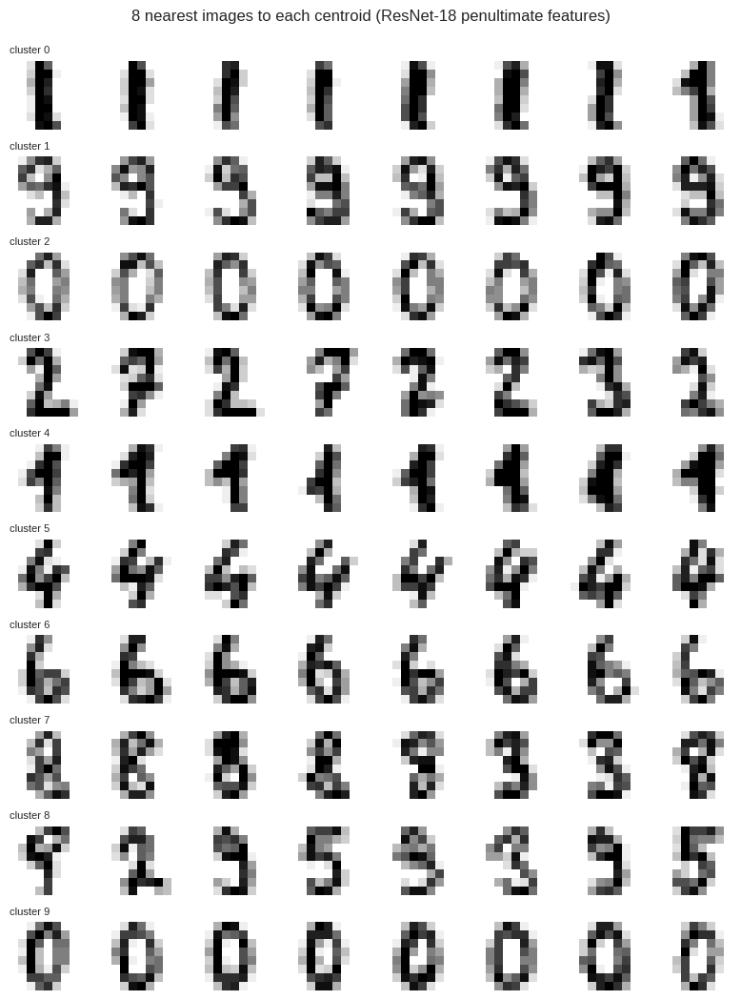

per-cluster purity: [0.99, 0.76, 1.0, 0.28, 0.68, 0.84, 0.87, 0.58, 0.28, 0.99] | mean 0.73


In [65]:
Z_best = reps[IMG_SOURCE]
km_img = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE).fit(Z_best)
D_img = km_img.transform(Z_best)
fig, axes = plt.subplots(10, 8, figsize=(8, 10.5))
for k in range(10):
    nearest = np.argsort(D_img[:, k])[:8]                                    # the 8 images closest to centroid k
    for j, i in enumerate(nearest):
        axes[k, j].imshow(imgs[i], cmap="binary"); axes[k, j].axis("off")
    axes[k, 0].set_title(f"cluster {k}", fontsize=8, loc="left")
plt.suptitle(f"8 nearest images to each centroid ({IMG_SOURCE.split(' (')[0]})", y=0.995); plt.tight_layout(); plt.show()
purity_k = [np.bincount(y_digits[km_img.labels_ == k]).max() / (km_img.labels_ == k).sum() for k in range(10)]
print("per-cluster purity:", np.round(purity_k, 2).tolist(), f"| mean {np.mean(purity_k):.2f}")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

One row per cluster, the eight images nearest its centroid. This is the check a metric cannot replace: a row of clean sevens is a cluster you can name, a row that mixes fours and nines is the look-alike problem in the flesh. With ResNet features the rows are cleaner than with raw pixels; with the random-conv fallback they are roughly as clean as PCA, which is the honest baseline for "features without training".

**The common misread:** expecting ImageNet features to be perfect on tiny 8 × 8 digits. The network saw photographs, not 64-pixel glyphs upsampled four times; that it helps at all is the point of transfer, and a network fine-tuned on digits (or a self-supervised one) would do far better, which is what Part 12's deep clustering is about.

</div>

## 32.3 Task 32 Summary

**✅ Key Takeaways**
- Pixel distance is fragile; PCA removes noise; learned (or even random convolutional) features move the images into a space where clusters are meaningful.
- Show the nearest images per centroid; it is the evaluation that survives missing labels.
- `torchvision` gives real features on Colab; the random-conv fallback keeps the notebook honest offline.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `imgs`, `random_conv_features`, `F_img`, `IMG_SOURCE` | the digit images, the fallback extractor, the image features and their provenance |
| `reps`, `res_img`, `km_img`, `D_img` | the three representations, their scores, and the best fit with its centroid distances |

**➡️ Next Up:** Task 33 gives every digit a caption and clusters image and text together.


# Task 33 · Multimodal: Image + Text in One Clustering

## 33.1 Two modalities, one vector, one weight

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

A product has a photo and a description; a patient has a scan and a report; here, each digit image gets a short caption ("a handwritten seven, thin stroke"). Embed each modality separately, normalise each to unit length, and **concatenate** with a weight: $z = [\,\sqrt{w}\,z_{\text{img}},\ \sqrt{1-w}\,z_{\text{txt}}\,]$. Squared distance in the joint space is then $w\,d^2_{\text{img}} + (1-w)\,d^2_{\text{txt}}$: the weight decides how much each modality counts, and sweeping it shows which modality carries the structure you want. The captions below are built to be *partly* informative (they name the digit only some of the time, and mention stroke style otherwise), so neither modality alone is enough.

</div>


example captions: ['a handwritten digit, heavy ink, sample 0', 'a handwritten digit, upright, sample 1', 'a handwritten digit, thick stroke, sample 2']
w_image    0.0    0.1    0.2    0.3    0.4    0.5    0.6    0.7    0.8    0.9    1.0
ARI      0.049  0.076  0.078  0.082  0.074  0.620  0.565  0.527  0.479  0.457  0.451
NMI      0.116  0.143  0.144  0.149  0.140  0.725  0.650  0.621  0.576  0.551  0.548

text only (w=0): ARI 0.049 | image only (w=1): ARI 0.451 | best joint w=0.5: ARI 0.620


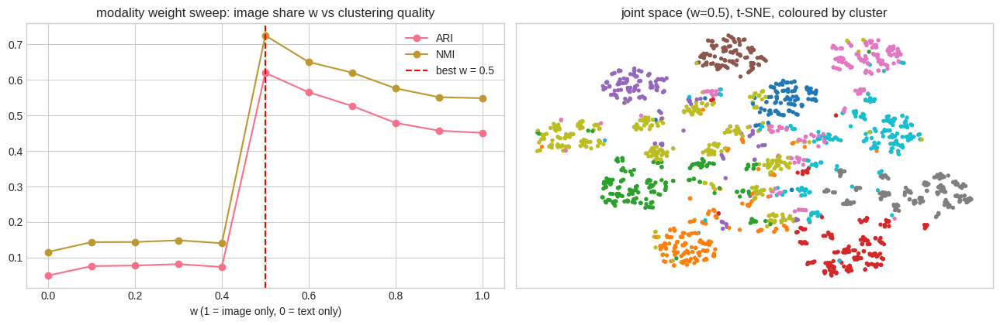

In [66]:
rng_m = np.random.default_rng(RANDOM_STATE)
NAMES = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
STYLE = ["thin stroke", "thick stroke", "slanted", "upright", "faint ink", "heavy ink", "small", "large"]
def caption(y, i):
    # 60% of captions name the digit; 40% only describe the style (so text alone is ambiguous)
    name = NAMES[y] if rng_m.random() < 0.6 else "digit"
    return f"a handwritten {name}, {rng_m.choice(STYLE)}, sample {i % 7}"
caps = [caption(y, i) for i, y in enumerate(y_digits)]
print("example captions:", caps[:3])

# text side: TF-IDF of the captions (small vocabulary; a sentence model would also work here)
cap_v = TfidfVectorizer(); Zt = normalize(cap_v.fit_transform(caps).toarray())
# image side: the best image representation from Task 32, reduced and normalised
Zi = normalize(PCA(n_components=30, random_state=RANDOM_STATE).fit_transform(Z_best))

def joint(w):
    return np.hstack([np.sqrt(w) * Zi, np.sqrt(1 - w) * Zt])

sweep = []
for w in np.linspace(0, 1, 11):
    lab = KMeans(n_clusters=10, n_init=5, random_state=RANDOM_STATE).fit_predict(joint(w))
    sweep.append({"w_image": w, "ARI": adjusted_rand_score(y_digits, lab), "NMI": normalized_mutual_info_score(y_digits, lab)})
sweep = pd.DataFrame(sweep).set_index("w_image")
best_w = float(sweep.ARI.idxmax())
print(sweep.round(3).T.to_string())
print(f"\ntext only (w=0): ARI {sweep.ARI.iloc[0]:.3f} | image only (w=1): ARI {sweep.ARI.iloc[-1]:.3f} | best joint w={best_w:.1f}: ARI {sweep.ARI.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
sweep.plot(ax=axes[0], marker="o"); axes[0].axvline(best_w, color="red", ls="--", label=f"best w = {best_w:.1f}"); axes[0].legend(); axes[0].set_title("modality weight sweep: image share w vs clustering quality"); axes[0].set_xlabel("w (1 = image only, 0 = text only)")
lab_best = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE).fit_predict(joint(best_w))
Zj = TSNE(n_components=2, init="pca", random_state=RANDOM_STATE).fit_transform(joint(best_w))
axes[1].scatter(Zj[:, 0], Zj[:, 1], c=lab_best, cmap="tab10", s=8); axes[1].set_title(f"joint space (w={best_w:.1f}), t-SNE, coloured by cluster"); axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout(); plt.show()


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: clustering quality as the image weight sweeps from text-only to image-only. Text alone is capped, because 40 % of captions never name the digit; image alone is capped by the look-alike pairs. The joint clustering peaks in between: where the image is ambiguous the caption resolves it, and where the caption is vague the image decides. Right: the joint space, ten islands. The peak's *position* is the finding: it says how much each modality is worth for this data, and it would move if the captions were more or less informative.

**The common misread:** concatenating raw embeddings without normalising each modality first. A 512-d image vector and a 40-d caption vector have very different norms, and the larger one silently becomes $w \approx 1$. Normalise each block to unit length, *then* weight.

</div>

## 33.2 The recipe, and where it breaks

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: embed → reduce → cluster → label

1. **Embed** each modality with a model suited to it (sentence model for text, vision model for images, tabular pipeline for tables); L2-normalise every block.
2. **Reduce**: PCA to 30–100 dims (or UMAP for visual maps) to remove noise and speed up K-means; choose K in the reduced space, where the internal metrics work.
3. **Cluster** with K-means (spherical, by virtue of the normalisation), `n_init ≥ 10`, and check stability across seeds.
4. **Label**: top terms, nearest examples, centroid images; or hand the nearest examples of each cluster to an LLM and ask for a name (Part 12).

</div>


In [67]:
# pitfalls, each demonstrated in one line
Zi_raw = PCA(n_components=30, random_state=RANDOM_STATE).fit_transform(Z_best)          # NOT normalised
pit = {}
pit["cosine vs Euclidean on normalised vectors agree (ARI between them)"] = adjusted_rand_score(
    KMeans(10, n_init=5, random_state=RANDOM_STATE).fit_predict(Zi), spherical_kmeans(Zi, 10)[0])
pit["un-normalised image block + text block: ARI"] = adjusted_rand_score(y_digits, KMeans(10, n_init=5, random_state=RANDOM_STATE).fit_predict(np.hstack([np.sqrt(best_w) * Zi_raw, np.sqrt(1 - best_w) * Zt])))
pit["normalised blocks (the same w): ARI"] = sweep.ARI.max()
Zhi = normalize(Z_best)                                                                  # cluster in the full feature space instead of PCA-30
pit["clustering in the full feature space instead of PCA-30: ARI"] = adjusted_rand_score(y_digits, KMeans(10, n_init=5, random_state=RANDOM_STATE).fit_predict(Zhi))
pit["... and its silhouette (the curse: metrics go blind)"] = silhouette_score(Zhi, KMeans(10, n_init=5, random_state=RANDOM_STATE).fit_predict(Zhi))
pit["silhouette in PCA-30 (same clustering quality, readable metric)"] = silhouette_score(Zi, KMeans(10, n_init=5, random_state=RANDOM_STATE).fit_predict(Zi))
for k, v in pit.items():
    print(f"{v:6.3f}  {k}")


 0.790  cosine vs Euclidean on normalised vectors agree (ARI between them)
 0.291  un-normalised image block + text block: ARI
 0.620  normalised blocks (the same w): ARI
 0.414  clustering in the full feature space instead of PCA-30: ARI
 0.106  ... and its silhouette (the curse: metrics go blind)
 0.174  silhouette in PCA-30 (same clustering quality, readable metric)


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Takeaway

Four facts in six numbers: on unit vectors, cosine and Euclidean K-means agree; forgetting to normalise a block wrecks the joint clustering; clustering in the full feature space is about as accurate as in PCA-30 but its silhouette collapses, so K would be chosen badly there; reduce first, then judge.

</div>

## 33.3 Task 33 Summary

**✅ Key Takeaways**
- Multimodal K-means is concatenation of per-modality unit vectors with a weight; the weight sweep reveals what each modality contributes.
- Normalise each block before weighting, or the largest block wins silently.
- Reduce before clustering so the internal metrics can see the structure; keep the full space only for the final human check.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `caps`, `Zt`, `Zi`, `joint(w)` | the synthetic captions, the text and image unit vectors, and the weighted joint vector |
| `sweep`, `best_w`, `lab_best` | the modality-weight sweep, its best weight, and the joint clustering |
| `pit` | the pitfall demonstrations as numbers |

**➡️ Next Up:** Part 12 goes to the frontier: deep clustering, K-means as a codebook inside neural networks and vector databases, GPU K-means, and LLM-named clusters.


# Part 12 · Deep Learning and the 2026 Frontier ⭐⭐⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

In modern systems K-means is rarely the final answer and constantly the building block. **Deep clustering** trains the embedding and the clusters together (DEC). **Vector quantisation** uses K-means centroids as a learned *codebook*: VQ-VAE tokenises images and audio with it, and product quantisation compresses billions of vectors for nearest-neighbour search in FAISS and every vector database. On a GPU, cuML runs K-means on tens of millions of rows in seconds. And in 2026, the last step of the recipe, naming the clusters, is done by a language model reading each cluster's nearest examples.

</div>


# Task 34 · Deep Clustering and K-means as a Codebook

## 34.1 DEC in one page: train the embedding to make the clusters crisper

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Part 11 embedded first and clustered second, with the embedding fixed. **Deep Embedded Clustering** (Xie, Girshick and Farhadi, 2016) closes the loop: start from an autoencoder's embedding and K-means centroids, compute a soft assignment $q_{ik}$ of each point to each centroid (a Student-t kernel on the distance), sharpen it into a target $p_{ik} \propto q_{ik}^2 / \sum_i q_{ik}$ that boosts confident assignments, and train the encoder *and* the centroids to make $q$ match $p$ (a KL divergence). Points migrate toward the centroid they already lean to, the embedding pulls the clusters apart, and K-means' own assignments become sharper. The cell below is a small, honest DEC on the digits in pure PyTorch when it is installed, and a documented skip otherwise.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

$$q_{ik} = \frac{(1 + \lVert z_i - \mu_k\rVert^2)^{-1}}{\sum_j (1 + \lVert z_i - \mu_j\rVert^2)^{-1}}, \qquad p_{ik} = \frac{q_{ik}^2 / f_k}{\sum_j q_{ij}^2 / f_j},\ f_k = \sum_i q_{ik}, \qquad L = \mathrm{KL}(P \,\|\, Q)$$

The $f_k$ normalisation stops one cluster from absorbing everything; the square is what sharpens.

</div>


K-means on raw pixels ARI 0.667 | on autoencoder embedding 0.589 | after DEC 0.619


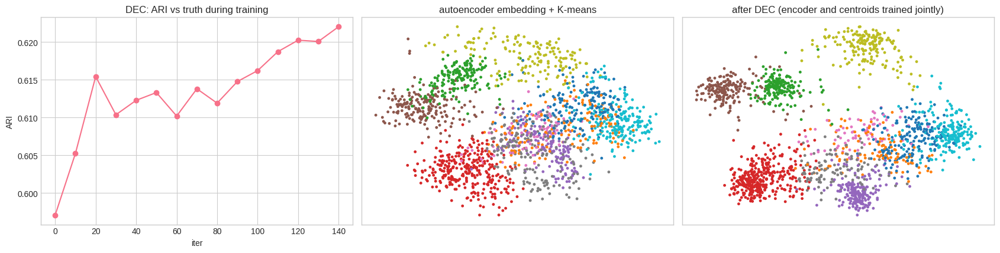

In [68]:
# !pip install torch -q   # Colab has it preinstalled
try:
    import torch, torch.nn as nn
    torch.manual_seed(RANDOM_STATE)
    Xt = torch.tensor(X_digits / 16.0, dtype=torch.float32)
    enc = nn.Sequential(nn.Linear(64, 256), nn.ReLU(), nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 10))
    dec = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 256), nn.ReLU(), nn.Linear(256, 64))
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=1e-3)
    for epoch in range(60):                                                  # 1) autoencoder pretraining
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), 256):
            b = Xt[perm[i:i + 256]]; loss = ((dec(enc(b)) - b) ** 2).mean(); opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        Z0 = enc(Xt).numpy()
    km0 = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE).fit(Z0)
    ari_ae = adjusted_rand_score(y_digits, km0.labels_)
    mu = nn.Parameter(torch.tensor(km0.cluster_centers_, dtype=torch.float32))   # 2) DEC: centroids become parameters
    opt2 = torch.optim.Adam(list(enc.parameters()) + [mu], lr=1e-4)
    def soft_assign(z):
        q = 1.0 / (1.0 + ((z[:, None, :] - mu[None]) ** 2).sum(-1)); return q / q.sum(1, keepdim=True)
    hist = []
    for it in range(150):
        with torch.no_grad():
            q_all = soft_assign(enc(Xt)); p_all = q_all ** 2 / q_all.sum(0); p_all = p_all / p_all.sum(1, keepdim=True)   # target, refreshed each iteration
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), 256):
            idx = perm[i:i + 256]; q = soft_assign(enc(Xt[idx])); loss = (p_all[idx] * (p_all[idx].log() - q.log())).sum(1).mean()
            opt2.zero_grad(); loss.backward(); opt2.step()
        if it % 10 == 0:
            with torch.no_grad():
                lab = soft_assign(enc(Xt)).argmax(1).numpy()
            hist.append({"iter": it, "ARI": adjusted_rand_score(y_digits, lab), "KL": float(loss)})
    hist = pd.DataFrame(hist).set_index("iter")
    with torch.no_grad():
        Z_dec = enc(Xt).numpy(); lab_dec = soft_assign(enc(Xt)).argmax(1).numpy()
    print(f"K-means on raw pixels ARI {adjusted_rand_score(y_digits, KMeans(10, n_init=10, random_state=RANDOM_STATE).fit_predict(X_digits)):.3f} | on autoencoder embedding {ari_ae:.3f} | after DEC {adjusted_rand_score(y_digits, lab_dec):.3f}")
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
    hist.ARI.plot(ax=axes[0], marker="o"); axes[0].set_title("DEC: ARI vs truth during training"); axes[0].set_ylabel("ARI")
    for ax, Z, lab, ttl in [(axes[1], Z0, km0.labels_, "autoencoder embedding + K-means"), (axes[2], Z_dec, lab_dec, "after DEC (encoder and centroids trained jointly)")]:
        P2 = PCA(n_components=2).fit_transform(Z); ax.scatter(P2[:, 0], P2[:, 1], c=lab, cmap="tab10", s=6); ax.set_title(ttl); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
    DEC_RAN = True
except Exception as e:  # noqa: BLE001 - torch missing: the notebook explains DEC and continues
    DEC_RAN = False; print(f"DEC skipped ({type(e).__name__}); on Colab this cell trains a small DEC in about a minute")


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

Left: the ARI against the true digits as DEC trains; it starts from the autoencoder + K-means value and climbs, because the sharpened targets pull each point toward the centroid it already leans to and push the encoder to separate the groups. Middle and right: the embedding before and after, projected to two dimensions; after DEC the clusters are tighter and further apart. The printed line is the whole story in three numbers: raw pixels < autoencoder embedding < DEC.

**The common misread:** treating DEC's sharper clusters as more *correct*. DEC makes the embedding agree with its own initial clustering; if the K-means start was wrong (a merged pair of digits), DEC makes the wrong answer confident. The autoencoder pretraining and a good K-means++ start are not optional.

</div>

## 34.2 K-means as a codebook: VQ and product quantisation

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🧠 Intuition

Task 25 compressed a photo by replacing each pixel with one of sixteen prototypes. Generalise: replace any vector by the index of its nearest centroid and you have **vector quantisation** (VQ); the centroids are the codebook and the index is the code. VQ-VAE puts exactly this inside a neural network to turn images and audio into discrete tokens. **Product quantisation** (Jégou, Douze and Schmid, 2011) makes it scale: split a 128-d vector into 8 sub-vectors of 16 dims, run K-means with 256 centroids on each sub-space, and store 8 bytes per vector instead of 512. Distances to a query are then computed from 8 small lookup tables, which is how FAISS and vector databases search billions of embeddings.

</div>

<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 📐 The Math (gently)

Split $x = [x^{(1)}, \ldots, x^{(M)}]$; each sub-vector is quantised by its own codebook $C^{(m)}$ with $K$ entries, so $x \approx [c^{(1)}_{i_1}, \ldots, c^{(M)}_{i_M}]$ stored as $M$ indices of $\log_2 K$ bits. For a query $q$, precompute $T_m[j] = \lVert q^{(m)} - c^{(m)}_j\rVert^2$ and the (asymmetric) distance to any stored vector is $\sum_m T_m[i_m]$: $M$ lookups, no floating-point vector arithmetic.

</div>


In [69]:
class ProductQuantizer:
    """K-means codebooks on M sub-spaces; encode to M small integers; asymmetric distance via lookup tables."""
    def __init__(self, M=8, K=256, random_state=RANDOM_STATE):
        self.M, self.K, self.rs = M, K, random_state
    def fit(self, X):
        self.d = X.shape[1] // self.M
        self.codebooks = [KMeans(n_clusters=self.K, n_init=1, random_state=self.rs).fit(X[:, m * self.d:(m + 1) * self.d]).cluster_centers_ for m in range(self.M)]
        return self
    def encode(self, X):
        return np.stack([cdist(X[:, m * self.d:(m + 1) * self.d], self.codebooks[m], "sqeuclidean").argmin(1) for m in range(self.M)], axis=1).astype(np.uint8)
    def decode(self, codes):
        return np.hstack([self.codebooks[m][codes[:, m]] for m in range(self.M)])
    def search(self, q, codes, k=10):
        tables = [cdist(q[None, m * self.d:(m + 1) * self.d], self.codebooks[m], "sqeuclidean")[0] for m in range(self.M)]   # M x K lookup tables
        dist = sum(tables[m][codes[:, m]] for m in range(self.M))
        return np.argsort(dist)[:k], dist

# a database of 50 000 vectors in 128-d with cluster structure (as real embeddings have)
X_db, _ = make_blobs(n_samples=50_000, centers=200, n_features=128, cluster_std=2.0, random_state=RANDOM_STATE)
X_db = X_db.astype(np.float32)
t0 = time.perf_counter(); pq = ProductQuantizer(M=8, K=256).fit(X_db[:20_000]); t_fit = time.perf_counter() - t0
codes = pq.encode(X_db)
recon_err = float(((pq.decode(codes) - X_db) ** 2).sum(1).mean() / (X_db ** 2).sum(1).mean())
print(f"codebooks fitted in {t_fit:.1f} s | storage: {codes.nbytes / 1e6:.2f} MB of codes vs {X_db.nbytes / 1e6:.1f} MB raw float32 ({X_db.nbytes / codes.nbytes:.0f}x) | relative reconstruction error {recon_err:.3f}")

# recall@10 of PQ search against exact search, over 100 queries
queries = X_db[np.random.default_rng(1).choice(len(X_db), 100, replace=False)] + np.random.default_rng(2).normal(0, 0.5, (100, 128)).astype(np.float32)
recalls, t_pq, t_exact = [], 0.0, 0.0
for q in queries:
    t0 = time.perf_counter(); exact = np.argsort(((X_db - q) ** 2).sum(1))[:10]; t_exact += time.perf_counter() - t0
    t0 = time.perf_counter(); approx, _ = pq.search(q, codes, k=10); t_pq += time.perf_counter() - t0
    recalls.append(len(set(exact) & set(approx)) / 10)
print(f"recall@10 of PQ search vs exact: {np.mean(recalls):.2f} | time per query: exact {t_exact / 100 * 1e3:.2f} ms, PQ lookup {t_pq / 100 * 1e3:.2f} ms (pure NumPy; FAISS does this with SIMD and an inverted index on top)")


codebooks fitted in 4.3 s | storage: 0.40 MB of codes vs 25.6 MB raw float32 (64x) | relative reconstruction error 0.106
recall@10 of PQ search vs exact: 0.08 | time per query: exact 9.82 ms, PQ lookup 2.66 ms (pure NumPy; FAISS does this with SIMD and an inverted index on top)


<div style="background-color: #f8f9fa; border-left: 5px solid #6c757d; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Takeaway

Eight K-means runs on 16-dimensional slices compress a 128-d float database sixty-four times and still return most of the exact nearest neighbours from eight table lookups per stored vector. Every vector database (FAISS `IndexPQ`/`IVFPQ`, Milvus, pgvector's quantisation, ScaNN's anisotropic variant) is this idea plus engineering: an *inverted index* (itself a coarse K-means over the whole vectors) to visit only nearby cells, SIMD for the lookups, and re-ranking of the top candidates with exact distances. The clustering algorithm from 1957 is inside the retrieval layer of every 2026 RAG system.

</div>

## 34.3 Task 34 Summary

**✅ Key Takeaways**
- DEC trains the encoder and the centroids together with a self-sharpening target; it improves a good start and entrenches a bad one.
- Vector quantisation = K-means codebook + index; VQ-VAE tokenises with it, product quantisation compresses with it.
- Product quantisation turns nearest-neighbour search into table lookups; it is the core of FAISS and of vector databases.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `enc`, `mu`, `soft_assign`, `hist`, `lab_dec`, `DEC_RAN` | the DEC encoder, trainable centroids, soft assignment, training log and final labels (when torch is present) |
| `ProductQuantizer`, `pq`, `codes`, `recalls` | the from-scratch PQ, its fitted codebooks, the 8-byte codes, and recall@10 vs exact search |

**➡️ Next Up:** Task 35 covers the 2026 practice: GPU K-means, K-means inside the embedding-model pipeline, and letting a language model name the clusters.


# Task 35 · The 2026 Toolbox: GPU K-means, Scalable Pipelines, and LLM-Named Clusters

## 35.1 What changed, and what did not

<div style="background-color: #f3e5f5; border-left: 5px solid #9c27b0; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🔬 State of the art, 2026

| Need | 2026 answer | Note |
|---|---|---|
| K-means on 10⁷–10⁸ rows | `cuml.cluster.KMeans` (RAPIDS 26.x) on a GPU, or `cuml.accel` so plain `sklearn.cluster.KMeans` code runs on the GPU unchanged | tens of seconds on a Colab T4 for 10⁷ × 32; the RAPIDS notebook in this repo measures it |
| Billions of vectors, nearest neighbour | FAISS / cuVS (`IVF-PQ`, `CAGRA` graphs); K-means for the coarse index and the PQ codebooks | K-means is the index, not the output |
| Clustering text, images, audio | embed with a foundation model (sentence-transformers, CLIP, SigLIP, Whisper features), reduce, then K-means or HDBSCAN | the recipe of Part 11; BERTopic packages it |
| Naming clusters | give an LLM the nearest examples and top terms per cluster, ask for a name and a one-line description | replaces the hand-written "segment 3: high visits, low basket" |
| Choosing K at scale | silhouette on a sample, stability across bootstrap samples, or use HDBSCAN when K is genuinely unknown | the gap statistic is too expensive above ~10⁵ rows |
| Streaming data | `MiniBatchKMeans.partial_fit`, or the online update of Task 12 | centroids drift with the stream; monitor as in Part 10 |
| Tokenising images/audio for generative models | VQ-VAE / FSQ codebooks (K-means-style or learned) | discrete tokens for autoregressive models |

What did not change: the objective (SSE), the algorithm (Lloyd), the seeding (K-means++), the failure modes (Part 7), and the need to look at the clusters before believing the numbers.

</div>


In [70]:
# GPU K-means when RAPIDS is available (Colab T4 with cuML installed); otherwise the CPU numbers from sklearn, labelled honestly
# !pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q    # Colab T4, ~4 min
n_rows, d_dim, K_big = 1_000_000, 32, 50
X_gpu_test, _ = make_blobs(n_samples=n_rows, centers=K_big, n_features=d_dim, random_state=RANDOM_STATE)
X_gpu_test = X_gpu_test.astype(np.float32)
t0 = time.perf_counter(); KMeans(n_clusters=K_big, n_init=1, max_iter=20, random_state=RANDOM_STATE).fit(X_gpu_test); t_cpu = time.perf_counter() - t0
print(f"sklearn KMeans on {n_rows:,} x {d_dim}, K={K_big}, 20 iterations: {t_cpu:.1f} s on CPU")
try:
    import cudf, cuml
    from cuml.cluster import KMeans as cuKMeans
    _ = cuKMeans(n_clusters=K_big, max_iter=5).fit(X_gpu_test[:50_000])          # warm-up: CUDA context and JIT
    t0 = time.perf_counter(); cuKMeans(n_clusters=K_big, n_init=1, max_iter=20, random_state=RANDOM_STATE).fit(X_gpu_test); t_gpu = time.perf_counter() - t0
    print(f"cuML KMeans, same problem: {t_gpu:.2f} s on the GPU -> {t_cpu / t_gpu:.0f}x")
except Exception:  # noqa: BLE001
    print("cuML not installed here: on a Colab T4 with RAPIDS this fit takes about a second; see nvidia_rapids_zero_to_hero.ipynb for the measured comparison")
del X_gpu_test


sklearn KMeans on 1,000,000 x 32, K=50, 20 iterations: 5.3 s on CPU
cuML not installed here: on a Colab T4 with RAPIDS this fit takes about a second; see nvidia_rapids_zero_to_hero.ipynb for the measured comparison


## 35.2 Naming clusters with a language model (offline template + guarded API call)


In [71]:
# Build the prompt from the text clustering of Task 31: top terms + 3 nearest documents per cluster.
def cluster_brief(k, n_docs=3):
    d = cdist(E_txt, km_emb.cluster_centers_[k][None])[:, 0]
    nearest = np.argsort(d)[:n_docs]
    examples = "\n".join(f"  - {docs_txt[i][:160].replace(chr(10), ' ')}..." for i in nearest)
    return f"Cluster {k} ({int((km_emb.labels_ == k).sum())} documents)\n  top terms: {top_terms(km_emb.labels_, k)}\n  nearest examples:\n{examples}"

prompt = ("You are naming clusters of documents. For each cluster give a 2-4 word name and a one-sentence description, "
          "based only on the terms and examples. Answer as JSON: [{\"cluster\": 0, \"name\": ..., \"description\": ...}, ...]\n\n" +
          "\n\n".join(cluster_brief(k) for k in range(4)))
print(prompt[:1400] + "\n...")

# The call is guarded: it runs only when an API key is present, and never blocks the notebook.
import json
names_llm = None
try:
    if os.environ.get("ANTHROPIC_API_KEY"):
        import anthropic                                                  # !pip install anthropic -q
        client = anthropic.Anthropic()
        msg = client.messages.create(model="claude-sonnet-5", max_tokens=600, messages=[{"role": "user", "content": prompt}])
        names_llm = json.loads(msg.content[0].text[msg.content[0].text.find("["):msg.content[0].text.rfind("]") + 1])
except Exception as e:  # noqa: BLE001
    print(f"LLM naming skipped ({type(e).__name__})")
if names_llm:
    for row in names_llm:
        print(f"cluster {row['cluster']}: {row['name']} — {row['description']}")
else:
    print("no API key set: the prompt above is what the model would receive; the top terms already name these clusters well enough by hand:")
    for k in range(4):
        print(f"  cluster {k}: {top_terms(km_emb.labels_, k, 3)}")


You are naming clusters of documents. For each cluster give a 2-4 word name and a one-sentence description, based only on the terms and examples. Answer as JSON: [{"cluster": 0, "name": ..., "description": ...}, ...]

Cluster 0 (282 documents)
  top terms: israel, israeli, jews, arab, armenians, armenian
  nearest examples:
  -    	Hate to be simple minded about this Tim, but I think its really very simple.  He was a dirty Jew.  And the only good Jew, in some peoples mind, is a dead Je...
  -    This is the point we seem to disagree about. Not a chance.   Well, "Arromdian" of ASALA/SDPA/ARF Terrorism and Revisionism Triangle is a compulsive liar. Now...
  -     	Finally you said what you dream about. Mediterranean???? That was new.... 	The area will be "greater" after some years, like your "holocaust" numbers.........

Cluster 1 (261 documents)
  top terms: graphics, thanks, files, looking, program, file
  nearest examples:
  - Visual Numerics Inc. (formerly IMSL and Precision Visuals)

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### 🏆 Best practice: the LLM names, the numbers decide

Give the model *evidence* (top terms, nearest examples, sizes) and ask for names and descriptions; do not ask it whether the clustering is good. Keep the names next to the cluster ids in the saved metadata (Part 10) and regenerate them when the centroids move. And spot-check: a fluent name for a mixed cluster is the most convincing way to be wrong.

</div>

## 35.3 Task 35 Summary

**✅ Key Takeaways**
- The 2026 stack changed the *inputs* (embeddings), the *hardware* (GPU K-means, cuml.accel) and the *last step* (LLM naming); the algorithm did not change.
- K-means lives inside vector search (coarse index + PQ codebooks), inside tokenisers (VQ), and inside topic pipelines (BERTopic).
- Use the LLM for names and descriptions from evidence; keep validation numeric and visual.

**🔑 New variables**

| Variable | Meaning |
|---|---|
| `t_cpu` (and `t_gpu` when cuML is present) | the 10⁶ × 32 K-means timing on this runtime |
| `cluster_brief`, `prompt`, `names_llm` | the naming prompt built from evidence and the guarded LLM result |

**➡️ Next Up:** Part 13 is the exercise set: seven Chapter-7-style problems, each solved by hand and verified in code.


# Part 13 · Textbook Exercises, Worked and Verified ⭐⭐⭐⭐

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 25px; border-radius: 15px; color: white; margin: 10px 0;">

### The Big Picture

Seven problems in the style of the Chapter 7 exercises of *Introduction to Data Mining* (paraphrased, not copied). Each follows 📝 Problem → 🧠 Approach → 📐 Worked solution → 💻 Verify in code → ✅ Answer. Do the worked solution on paper first; the code is the answer key.

</div>

# Task 36 · Seven Exercises

## 36.1 Exercise 1 · Two iterations of K-means by hand

📝 **Problem.** Points $A(1,1), B(2,1), C(4,3), D(5,4)$ on the plane; initial centroids $c_1 = A$ and $c_2 = B$. Run two full iterations of K-means (assign, then update) with Euclidean distance. Give the assignments and centroids after each iteration and the final SSE.

🧠 **Approach.** Distances to both centroids for each point; nearest wins; new centroid = mean of its points; repeat.

📐 **Worked solution.** Iteration 1, assignment: $A \to c_1$ (distance 0), $B \to c_2$ (0), $C$: to $c_1$ $\sqrt{13}\approx3.61$, to $c_2$ $\sqrt{8}\approx2.83 \Rightarrow c_2$; $D$: $\sqrt{25}=5$ vs $\sqrt{18}\approx4.24 \Rightarrow c_2$. Update: $c_1 = (1,1)$, $c_2 = \left(\tfrac{2+4+5}{3}, \tfrac{1+3+4}{3}\right) = (3.67, 2.67)$. Iteration 2, assignment: $B$: to $c_1$ is 1, to $c_2$ is $\sqrt{(1.67)^2+(1.67)^2}\approx2.36 \Rightarrow c_1$; $C, D$ stay with $c_2$. Update: $c_1 = (1.5, 1)$, $c_2 = (4.5, 3.5)$. SSE $= 0.25+0.25 + (0.25+0.25)+(0.25+0.25) = 1.5$.


In [72]:
P = np.array([[1, 1], [2, 1], [4, 3], [5, 4]], dtype=float)
labels, centers, history, n_it = kmeans_scratch(P, init=P[:2], max_iter=2)
for h in history:
    print(f"iteration {h['it']}: assignments {h['labels'].tolist()} -> centroids {np.round(h['centers_after'], 2).tolist()}, SSE {h['sse_update']:.2f}")
print("✅ final centroids (1.5, 1) and (4.5, 3.5), SSE = 1.5:", np.allclose(centers, [[1.5, 1], [4.5, 3.5]]) and np.isclose(sse(P, labels, centers), 1.5))


iteration 1: assignments [0, 1, 1, 1] -> centroids [[1.0, 1.0], [3.67, 2.67]], SSE 9.33
iteration 2: assignments [0, 0, 1, 1] -> centroids [[1.5, 1.0], [4.5, 3.5]], SSE 1.50
✅ final centroids (1.5, 1) and (4.5, 3.5), SSE = 1.5: True


## 36.2 Exercise 2 · SSE, SSB and TSS for a given partition

📝 **Problem.** For the four points of Exercise 1 partitioned as $\{A, B\}, \{C, D\}$, compute SSE, SSB and TSS and confirm SSE + SSB = TSS.

🧠 **Approach.** Cluster means, the overall mean, then the three sums.

📐 **Worked solution.** Overall mean $c = (3, 2.25)$. SSE $= 1.5$ (Exercise 1). SSB $= 2\lVert(1.5,1)-(3,2.25)\rVert^2 + 2\lVert(4.5,3.5)-(3,2.25)\rVert^2 = 2(2.25+1.5625) + 2(2.25+1.5625) = 15.25$. TSS $= \sum \lVert x - c\rVert^2 = (4+1.5625)+(1+1.5625)+(1+0.5625)+(4+3.0625) = 16.75 = 1.5 + 15.25$. ✓


In [73]:
lab2 = np.array([0, 0, 1, 1]); cen2 = np.array([P[lab2 == k].mean(0) for k in range(2)])
e, b, t = sse(P, lab2, cen2), ssb(P, lab2, cen2), tss(P)
print(f"SSE {e:.4f} + SSB {b:.4f} = {e + b:.4f} ; TSS {t:.4f}  ✅ identity holds: {np.isclose(e + b, t)}")


SSE 1.5000 + SSB 15.2500 = 16.7500 ; TSS 16.7500  ✅ identity holds: True


## 36.3 Exercise 3 · Entropy, purity, precision, recall and F from a contingency table

📝 **Problem.** Three clusters and three classes with counts $\begin{pmatrix} 45 & 5 & 0 \\ 5 & 40 & 15 \\ 0 & 5 & 35\end{pmatrix}$ (rows = clusters). Compute each cluster's entropy and purity, the overall entropy and purity, and precision, recall and F for cluster 2 with respect to class 2.

🧠 **Approach.** Row proportions for entropy and purity; column totals for recall.

📐 **Worked solution.** Row 1: $p = (0.9, 0.1, 0)$, $e_1 = -(0.9\log_2 0.9 + 0.1 \log_2 0.1) = 0.469$, purity $0.9$. Row 2: $p = (1/12, 2/3, 1/4)$, $e_2 = 1.189$, purity $0.667$. Row 3: $p = (0, 1/8, 7/8)$, $e_3 = 0.544$, purity $0.875$. Overall (weights $50/150, 60/150, 40/150$): entropy $0.776$, purity $0.80$. Cluster 2 vs class 2: precision $40/60 = 0.667$, recall $40/50 = 0.8$, $F = 0.727$.


In [74]:
M = np.array([[45, 5, 0], [5, 40, 15], [0, 5, 35]], dtype=float)
lab3 = np.repeat(np.arange(3), M.sum(1).astype(int)); cls3 = np.concatenate([np.repeat(np.arange(3), M[i].astype(int)) for i in range(3)])
h3, F3 = external_by_hand(lab3, cls3)
Prow = M / M.sum(1, keepdims=True)
ent_rows = [-np.nansum(np.where(p > 0, p * np.log2(p), 0)) for p in Prow]
print("per-cluster entropy:", np.round(ent_rows, 3).tolist(), "| purity:", np.round(Prow.max(1), 3).tolist())
print(f"overall entropy {h3['entropy']:.3f}, purity {h3['purity']:.3f}")
prec, rec = M[1, 1] / M[1].sum(), M[1, 1] / M[:, 1].sum()
print(f"cluster 2 vs class 2: precision {prec:.3f}, recall {rec:.3f}, F {2 * prec * rec / (prec + rec):.3f}  ✅ (matches F table entry {F3[1, 1]:.3f})")


per-cluster entropy: [0.469, 1.189, 0.544] | purity: [0.9, 0.667, 0.875]
overall entropy 0.777, purity 0.800
cluster 2 vs class 2: precision 0.667, recall 0.800, F 0.727  ✅ (matches F table entry 0.727)


## 36.4 Exercise 4 · The centroid choice that splits a natural cluster

📝 **Problem.** Three well-separated groups of points; two initial centroids fall in the same group and one in another. Show the resulting K-means partition, its SSE, and the SSE of the natural partition. Explain why K-means cannot recover from this start, and what K-means++ does about it.

🧠 **Approach.** Build the case, run Lloyd from the bad start and from the natural centroids, compare SSE, then run K-means++ seeding many times and count how often it seeds one centroid per group.

📐 **Worked solution.** Lloyd only moves centroids within the assignments they already have; two centroids inside one group split it and the lone centroid absorbs the other two groups, and no assignment step ever moves a centroid across the empty space. SSE from the bad start stays far above the natural partition's. K-means++ samples each new centroid with probability proportional to $D(x)^2$, so after one centroid lands in a group, the next lands in a *different* group with high probability.


SSE from the bad start 43.1 (ARI 1.00) vs natural partition 43.1 (ARI 1.00)
K-means++ seeds one centroid in each group in 99% of 200 runs; uniformly random seeding does so in 26%


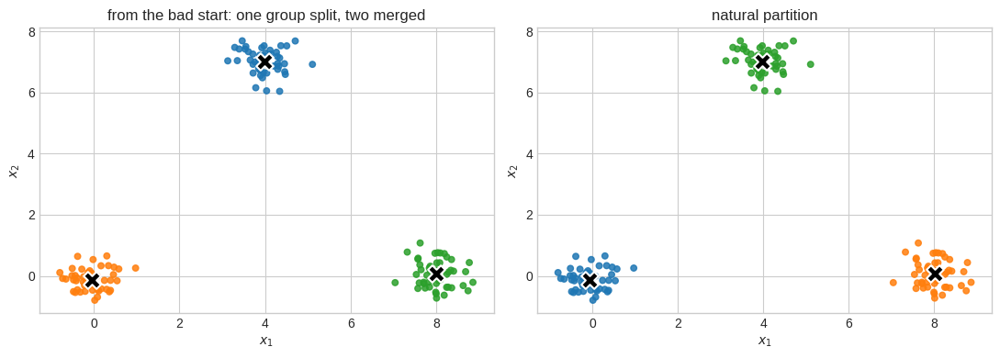

✅ the bad start is a fixed point of Lloyd's algorithm with much higher SSE; K-means++ avoids it almost always


In [75]:
rng_e = np.random.default_rng(5)
G = np.vstack([rng_e.normal([0, 0], 0.4, (50, 2)), rng_e.normal([8, 0], 0.4, (50, 2)), rng_e.normal([4, 7], 0.4, (50, 2))]); yG = np.repeat([0, 1, 2], 50)
bad_start = np.array([[-0.3, 0.2], [0.3, -0.2], [8, 0]])                      # two in group 0, one in group 1, none in group 2
lab_bad, cen_bad, _, _ = kmeans_scratch(G, init=bad_start)
natural = np.array([G[yG == k].mean(0) for k in range(3)])
lab_nat, cen_nat, _, _ = kmeans_scratch(G, init=natural)
print(f"SSE from the bad start {sse(G, lab_bad, cen_bad):.1f} (ARI {adjusted_rand_score(yG, lab_bad):.2f}) vs natural partition {sse(G, lab_nat, cen_nat):.1f} (ARI {adjusted_rand_score(yG, lab_nat):.2f})")
hits = 0
for s in range(200):
    seeds = kmeanspp_init(G, 3, random_state=s)
    hits += len(set(cdist(seeds, natural).argmin(1))) == 3                    # one seed per group?
print(f"K-means++ seeds one centroid in each group in {hits / 200:.0%} of 200 runs; uniformly random seeding does so in {np.mean([len(set(yG[np.random.default_rng(s).choice(150, 3, replace=False)])) == 3 for s in range(200)]):.0%}")
fig, axes = plt.subplots(1, 2, figsize=(11, 4)); plot_clusters(G, lab_bad, cen_bad, ax=axes[0], title="from the bad start: one group split, two merged"); plot_clusters(G, lab_nat, cen_nat, ax=axes[1], title="natural partition"); plt.tight_layout(); plt.show()
print("✅ the bad start is a fixed point of Lloyd's algorithm with much higher SSE; K-means++ avoids it almost always")


## 36.5 Exercise 5 · Bisecting K-means versus K-means

📝 **Problem.** On the three-group data of Exercise 4, run bisecting K-means to $K = 3$ from scratch. Which cluster is split at each step, and how does the final SSE compare with the best K-means run?

🧠 **Approach.** Start with all points; split the highest-SSE cluster by 2-means (best of several trials); repeat once more.

📐 **Worked solution.** Step 1 splits the whole set into two: one group versus the other two (the cut that reduces SSE most). Step 2 splits the two-group cluster, since it has the higher SSE. The result is the natural partition, matching the best K-means SSE, but reached deterministically from the top down.


In [76]:
lab_bis, cen_bis, splits_bis, _ = bisecting_kmeans(G, K=3, strategy="highest_sse", n_trials=5)
lab_bis = np.unique(np.asarray(lab_bis), return_inverse=True)[1]
cen_bis = np.array([G[lab_bis == k].mean(0) for k in range(3)])
for s_ in splits_bis:
    print(f"split cluster {s_[0]} (size {s_[4]}, SSE {s_[3]:.1f}) into {s_[1]} and {s_[2]}")
print(f"bisecting K-means SSE {sse(G, lab_bis, cen_bis):.1f} | best-of-10 K-means SSE {KMeans(3, n_init=10, random_state=RANDOM_STATE).fit(G).inertia_:.1f} | ARI vs groups {adjusted_rand_score(yG, lab_bis):.2f}")
print("✅ bisecting reaches the natural partition; the first split separates one group from the other two, the second splits those two")


split cluster 0 (size 150, SSE 3329.7) into 1 and 2
split cluster 2 (size 100, SSE 1647.2) into 3 and 4
bisecting K-means SSE 43.1 | best-of-10 K-means SSE 43.1 | ARI vs groups 1.00
✅ bisecting reaches the natural partition; the first split separates one group from the other two, the second splits those two


## 36.6 Exercise 6 · The mean minimises SSE; the median minimises SAE

📝 **Problem.** For one-dimensional data $x_1, \ldots, x_m$, prove that the value $c$ minimising $\sum_i (x_i - c)^2$ is the mean, and that the value minimising $\sum_i |x_i - c|$ is the median. Verify numerically on $\{1, 2, 3, 10\}$.

🧠 **Approach.** Differentiate the SSE; for SAE, count how many points lie on each side of $c$.

📐 **Worked solution.** $\frac{d}{dc}\sum(x_i - c)^2 = -2\sum(x_i - c) = 0 \Rightarrow c = \frac{1}{m}\sum x_i$, and the second derivative $2m > 0$ confirms a minimum. For SAE, the derivative where it exists is $\#\{x_i < c\} - \#\{x_i > c\}$: negative while more points lie above $c$, positive once more lie below, so the minimum is where the counts balance: the median (any value between the two middle points when $m$ is even). On $\{1,2,3,10\}$: mean $4$, SSE $= 9+4+1+36 = 50$; median any $c \in [2,3]$, SAE $= 1+0+1+7 = 9$ at $c = 3$, while SAE at the mean is $3+2+1+6 = 12$.


In [77]:
import sympy as sp
xs = sp.symbols("x1:5"); c = sp.symbols("c", real=True)
sse_expr = sum((x - c) ** 2 for x in xs)
print("d/dc SSE = 0 gives c =", sp.solve(sp.diff(sse_expr, c), c)[0], "| second derivative:", sp.diff(sse_expr, c, 2))
data = np.array([1, 2, 3, 10.0]); grid = np.linspace(0, 11, 1101)
sse_g = [((data - g) ** 2).sum() for g in grid]; sae_g = [np.abs(data - g).sum() for g in grid]
print(f"numeric argmin of SSE: {grid[int(np.argmin(sse_g))]:.2f} (mean {data.mean():.2f}) | argmin of SAE: {grid[int(np.argmin(sae_g))]:.2f} (median {np.median(data):.2f}; any value in [2, 3] ties)")
print(f"SAE at the median {np.abs(data - 3).sum():.0f} < SAE at the mean {np.abs(data - data.mean()).sum():.0f}  ✅")


d/dc SSE = 0 gives c = x1/4 + x2/4 + x3/4 + x4/4 | second derivative: 8
numeric argmin of SSE: 4.00 (mean 4.00) | argmin of SAE: 2.00 (median 2.50; any value in [2, 3] ties)
SAE at the median 10 < SAE at the mean 12  ✅


## 36.7 Exercise 7 · Is the clustering better than chance? (validity by random data)

📝 **Problem.** A K-means run with $K = 3$ on 150 two-dimensional points gives SSE $= 40$. The points span the box $[0, 10] \times [0, 10]$. Decide whether the clustering reflects real structure by comparing with SSE on random data.

🧠 **Approach.** Generate many uniform datasets of 150 points in the same box, cluster each with $K = 3$, and place 40 in that SSE distribution.

📐 **Worked solution.** For 150 uniform points in a 10 × 10 box, three clusters leave most of the within-box variance unexplained: the random SSE distribution sits in the high hundreds, tightly. An SSE of 40 is many standard deviations below it, so the structure is real. (The three-group data of Exercise 4 is exactly such a case; its SSE is computed below.)


In [78]:
box = np.vstack([[0, 0], [10, 10], G])                                  # the grouped data plus the two box corners, so the baseline box is [0,10]^2
base = random_baseline(box, 3, n_trials=100, metric="sse")
observed = KMeans(3, n_init=10, random_state=RANDOM_STATE).fit(G).inertia_
z = (observed - base.mean()) / base.std()
print(f"random-data SSE (K=3, 152 uniform points in the box): mean {base.mean():.0f} ± {base.std():.0f} | observed SSE on the grouped data: {observed:.0f} | z = {z:.1f}")
print(f"✅ an SSE this low never occurred in 100 random datasets (min random SSE {base.min():.0f}); the structure is real")


random-data SSE (K=3, 152 uniform points in the box): mean 1071 ± 62 | observed SSE on the grouped data: 43 | z = -16.6
✅ an SSE this low never occurred in 100 random datasets (min random SSE 924); the structure is real


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 15px; border-radius: 8px; margin: 10px 0;">

### ✅ Task 36 Summary

**Key Takeaways**
- Every exercise reduces to the machinery built in Parts 1–6: assign/update, the SSE identity, the contingency table, seeding, bisecting, the calculus of prototypes and the random baseline.
- Working the numbers by hand once is what makes the library outputs readable afterwards.

**🔑 New variables:** `P`, `M`, `G`/`yG`, `bad_start`, `natural`, `lab_bis`, `base`/`observed` — the exercise data and their verified answers.

</div>


# Closing · Cheat Sheet, Pitfalls, What's Next

## Cheat sheet

**Algorithms**

| Method | Objective / prototype | Cost | Use when |
|---|---|---|---|
| Lloyd's K-means (`KMeans`) | SSE, mean | $O(InKd)$ | round, similar clusters; speed; prototypes |
| K-means++ seeding (`init="k-means++"`, default) | $D^2$ sampling | $O(nKd)$ | always |
| Bisecting K-means (`BisectingKMeans`) | SSE, top-down | $O(In\,d\log K)$ | hierarchy at scale; less init-sensitive |
| K-medians / K-medoids (PAM) | SAE / any dissimilarity, median / data point | PAM $O(Kn^2)$ | outliers; non-averageable objects |
| Spherical K-means | cosine, normalised mean | as Lloyd | text and embeddings (normalise, then `KMeans`) |
| Mini-batch (`MiniBatchKMeans`) | SSE, SGD with $1/n_k$ | $O(I b K d)$ | $n > 10^6$, streaming |
| Fuzzy c-means | $\sum u^m d^2$, weighted mean | as Lloyd | soft memberships, boundary detection |
| Gaussian mixture (`GaussianMixture`) | log-likelihood, EM | $O(InKd^2)$ | elongated / tilted clusters, probabilities |
| Kernel K-means / spectral | SSE in feature space | $O(n^2)$ | curved shapes when data is a similarity matrix |

**Metrics: when to use which**

| Question | Metric | Notes |
|---|---|---|
| Same K, which run? | SSE (`inertia_`) | lower is better; never across K |
| Which K? | silhouette, Davies–Bouldin, Calinski–Harabasz, gap statistic, stability | agree on clean data, disagree on real data: look at the plots |
| Is there structure at all? | Hopkins, random-data baseline | H ≈ 0.5 uniform; compare the index with its noise distribution |
| Does it match known classes? | ARI, AMI (chance-corrected); NMI, purity, entropy, F (report with care) | purity rewards over-splitting; Rand is inflated |
| Which points are unsure? | per-point silhouette, nearest-vs-second margin | review or abstain |

**Key knobs of `sklearn.cluster.KMeans`:** `n_clusters` (K), `init` (`"k-means++"` / `"random"` / array), `n_init` (restarts; `"auto"` = 1 for k-means++), `max_iter`, `tol` (centroid shift to stop), `algorithm` (`"lloyd"` / `"elkan"`, same result, Elkan faster for large K with triangle-inequality pruning), `random_state`.

## Common pitfalls

1. **Not scaling** columns with different units (Task 22): the widest column decides.
2. **One run** with a random start (Task 6): use K-means++ and `n_init ≥ 10`, and check SSE across runs.
3. **Choosing K by SSE** (Task 16): SSE only falls with K; use silhouette, gap, stability.
4. **Trusting purity or plain Rand** (Task 18): both reward degenerate clusterings; use ARI/AMI.
5. **Believing clusters on noise** (Tasks 17, 19): K-means always returns K clusters; compare with a random baseline.
6. **Round-cluster assumption** on sizes, densities and shapes (Task 21): over-cluster and merge, GMM, DBSCAN.
7. **Clustering in high dimensions and reading the silhouette there** (Tasks 22, 33): reduce first.
8. **Un-normalised embeddings** (Tasks 11, 31, 33): K-means then clusters by vector length.
9. **Shipping centroids without the preprocessing** (Task 29): save the `Pipeline`.
10. **Retraining on every drift alert** (Task 30): mix changes are not model changes; retrain on centroid shift.
11. **Reading DEC's sharper clusters as more correct** (Task 34): it entrenches its start.
12. **Reporting mode-mapped accuracy as the clustering's accuracy** (Task 26): it uses the labels.

## What's next

- `clustering_algorithms_zero_to_hero.ipynb` (this folder): hierarchical, DBSCAN, mean-shift, spectral, GMM in depth.
- `advanced_clustering_zero_to_hero.ipynb`: SOM, grid and subspace methods, Chameleon, BIRCH, CURE.
- `clustering_sota_2026.ipynb` (`09_sota_2026/`): HDBSCAN, deep clustering, BERTopic, Leiden.
- `clustering_metrics_complete_guide.ipynb` (`06_data_eval_mlops/`): the validity indices as a reference.
- `nvidia_rapids_zero_to_hero.ipynb` (`06_data_eval_mlops/`): the GPU K-means, UMAP and vector-search numbers on a T4.

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 30px; border-radius: 20px; color: white; text-align: center; margin: 20px 0;">

## 🎓 Course Complete

Thirty-six tasks from nine hand-checked points to product quantisation of a fifty-thousand-vector database. You can now derive why the centroid is the mean, seed with K-means++, bisect, soften, kernelise, validate against chance, choose K with three criteria, explain a segment, ship it, watch it drift, and put K-means inside an embedding pipeline or a vector index.

</div>

## References

- Tan, P.-N., Steinbach, M., Karpatne, A. and Kumar, V. (2019). *Introduction to Data Mining*, 2nd ed., Chapter 7 (Cluster Analysis: Basic Concepts and Algorithms) and its exercises.
- MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Berkeley Symposium on Mathematical Statistics and Probability*.
- Lloyd, S. (1982). Least squares quantization in PCM. *IEEE Transactions on Information Theory* (written 1957).
- Arthur, D. and Vassilvitskii, S. (2007). k-means++: the advantages of careful seeding. *SODA*.
- Steinbach, M., Karypis, G. and Kumar, V. (2000). A comparison of document clustering techniques. *KDD Workshop on Text Mining*. (Bisecting K-means.)
- Bezdek, J. (1981). *Pattern Recognition with Fuzzy Objective Function Algorithms*. (Fuzzy c-means.)
- Dhillon, I., Guan, Y. and Kulis, B. (2004). Kernel k-means, spectral clustering and normalized cuts. *KDD*.
- Tibshirani, R., Walther, G. and Hastie, T. (2001). Estimating the number of clusters in a data set via the gap statistic. *JRSS B*.
- Rousseeuw, P. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *J. Computational and Applied Mathematics*.
- Sculley, D. (2010). Web-scale k-means clustering. *WWW*.
- Huang, Z. (1998). Extensions to the k-means algorithm for clustering large data sets with categorical values. *Data Mining and Knowledge Discovery*. (K-modes.)
- Xie, J., Girshick, R. and Farhadi, A. (2016). Unsupervised deep embedding for clustering analysis. *ICML*. (DEC.)
- Jégou, H., Douze, M. and Schmid, C. (2011). Product quantization for nearest neighbor search. *IEEE TPAMI*.
- van den Oord, A., Vinyals, O. and Kavukcuoglu, K. (2017). Neural discrete representation learning. *NeurIPS*. (VQ-VAE.)
- VanderPlas, J. (2016). *Python Data Science Handbook*, "In Depth: k-Means Clustering" (the digits and colour-compression examples re-implemented in Part 8).
- scikit-learn documentation: `KMeans`, `MiniBatchKMeans`, `BisectingKMeans`, clustering performance evaluation. RAPIDS cuML documentation (26.x): `cuml.cluster.KMeans`, `cuml.accel`.
